## Phase 1/10 — Data Understanding & Initial Project Setup


In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import re

import warnings
from IPython.display import display

warnings.filterwarnings("ignore")


pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 100)
pd.set_option("display.width", 160)
pd.set_option("display.max_colwidth", 120)

RANDOM_STATE = 42

TARGET_COL = 'match_result'
ID_COL = 'match_id'



print("Libraries imported successfully")

Libraries imported successfully


In [2]:
PROJECT_ROOT = Path.cwd()
DATA_PATH = PROJECT_ROOT / 'football_data.csv'

print('Project root: ', PROJECT_ROOT)
print('data path: ', DATA_PATH)

if not DATA_PATH.exists():
    raise FileNotFoundError(
        f'dataset file was not found at :\n{DATA_PATH}\n'
        'please make sure football_data.csv is in the project root folder'
    )

Project root:  c:\Users\mojta_tok6stl\OneDrive\Desktop\learning_ai\Football_Match_Prediction
data path:  c:\Users\mojta_tok6stl\OneDrive\Desktop\learning_ai\Football_Match_Prediction\football_data.csv


In [3]:
df_raw = pd.read_csv(DATA_PATH)

print('Dataset loaded successfully')
print(f"Shape: {df_raw.shape[0]:,} rows × {df_raw.shape[1]:,} columns")

display(df_raw.head())

Dataset loaded successfully
Shape: 110,938 rows × 190 columns


,match_id,match_result,home_club,away_club,fixture_date,competition,competition_code,cup_game,home_manager_id,away_manager_id,home_club_recent_fixture_date_1,home_club_recent_fixture_date_2,home_club_recent_fixture_date_3,home_club_recent_fixture_date_4,home_club_recent_fixture_date_5,home_club_recent_fixture_date_6,home_club_recent_fixture_date_7,home_club_recent_fixture_date_8,home_club_recent_fixture_date_9,home_club_recent_fixture_date_10,home_club_recent_played_at_home_1,home_club_recent_played_at_home_2,home_club_recent_played_at_home_3,home_club_recent_played_at_home_4,home_club_recent_played_at_home_5,home_club_recent_played_at_home_6,home_club_recent_played_at_home_7,home_club_recent_played_at_home_8,home_club_recent_played_at_home_9,home_club_recent_played_at_home_10,home_club_recent_cup_game_1,home_club_recent_cup_game_2,home_club_recent_cup_game_3,home_club_recent_cup_game_4,home_club_recent_cup_game_5,home_club_recent_cup_game_6,home_club_recent_cup_game_7,home_club_recent_cup_game_8,home_club_recent_cup_game_9,home_club_recent_cup_game_10,home_club_recent_goals_scored_1,home_club_recent_goals_scored_2,home_club_recent_goals_scored_3,home_club_recent_goals_scored_4,home_club_recent_goals_scored_5,home_club_recent_goals_scored_6,home_club_recent_goals_scored_7,home_club_recent_goals_scored_8,home_club_recent_goals_scored_9,home_club_recent_goals_scored_10,home_club_recent_goals_conceded_1,home_club_recent_goals_conceded_2,home_club_recent_goals_conceded_3,home_club_recent_goals_conceded_4,home_club_recent_goals_conceded_5,home_club_recent_goals_conceded_6,home_club_recent_goals_conceded_7,home_club_recent_goals_conceded_8,home_club_recent_goals_conceded_9,home_club_recent_goals_conceded_10,home_club_recent_team_rating_1,home_club_recent_team_rating_2,home_club_recent_team_rating_3,home_club_recent_team_rating_4,home_club_recent_team_rating_5,home_club_recent_team_rating_6,home_club_recent_team_rating_7,home_club_recent_team_rating_8,home_club_recent_team_rating_9,home_club_recent_team_rating_10,home_club_recent_opponent_rating_1,home_club_recent_opponent_rating_2,home_club_recent_opponent_rating_3,home_club_recent_opponent_rating_4,home_club_recent_opponent_rating_5,home_club_recent_opponent_rating_6,home_club_recent_opponent_rating_7,home_club_recent_opponent_rating_8,home_club_recent_opponent_rating_9,home_club_recent_opponent_rating_10,home_club_recent_manager_id_1,home_club_recent_manager_id_2,home_club_recent_manager_id_3,home_club_recent_manager_id_4,home_club_recent_manager_id_5,home_club_recent_manager_id_6,home_club_recent_manager_id_7,home_club_recent_manager_id_8,home_club_recent_manager_id_9,home_club_recent_manager_id_10,home_club_recent_competition_code_1,home_club_recent_competition_code_2,home_club_recent_competition_code_3,home_club_recent_competition_code_4,home_club_recent_competition_code_5,home_club_recent_competition_code_6,home_club_recent_competition_code_7,home_club_recent_competition_code_8,home_club_recent_competition_code_9,home_club_recent_competition_code_10,away_club_recent_fixture_date_1,away_club_recent_fixture_date_2,away_club_recent_fixture_date_3,away_club_recent_fixture_date_4,away_club_recent_fixture_date_5,away_club_recent_fixture_date_6,away_club_recent_fixture_date_7,away_club_recent_fixture_date_8,away_club_recent_fixture_date_9,away_club_recent_fixture_date_10,away_club_recent_played_at_home_1,away_club_recent_played_at_home_2,away_club_recent_played_at_home_3,away_club_recent_played_at_home_4,away_club_recent_played_at_home_5,away_club_recent_played_at_home_6,away_club_recent_played_at_home_7,away_club_recent_played_at_home_8,away_club_recent_played_at_home_9,away_club_recent_played_at_home_10,away_club_recent_cup_game_1,away_club_recent_cup_game_2,away_club_recent_cup_game_3,away_club_recent_cup_game_4,away_club_recent_cup_game_5,away_club_recent_cup_game_6,away_club_recent_cup_game_7,away_club_recent_cup_game_8,away_club_recent_cup_game_9,away_club_recent_cup_game_10,aw

In [4]:
def normalize_column_name(column_name : str) -> str:
    
    column_name = str(column_name).strip().lower()
    column_name = re.sub(r'[^\w\s]+',' ', column_name)
    column_name = re.sub(r'\s+','_',column_name)
    column_name = re.sub(r'_+','_',column_name)
    column_name = column_name.strip('_')
    return column_name


def make_unique_column_names(columns)->list:
    
    seen = {}
    unique_columns = []
    
    for col in columns:
        base_name = normalize_column_name(col)
        
        
        if base_name not in seen:
            seen[base_name] = 0
            unique_columns.append(base_name)
        else:
            seen[base_name] += 1
            unique_columns.append(f'{base_name}_{seen[base_name]}')
            
    return unique_columns

original_columns = list(df_raw.columns)
normalize_columns = make_unique_column_names(original_columns)


column_mapping = pd.DataFrame({
    'original_columns' : original_columns,
    'normalize_column': normalize_columns
})
df = df_raw.copy()
df.columns = normalize_columns

print('column normalization  completed')
print(f'number of columns : {len(df.columns):,}')

display(column_mapping)

column normalization  completed
number of columns : 190


,original_columns,normalize_column
0,match_id,match_id
1,match_result,match_result
2,home_club,home_club
3,away_club,away_club
4,fixture_date,fixture_date
...,...,...
185,away_club_recent_competition_code_6,away_club_recent_competition_code_6
186,away_club_recent_competition_code_7,away_club_recent_competition_code_7
187,away_club_recent_competition_code_8,away_club_recent_competition_code_8
188,away_club_recent_competition_code_9,away_club_recent_competition_code_9


In [5]:
print('dataset overview')
print('='*60)
print(f'Rows: {df.shape[0]:,}')
print(f'Columns : {df.shape[1]:,}')


print('\nFirst 5 rows')
display(df.head())

print('\nLast 5 rows')
display(df.tail())

print('\nColumn List')
for i,col in enumerate(df.columns,start=1):
        print(f'{i:03d}. {col}')
        

dataset overview
Rows: 110,938
Columns : 190

First 5 rows


,match_id,match_result,home_club,away_club,fixture_date,competition,competition_code,cup_game,home_manager_id,away_manager_id,home_club_recent_fixture_date_1,home_club_recent_fixture_date_2,home_club_recent_fixture_date_3,home_club_recent_fixture_date_4,home_club_recent_fixture_date_5,home_club_recent_fixture_date_6,home_club_recent_fixture_date_7,home_club_recent_fixture_date_8,home_club_recent_fixture_date_9,home_club_recent_fixture_date_10,home_club_recent_played_at_home_1,home_club_recent_played_at_home_2,home_club_recent_played_at_home_3,home_club_recent_played_at_home_4,home_club_recent_played_at_home_5,home_club_recent_played_at_home_6,home_club_recent_played_at_home_7,home_club_recent_played_at_home_8,home_club_recent_played_at_home_9,home_club_recent_played_at_home_10,home_club_recent_cup_game_1,home_club_recent_cup_game_2,home_club_recent_cup_game_3,home_club_recent_cup_game_4,home_club_recent_cup_game_5,home_club_recent_cup_game_6,home_club_recent_cup_game_7,home_club_recent_cup_game_8,home_club_recent_cup_game_9,home_club_recent_cup_game_10,home_club_recent_goals_scored_1,home_club_recent_goals_scored_2,home_club_recent_goals_scored_3,home_club_recent_goals_scored_4,home_club_recent_goals_scored_5,home_club_recent_goals_scored_6,home_club_recent_goals_scored_7,home_club_recent_goals_scored_8,home_club_recent_goals_scored_9,home_club_recent_goals_scored_10,home_club_recent_goals_conceded_1,home_club_recent_goals_conceded_2,home_club_recent_goals_conceded_3,home_club_recent_goals_conceded_4,home_club_recent_goals_conceded_5,home_club_recent_goals_conceded_6,home_club_recent_goals_conceded_7,home_club_recent_goals_conceded_8,home_club_recent_goals_conceded_9,home_club_recent_goals_conceded_10,home_club_recent_team_rating_1,home_club_recent_team_rating_2,home_club_recent_team_rating_3,home_club_recent_team_rating_4,home_club_recent_team_rating_5,home_club_recent_team_rating_6,home_club_recent_team_rating_7,home_club_recent_team_rating_8,home_club_recent_team_rating_9,home_club_recent_team_rating_10,home_club_recent_opponent_rating_1,home_club_recent_opponent_rating_2,home_club_recent_opponent_rating_3,home_club_recent_opponent_rating_4,home_club_recent_opponent_rating_5,home_club_recent_opponent_rating_6,home_club_recent_opponent_rating_7,home_club_recent_opponent_rating_8,home_club_recent_opponent_rating_9,home_club_recent_opponent_rating_10,home_club_recent_manager_id_1,home_club_recent_manager_id_2,home_club_recent_manager_id_3,home_club_recent_manager_id_4,home_club_recent_manager_id_5,home_club_recent_manager_id_6,home_club_recent_manager_id_7,home_club_recent_manager_id_8,home_club_recent_manager_id_9,home_club_recent_manager_id_10,home_club_recent_competition_code_1,home_club_recent_competition_code_2,home_club_recent_competition_code_3,home_club_recent_competition_code_4,home_club_recent_competition_code_5,home_club_recent_competition_code_6,home_club_recent_competition_code_7,home_club_recent_competition_code_8,home_club_recent_competition_code_9,home_club_recent_competition_code_10,away_club_recent_fixture_date_1,away_club_recent_fixture_date_2,away_club_recent_fixture_date_3,away_club_recent_fixture_date_4,away_club_recent_fixture_date_5,away_club_recent_fixture_date_6,away_club_recent_fixture_date_7,away_club_recent_fixture_date_8,away_club_recent_fixture_date_9,away_club_recent_fixture_date_10,away_club_recent_played_at_home_1,away_club_recent_played_at_home_2,away_club_recent_played_at_home_3,away_club_recent_played_at_home_4,away_club_recent_played_at_home_5,away_club_recent_played_at_home_6,away_club_recent_played_at_home_7,away_club_recent_played_at_home_8,away_club_recent_played_at_home_9,away_club_recent_played_at_home_10,away_club_recent_cup_game_1,away_club_recent_cup_game_2,away_club_recent_cup_game_3,away_club_recent_cup_game_4,away_club_recent_cup_game_5,away_club_recent_cup_game_6,away_club_recent_cup_game_7,away_club_recent_cup_game_8,away_club_recent_cup_game_9,away_club_recent_cup_game_10,aw


Last 5 rows


,match_id,match_result,home_club,away_club,fixture_date,competition,competition_code,cup_game,home_manager_id,away_manager_id,home_club_recent_fixture_date_1,home_club_recent_fixture_date_2,home_club_recent_fixture_date_3,home_club_recent_fixture_date_4,home_club_recent_fixture_date_5,home_club_recent_fixture_date_6,home_club_recent_fixture_date_7,home_club_recent_fixture_date_8,home_club_recent_fixture_date_9,home_club_recent_fixture_date_10,home_club_recent_played_at_home_1,home_club_recent_played_at_home_2,home_club_recent_played_at_home_3,home_club_recent_played_at_home_4,home_club_recent_played_at_home_5,home_club_recent_played_at_home_6,home_club_recent_played_at_home_7,home_club_recent_played_at_home_8,home_club_recent_played_at_home_9,home_club_recent_played_at_home_10,home_club_recent_cup_game_1,home_club_recent_cup_game_2,home_club_recent_cup_game_3,home_club_recent_cup_game_4,home_club_recent_cup_game_5,home_club_recent_cup_game_6,home_club_recent_cup_game_7,home_club_recent_cup_game_8,home_club_recent_cup_game_9,home_club_recent_cup_game_10,home_club_recent_goals_scored_1,home_club_recent_goals_scored_2,home_club_recent_goals_scored_3,home_club_recent_goals_scored_4,home_club_recent_goals_scored_5,home_club_recent_goals_scored_6,home_club_recent_goals_scored_7,home_club_recent_goals_scored_8,home_club_recent_goals_scored_9,home_club_recent_goals_scored_10,home_club_recent_goals_conceded_1,home_club_recent_goals_conceded_2,home_club_recent_goals_conceded_3,home_club_recent_goals_conceded_4,home_club_recent_goals_conceded_5,home_club_recent_goals_conceded_6,home_club_recent_goals_conceded_7,home_club_recent_goals_conceded_8,home_club_recent_goals_conceded_9,home_club_recent_goals_conceded_10,home_club_recent_team_rating_1,home_club_recent_team_rating_2,home_club_recent_team_rating_3,home_club_recent_team_rating_4,home_club_recent_team_rating_5,home_club_recent_team_rating_6,home_club_recent_team_rating_7,home_club_recent_team_rating_8,home_club_recent_team_rating_9,home_club_recent_team_rating_10,home_club_recent_opponent_rating_1,home_club_recent_opponent_rating_2,home_club_recent_opponent_rating_3,home_club_recent_opponent_rating_4,home_club_recent_opponent_rating_5,home_club_recent_opponent_rating_6,home_club_recent_opponent_rating_7,home_club_recent_opponent_rating_8,home_club_recent_opponent_rating_9,home_club_recent_opponent_rating_10,home_club_recent_manager_id_1,home_club_recent_manager_id_2,home_club_recent_manager_id_3,home_club_recent_manager_id_4,home_club_recent_manager_id_5,home_club_recent_manager_id_6,home_club_recent_manager_id_7,home_club_recent_manager_id_8,home_club_recent_manager_id_9,home_club_recent_manager_id_10,home_club_recent_competition_code_1,home_club_recent_competition_code_2,home_club_recent_competition_code_3,home_club_recent_competition_code_4,home_club_recent_competition_code_5,home_club_recent_competition_code_6,home_club_recent_competition_code_7,home_club_recent_competition_code_8,home_club_recent_competition_code_9,home_club_recent_competition_code_10,away_club_recent_fixture_date_1,away_club_recent_fixture_date_2,away_club_recent_fixture_date_3,away_club_recent_fixture_date_4,away_club_recent_fixture_date_5,away_club_recent_fixture_date_6,away_club_recent_fixture_date_7,away_club_recent_fixture_date_8,away_club_recent_fixture_date_9,away_club_recent_fixture_date_10,away_club_recent_played_at_home_1,away_club_recent_played_at_home_2,away_club_recent_played_at_home_3,away_club_recent_played_at_home_4,away_club_recent_played_at_home_5,away_club_recent_played_at_home_6,away_club_recent_played_at_home_7,away_club_recent_played_at_home_8,away_club_recent_played_at_home_9,away_club_recent_played_at_home_10,away_club_recent_cup_game_1,away_club_recent_cup_game_2,away_club_recent_cup_game_3,away_club_recent_cup_game_4,away_club_recent_cup_game_5,away_club_recent_cup_game_6,away_club_recent_cup_game_7,away_club_recent_cup_game_8,away_club_recent_cup_game_9,away_club_recent_cup_game_10,aw


Column List
001. match_id
002. match_result
003. home_club
004. away_club
005. fixture_date
006. competition
007. competition_code
008. cup_game
009. home_manager_id
010. away_manager_id
011. home_club_recent_fixture_date_1
012. home_club_recent_fixture_date_2
013. home_club_recent_fixture_date_3
014. home_club_recent_fixture_date_4
015. home_club_recent_fixture_date_5
016. home_club_recent_fixture_date_6
017. home_club_recent_fixture_date_7
018. home_club_recent_fixture_date_8
019. home_club_recent_fixture_date_9
020. home_club_recent_fixture_date_10
021. home_club_recent_played_at_home_1
022. home_club_recent_played_at_home_2
023. home_club_recent_played_at_home_3
024. home_club_recent_played_at_home_4
025. home_club_recent_played_at_home_5
026. home_club_recent_played_at_home_6
027. home_club_recent_played_at_home_7
028. home_club_recent_played_at_home_8
029. home_club_recent_played_at_home_9
030. home_club_recent_played_at_home_10
031. home_club_recent_cup_game_1
032. home_club_re

In [6]:
TARGET_COL = 'match_result'
ID_COL = 'match_id'


MAIN_MATCH_COLUMNS = [
    'match_id',
    'match_result',
    'home_club',
    'away_club',
    'fixture_date',
    'competition',
    'competition_code',
    'cup_game',
    'home_manager_id',
    'away_manager_id'
]


main_columns_status = pd.DataFrame({
    'column': MAIN_MATCH_COLUMNS,
    'exists': [col in df.columns for col in MAIN_MATCH_COLUMNS],
    'dtype': [str(df[col].dtype) if col in df.columns else None for col in MAIN_MATCH_COLUMNS],
    'null_count':[df[col].isna().sum() if col in df.columns else None for col in MAIN_MATCH_COLUMNS],
    'unique_count': [df[col].nunique(dropna=True) if col in df.columns else None for col in MAIN_MATCH_COLUMNS]
})



display(main_columns_status)


missing_main_columns = main_columns_status.loc[
        ~main_columns_status['exists'],
        'column'
].tolist()




if TARGET_COL not in df.columns:
    raise ValueError(
        f'Target column {TARGET_COL} was not found'
        'please check the dataset column name or update TARGET_COL'
    )
    
print(f'target column {TARGET_COL} exists')


if ID_COL in df.columns:
    duplicated_id_count = df[ID_COL].duplicated().sum()
    print(f'duplicated match_id  count: {duplicated_id_count:,}')
    
else:
    print(f'warning : id column {ID_COL} was not found')


print(f'existing main column : {len(MAIN_MATCH_COLUMNS) - len(missing_main_columns)}/{len(MAIN_MATCH_COLUMNS)}')

if missing_main_columns:
    print('\nwarning-> misising main  columns:')
    for col in missing_main_columns:
        print('-',col)

,column,exists,dtype,null_count,unique_count
0,match_id,True,int64,0,110938
1,match_result,True,object,0,3
2,home_club,True,object,1,9813
3,away_club,True,object,1,9892
4,fixture_date,True,object,0,20269
5,competition,True,object,1,727
6,competition_code,True,int64,0,862
7,cup_game,True,object,1,2
8,home_manager_id,True,float64,21721,8804
9,away_manager_id,True,float64,21815,8938


target column match_result exists
duplicated match_id  count: 0
existing main column : 10/10


In [7]:
target_counts = df[TARGET_COL].value_counts(dropna=False)
target_percentage = df[TARGET_COL].value_counts(normalize=True,dropna=False).mul(100)

target_distribution = pd.DataFrame({
    'count': target_counts,
    'percentage' : target_percentage.round(2)
})

print('Target Distribution')
print('-'*60)

display(target_distribution)

print(f'number of target classes: {df[TARGET_COL].nunique(dropna=True)}')

missing_target_count = df[TARGET_COL].isna().sum()


if missing_target_count > 0:
    print(f'warning : target column contians {missing_target_count :,} missing values')

majority_class_percentage =  target_percentage.max()

print(f'Majority class percentage : {majority_class_percentage :.2f}%')

if majority_class_percentage >= 70:
    print('warning : Target distribution seems highly imbalanced')
    
else:
    print('Target distribution does not seem extremely imbalanced')
    

Target Distribution
------------------------------------------------------------


,count,percentage
match_result,,
home,48113,43.37
away,35174,31.71
draw,27651,24.92


number of target classes: 3
Majority class percentage : 43.37%
Target distribution does not seem extremely imbalanced


In [8]:
dtype_summary= pd.DataFrame({
    'column' : df.columns,
    'dtype': df.dtypes.astype(str).values,
    'non_null_count': df.notna().sum().values,
    'null_count': df.isna().sum().values,
    'null_percentage': df.isna().mean().mul(100).round(2).values,
    'unique_count': [df[col].nunique(dropna=True) for col in df.columns]
})


dtype_summary['unique_percentage'] = (
    dtype_summary['unique_count'] / len(df)*100
).round(2)

dtype_summary = dtype_summary.sort_values(
    ['null_percentage','unique_count'],
    ascending=[False,False]
)

print('column qulity summary - to 50')
display(dtype_summary.head(50))

print('\nDtype counts:')
display(dtype_summary['dtype'].value_counts().to_frame('count'))

print('\nColumns with more than 50% missing values: ')
high_missing_columns = dtype_summary[dtype_summary['null_percentage']>50]

if len(high_missing_columns)> 0:
    display(high_missing_columns)
else:
    print('no columns with more than 50% missing values')

column qulity summary - to 50


,column,dtype,non_null_count,null_count,null_percentage,unique_count,unique_percentage
179,away_club_recent_manager_id_10,float64,83809,27129,24.45,7936,7.15
89,home_club_recent_manager_id_10,float64,84285,26653,24.03,7891,7.11
178,away_club_recent_manager_id_9,float64,84788,26150,23.57,8044,7.25
88,home_club_recent_manager_id_9,float64,85205,25733,23.20,8002,7.21
177,away_club_recent_manager_id_8,float64,85719,25219,22.73,8144,7.34
87,home_club_recent_manager_id_8,float64,86069,24869,22.42,8150,7.35
176,away_club_recent_manager_id_7,float64,86561,24377,21.97,8303,7.48
86,home_club_recent_manager_id_7,float64,86958,23980,21.62,8265,7.45
175,away_club_recent_manager_id_6,float64,87413,23525,21.21,8440,7.61
85,home_club_recent_manager_id_6,float64,87680,23258,20.96,8385,7.56



Dtype counts:


,count
dtype,
float64,162
object,26
int64,2



Columns with more than 50% missing values: 
no columns with more than 50% missing values


In [9]:
date_like_columns = [col for col in df.columns if "date" in col]

print("Detected date-like columns:")
for col in date_like_columns:
    print("-", col)

date_parse_report = []

for col in date_like_columns:
    parsed = pd.to_datetime(df[col], errors="coerce")

    non_null_original = df[col].notna().sum()
    parsed_non_null = parsed.notna().sum()

    if non_null_original > 0:
        parse_success_percentage = parsed_non_null / non_null_original * 100
    else:
        parse_success_percentage = 0

    date_parse_report.append({
        "column": col,
        "original_dtype": str(df[col].dtype),
        "original_non_null_count": non_null_original,
        "parsed_non_null_count": parsed_non_null,
        "parse_success_percentage": round(parse_success_percentage, 2),
        "min_date": parsed.min(),
        "max_date": parsed.max(),
        "null_after_parse": parsed.isna().sum()
    })

date_parse_report = pd.DataFrame(date_parse_report)

display(date_parse_report)

poor_date_parse_columns = date_parse_report[
    date_parse_report["parse_success_percentage"] < 80
]

if len(poor_date_parse_columns) > 0:
    print("\nwarning: Some date-like columns have weak parsing quality:")
    display(poor_date_parse_columns)
else:
    print("\nall detected date-like columns have acceptable parsing quality.")

Detected date-like columns:
- fixture_date
- home_club_recent_fixture_date_1
- home_club_recent_fixture_date_2
- home_club_recent_fixture_date_3
- home_club_recent_fixture_date_4
- home_club_recent_fixture_date_5
- home_club_recent_fixture_date_6
- home_club_recent_fixture_date_7
- home_club_recent_fixture_date_8
- home_club_recent_fixture_date_9
- home_club_recent_fixture_date_10
- away_club_recent_fixture_date_1
- away_club_recent_fixture_date_2
- away_club_recent_fixture_date_3
- away_club_recent_fixture_date_4
- away_club_recent_fixture_date_5
- away_club_recent_fixture_date_6
- away_club_recent_fixture_date_7
- away_club_recent_fixture_date_8
- away_club_recent_fixture_date_9
- away_club_recent_fixture_date_10


,column,original_dtype,original_non_null_count,parsed_non_null_count,parse_success_percentage,min_date,max_date,null_after_parse
0,fixture_date,object,110938,110938,100.0,2019-12-01 00:45:00,2021-05-01 00:00:00,0
1,home_club_recent_fixture_date_1,object,109779,109779,100.0,2019-01-04 14:00:00,2021-04-28 23:00:00,1159
2,home_club_recent_fixture_date_2,object,108487,108487,100.0,2019-01-05 02:30:00,2021-04-25 23:00:00,2451
3,home_club_recent_fixture_date_3,object,107165,107165,100.0,2019-01-03 15:45:00,2021-04-23 23:00:00,3773
4,home_club_recent_fixture_date_4,object,105837,105837,100.0,2019-01-03 15:45:00,2021-04-22 00:00:00,5101
5,home_club_recent_fixture_date_5,object,104461,104461,100.0,2019-01-03 15:45:00,2021-04-18 23:00:00,6477
6,home_club_recent_fixture_date_6,object,103042,103042,100.0,2019-01-04 22:30:00,2021-04-17 01:00:00,7896
7,home_club_recent_fixture_date_7,object,101643,101643,100.0,2019-01-02 16:00:00,2021-04-15 00:30:00,9295
8,home_club_recent_fixture_date_8,object,100219,100219,100.0,2019-01-03 23:30:00,2021-04-08 00:30:00,10719
9,home_club_recent_fixture_date_9,object,98802,98802,100.0,2019-01-02 16:00:00,2021-04-03 14:00:00,12136



all detected date-like columns have acceptable parsing quality.


In [10]:
RECENT_PATTERN = re.compile(r'^(home_club|away_club)_recent_(.+)_(\d+)$')

recent_columns_info = []

for col in df.columns:
    match = RECENT_PATTERN.match(col)
    if match:
        club_side = match.group(1)
        feature_name = match.group(2)
        recent_number = int(match.group(3))
        
        recent_columns_info.append({
            'column':col,
            'club_side':club_side,
            'feature' : feature_name,
            'recent_number': recent_number,
            'dtype': str(df[col].dtype),
            'null_percentage': round(df[col].isna().mean()*100,2),
            'unique_count': df[col].nunique(dropna=True)
        })
        
        
recent_columns_info = pd.DataFrame(recent_columns_info)

print('number of deteceted recent_history columns:',len(recent_columns_info))


if len(recent_columns_info)> 0:
    display(
        recent_columns_info
        .sort_values(['club_side','feature','recent_number'])
        .head(50)
    )
    
    recent_feature_summary = (
        recent_columns_info
        .groupby(['club_side','feature'])
        .agg(
            deteceted_recent_numbers = ('recent_number',lambda x: sorted(x.tolist())),
            deteceted_count=('column','count'),
            min_recent_number =('recent_number','min'),
            max_recent_number = ('recent_number','max'),
            avg_null_percentage = ('null_percentage','mean'),
            avg_unique_count = ('unique_count','mean')
        )
        .reset_index()
    )
    
    recent_feature_summary['avg_null_percentage'] = recent_feature_summary['avg_null_percentage'].round(2)
    recent_feature_summary['avg_unique_count'] = recent_feature_summary['avg_unique_count'].round(2)

    display(recent_feature_summary)
    
else:
    print('no recent-history columns were detected please check columns names')

number of deteceted recent_history columns: 180


,column,club_side,feature,recent_number,dtype,null_percentage,unique_count
170,away_club_recent_competition_code_1,away_club,competition_code,1,float64,1.11,864
171,away_club_recent_competition_code_2,away_club,competition_code,2,float64,2.34,856
172,away_club_recent_competition_code_3,away_club,competition_code,3,float64,3.64,854
173,away_club_recent_competition_code_4,away_club,competition_code,4,float64,4.97,850
174,away_club_recent_competition_code_5,away_club,competition_code,5,float64,6.31,836
175,away_club_recent_competition_code_6,away_club,competition_code,6,float64,7.60,828
176,away_club_recent_competition_code_7,away_club,competition_code,7,float64,8.89,821
177,away_club_recent_competition_code_8,away_club,competition_code,8,float64,10.18,808
178,away_club_recent_competition_code_9,away_club,competition_code,9,float64,11.50,791
179,away_club_recent_competition_code_10,away_club,competition_code,10,float64,12.81,777


,club_side,feature,deteceted_recent_numbers,deteceted_count,min_recent_number,max_recent_number,avg_null_percentage,avg_unique_count
0,away_club,competition_code,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10]",10,1,10,6.94,828.5
1,away_club,cup_game,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10]",10,1,10,7.22,2.0
2,away_club,fixture_date,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10]",10,1,10,6.94,19651.7
3,away_club,goals_conceded,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10]",10,1,10,6.94,15.6
4,away_club,goals_scored,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10]",10,1,10,6.94,16.9
5,away_club,manager_id,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10]",10,1,10,21.35,8485.7
6,away_club,opponent_rating,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10]",10,1,10,6.94,97015.8
7,away_club,played_at_home,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10]",10,1,10,6.94,2.0
8,away_club,team_rating,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10]",10,1,10,6.94,97057.5
9,home_club,competition_code,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10]",10,1,10,6.54,831.3


In [11]:
expected_recent_numbers = set(range(1,11))

recent_structure_checks = []

if 'recent_columns_info' in globals() and len(recent_columns_info) > 0:
    for (club_side,feature) , group in recent_columns_info.groupby(['club_side','feature']):
        deteceted_numbers =  set(group['recent_number'].tolist())
        
        
        missing_numbers = sorted(expected_recent_numbers - deteceted_numbers)
        extra_numbers = sorted(deteceted_numbers - expected_recent_numbers)
        
        
        recent_structure_checks.append({
            'club_side': club_side,
            'feature': feature,
            'expected_numbers': sorted(expected_recent_numbers),
            'detected_numbers': sorted(deteceted_numbers),
            'detected_count': len(deteceted_numbers),
            'missing_numbers': missing_numbers,
            'extra_numbers': extra_numbers,
            'is_complete_1_to_10': len(missing_numbers) == 0 and len(extra_numbers) == 0
        })
        

recent_structure_checks = pd.DataFrame(recent_structure_checks)

print('recent_history structure check')
print('-'*60)


if len(recent_structure_checks)> 0:
    display(recent_columns_info)
    
    
    incomplete_recent_features = recent_structure_checks[
        ~recent_structure_checks['is_complete_1_to_10']
    ]
    
    if len(incomplete_recent_features) == 0:
        print('all detected recent-history features  have complete numbers from 1 to 10')
    else:
        print('warning : some recent-history features are in incomplete_recent_features')
        display(incomplete_recent_features)
else:
    print('no recent-history structure was checked beacuse no recent-history columns were detected')

recent_history structure check
------------------------------------------------------------


,column,club_side,feature,recent_number,dtype,null_percentage,unique_count
0,home_club_recent_fixture_date_1,home_club,fixture_date,1,object,1.04,19552
1,home_club_recent_fixture_date_2,home_club,fixture_date,2,object,2.21,19543
2,home_club_recent_fixture_date_3,home_club,fixture_date,3,object,3.40,19646
3,home_club_recent_fixture_date_4,home_club,fixture_date,4,object,4.60,19763
4,home_club_recent_fixture_date_5,home_club,fixture_date,5,object,5.84,19850
...,...,...,...,...,...,...,...
175,away_club_recent_competition_code_6,away_club,competition_code,6,float64,7.60,828
176,away_club_recent_competition_code_7,away_club,competition_code,7,float64,8.89,821
177,away_club_recent_competition_code_8,away_club,competition_code,8,float64,10.18,808
178,away_club_recent_competition_code_9,away_club,competition_code,9,float64,11.50,791


all detected recent-history features  have complete numbers from 1 to 10


In [12]:
full_duplicate_count = df.duplicated().sum()
full_duplicate_percentage = full_duplicate_count / len(df)*100

print('duplicate records check')
print('-'*60)


print(f'fully duplicated rows : {full_duplicate_count:,}')
print(f'fully duplicate rows percentage : {full_duplicate_percentage:.2f}%')


duplicated_match_id_count = None
missing_match_id_count = None

if ID_COL in df.columns:
    missing_match_id_count = df[ID_COL].isna().sum()
    
    non_null_id_mask = df[ID_COL].notna()
    duplicated_match_id_count = df.loc[non_null_id_mask,ID_COL].duplicated().sum()
    
    
    print(f'\nmissing {ID_COL} values : {missing_match_id_count:,}')
    print(f'duplicate non-null {ID_COL} values: {duplicated_match_id_count: ,}')
    
    
    if duplicated_match_id_count > 0:
        duplicated_ids_preview  = (
            df[df[ID_COL].notna() & df[ID_COL].duplicated(keep=False)]
            .sort_values(ID_COL)
            .head(20)
        )
        
        print('\n preview of duplicated match_id records: ')
        display(duplicated_ids_preview)
        
        
        duplicated_id_summary = (
            df.loc[df[ID_COL].notna(),ID_COL]
            .value_counts()
            .loc[lambda x: x>1]
            .reset_index()
        )
        
        
        duplicated_id_summary.columns = [ID_COL,'duplicate_count']
        
        print('\n duplicated match_id summary')
        display(duplicated_id_summary.head(20))
        
else:
    print(f'\ncolumn {ID_COL} not found skipping match_id duplicate check')

duplicate records check
------------------------------------------------------------
fully duplicated rows : 0
fully duplicate rows percentage : 0.00%

missing match_id values : 0
duplicate non-null match_id values:  0


In [13]:
missing_summary = pd.DataFrame({
    'column': df.columns,
    'dtype': df.dtypes.astype(str).values,
    'missing_count': df.isna().sum().values,
    'missing_percentage': df.isna().mean().mul(100).round(2).values,
    'non_missing_count': df.notna().sum().values,
    'unique_count': [df[col].nunique(dropna=True) for col in df.columns]
})


missing_summary['missing_level'] = pd.cut(
    missing_summary['missing_percentage'],
    bins = [-0.01,0,10,30,50,100],
    labels = ['none','low','medium','high','very_high']
)


missing_summary = missing_summary.sort_values(
    ['missing_percentage','unique_count'],
    ascending=[False,False]
)

print('missing values summary')
print('-'*60)

print('top column by missing percentage')
display(missing_summary.head(50))


columns_with_missing = missing_summary[missing_summary['missing_count']>0]
high_missing_columns = missing_summary[missing_summary["missing_percentage"] > 50]

print(f'\ncolumns with at least one missing value : {len(columns_with_missing):,}/{df.shape[1]:,}')
print(f'columns with more than 50% missing values :{len(high_missing_columns):,}')


if len(high_missing_columns)>0:
    display(high_missing_columns)
    
    
row_missing_summary = pd.DataFrame({
    'row_missing_count': df.isna().sum(axis=1),
    'row_missing_percentage': df.isna().mean(axis=1).mul(100).round(2)
})

print('\n row level missingness:')
display(row_missing_summary.describe().T)

missing values summary
------------------------------------------------------------
top column by missing percentage


,column,dtype,missing_count,missing_percentage,non_missing_count,unique_count,missing_level
179,away_club_recent_manager_id_10,float64,27129,24.45,83809,7936,medium
89,home_club_recent_manager_id_10,float64,26653,24.03,84285,7891,medium
178,away_club_recent_manager_id_9,float64,26150,23.57,84788,8044,medium
88,home_club_recent_manager_id_9,float64,25733,23.20,85205,8002,medium
177,away_club_recent_manager_id_8,float64,25219,22.73,85719,8144,medium
87,home_club_recent_manager_id_8,float64,24869,22.42,86069,8150,medium
176,away_club_recent_manager_id_7,float64,24377,21.97,86561,8303,medium
86,home_club_recent_manager_id_7,float64,23980,21.62,86958,8265,medium
175,away_club_recent_manager_id_6,float64,23525,21.21,87413,8440,medium
85,home_club_recent_manager_id_6,float64,23258,20.96,87680,8385,medium



columns with at least one missing value : 186/190
columns with more than 50% missing values :0

 row level missingness:


,count,mean,std,min,25%,50%,75%,max
row_missing_count,110938.0,15.479421,33.954936,0.0,0.0,0.0,11.00,182.00
row_missing_percentage,110938.0,8.147255,17.870966,0.0,0.0,0.0,5.79,95.79


In [14]:
categorical_keywrods = [
    'club',
    'competition',
    'manager',
    'result',
    'code',
    'cup_game',
    'played_at_home'
]

possible_categorical_columns = []

for col in df.columns:
    is_object_or_category = df[col].dtype == 'object' or str(df[col].dtype) == 'category'
    
    is_boolean = df[col].dtype =='bool'
    has_categorical_keyword = any(keyword in col for keyword in categorical_keywrods)
    
    if is_object_or_category or is_boolean or has_categorical_keyword:
        possible_categorical_columns.append(col)
        
possible_categorical_columns = sorted(set(possible_categorical_columns))

categorical_cardinality = pd.DataFrame({
    'column': possible_categorical_columns,
    'dtype': [str(df[col].dtype) for col in possible_categorical_columns],
    'unique_count': [df[col].nunique(dropna=True) for col in possible_categorical_columns],
    'missing_percentage': [round(df[col].isna().mean()*100,2) for col in possible_categorical_columns],
    'sample_values':[
        df[col].dropna().astype(str).unique()[:5].tolist()
        for col in possible_categorical_columns
    ]
})


categorical_cardinality['unique_percentage'] = (
    categorical_cardinality["unique_count"] / len(df) * 100
).round(2)

categorical_cardinality['cardinality_level'] = pd.cut(
    categorical_cardinality['unique_count'],
    bins = [-1,2,10,50,200,np.inf],
    labels=['binary','low','medium','high','very_high']
)

categorical_cardinality = categorical_cardinality.sort_values(
    ['unique_count','missing_percentage'],
    ascending=[False,False],
)

print('categorical cardinality summary')
print('-'*60)

display(categorical_cardinality.head(50))

high_cardinality_columns  = categorical_cardinality[
    categorical_cardinality["cardinality_level"].isin(["high", "very_high"])
]

print(f'\n possible categorical columns: {len(possible_categorical_columns):,}')
print(f'high-cardinality categorical columns: {len(high_cardinality_columns):,}')

if len(high_cardinality_columns)>0:
    display(high_cardinality_columns)

categorical cardinality summary
------------------------------------------------------------


,column,dtype,unique_count,missing_percentage,sample_values,unique_percentage,cardinality_level
157,home_club_recent_opponent_rating_1,float64,103250,1.06,"[5.19984, 3.67161, 6.82519375, 5.998799999999999, 5.535514285714286]",93.07,very_high
81,away_club_recent_team_rating_1,float64,103200,1.12,"[4.598, 6.000587500000001, 8.37941875, 5.998799999999999, 6.34939]",93.02,very_high
177,home_club_recent_team_rating_1,float64,103169,1.06,"[3.85686, 13.668799999999996, 5.73671875, 5.998799999999999, 6.295742857142858]",93.00,very_high
61,away_club_recent_opponent_rating_1,float64,103089,1.12,"[5.2532250000000005, 6.881762499999999, 5.487337500000001, 5.998799999999999, 5.57518]",92.92,very_high
179,home_club_recent_team_rating_2,float64,101900,2.22,"[5.72437, 5.967622222222223, 9.745283333333331, 5.860495833333333, 7.625358333333333]",91.85,very_high
159,home_club_recent_opponent_rating_2,float64,101841,2.22,"[3.6940333333333335, 6.1212277777777775, 4.053166666666667, 6.024041666666666, 4.848224999999999]",91.80,very_high
63,away_club_recent_opponent_rating_2,float64,101786,2.35,"[2.8199625, 6.840557692307692, 7.6977125, 6.548433333333334, 5.901841666666668]",91.75,very_high
83,away_club_recent_team_rating_2,float64,101757,2.35,"[11.825566666666669, 4.692007692307692, 4.8501, 4.901579166666666, 5.8947]",91.72,very_high
180,home_club_recent_team_rating_3,float64,100658,3.41,"[4.335090624999999, 9.13061111111111, 5.685919999999999, 8.2569, 5.320905555555555]",90.73,very_high
160,home_club_recent_opponent_rating_3,float64,100641,3.41,"[5.13115625, 3.3204499999999992, 5.293940000000001, 4.508125, 6.279472222222222]",90.72,very_high



 possible categorical columns: 189
high-cardinality categorical columns: 107


,column,dtype,unique_count,missing_percentage,sample_values,unique_percentage,cardinality_level
157,home_club_recent_opponent_rating_1,float64,103250,1.06,"[5.19984, 3.67161, 6.82519375, 5.998799999999999, 5.535514285714286]",93.07,very_high
81,away_club_recent_team_rating_1,float64,103200,1.12,"[4.598, 6.000587500000001, 8.37941875, 5.998799999999999, 6.34939]",93.02,very_high
177,home_club_recent_team_rating_1,float64,103169,1.06,"[3.85686, 13.668799999999996, 5.73671875, 5.998799999999999, 6.295742857142858]",93.00,very_high
61,away_club_recent_opponent_rating_1,float64,103089,1.12,"[5.2532250000000005, 6.881762499999999, 5.487337500000001, 5.998799999999999, 5.57518]",92.92,very_high
179,home_club_recent_team_rating_2,float64,101900,2.22,"[5.72437, 5.967622222222223, 9.745283333333331, 5.860495833333333, 7.625358333333333]",91.85,very_high
...,...,...,...,...,...,...,...
10,away_club_recent_competition_code_9,float64,791,11.50,"[636.0, 752.0, 734.0, 746.0, 705.0]",0.71,very_high
106,home_club_recent_competition_code_9,float64,791,10.94,"[636.0, 752.0, 734.0, 743.0, 705.0]",0.71,very_high
98,home_club_recent_competition_code_10,float64,784,12.22,"[636.0, 752.0, 734.0, 743.0, 705.0]",0.71,very_high
2,away_club_recent_competition_code_10,float64,777,12.81,"[1122.0, 752.0, 734.0, 743.0, 705.0]",0.70,very_high


In [15]:
numeric_columns = df.select_dtypes(include=[np.number]).columns.tolist()

print('numeric columns summary')
print('-'*60)


print(f'number of numeric columns: {len(numeric_columns):,}')


if numeric_columns:
    numeric_description = df[numeric_columns].describe().T.reset_index()
    numeric_description = numeric_description.rename(columns={'index':'column'})
    
    
    numeric_description['missing_percentage'] = (
        df[numeric_columns].isna().mean().mul(100).round(2).values
    )
    numeric_description['negative_count'] = [
        (df[col]<0).sum() for col in numeric_columns
    ]
    
    display(numeric_description.head(30))
    
    constant_numeric_columns = [
        col for col in numeric_columns
        if df[col].nunique(dropna=True) <=1 
    ]
    print(f'\n constant or near-empty numeric columns:{len(constant_numeric_columns):,}')
    
    
    if  constant_numeric_columns:
        print(constant_numeric_columns)
        
else:
    print('no numeric columns detected')

numeric columns summary
------------------------------------------------------------
number of numeric columns: 164


,column,count,mean,std,min,25%,50%,75%,max,missing_percentage,negative_count
0,match_id,110938.0,1.519875e+07,2.536393e+06,11428294.0,12000376.25,16759881.5,17242303.75,18053837.0,0.00,0
1,competition_code,110938.0,9.104570e+02,5.491210e+02,2.0,444.00,947.0,1293.00,2039.0,0.00,0
2,home_manager_id,89217.0,1.287134e+07,1.578479e+07,2.0,459612.00,1552728.0,32431162.00,37568493.0,19.58,0
3,away_manager_id,89123.0,1.291552e+07,1.580344e+07,2.0,459565.00,1552806.0,32795385.50,37568466.0,19.66,0
4,home_club_recent_played_at_home_1,109779.0,3.069440e-01,4.612280e-01,0.0,0.00,0.0,1.00,1.0,1.04,0
5,home_club_recent_played_at_home_2,108487.0,5.678008e-01,4.953840e-01,0.0,0.00,1.0,1.00,1.0,2.21,0
6,home_club_recent_played_at_home_3,107165.0,4.661410e-01,4.988546e-01,0.0,0.00,0.0,1.00,1.0,3.40,0
7,home_club_recent_played_at_home_4,105837.0,5.194686e-01,4.996232e-01,0.0,0.00,1.0,1.00,1.0,4.60,0
8,home_club_recent_played_at_home_5,104461.0,4.878567e-01,4.998549e-01,0.0,0.00,0.0,1.00,1.0,5.84,0
9,home_club_recent_played_at_home_6,103042.0,5.072883e-01,4.999493e-01,0.0,0.00,1.0,1.00,1.0,7.12,0



 constant or near-empty numeric columns:0


In [16]:
leakage_suspicious_keywords = [
    'result',
    'final',
    'score',
    'winner',
    'outcome',
    'home_goals',
    'away_goals',
    'full_time',
    'half_time',
    'ft_',
    'ht_'
]

leakage_report = []

for col in df.columns:
    col_lower = col.lower()
    
    
    if col == TARGET_COL:
        continue
    
    
    matched_keywords = [
        keyword for keyword in leakage_suspicious_keywords
        if keyword in col_lower
    ]
    
    
    if not matched_keywords:
        continue
    
    is_recent_history_column  = bool(RECENT_PATTERN.match(col)) if 'RECENT_PATTERN' in globals() else False
    
    
    if is_recent_history_column  :
        leakage_risk  = 'low'
        reason = 'column appears to describe previous matches not the current match result'
        
    else:
        leakage_risk  = 'high'
        reason = 'column name may contain post-match information or target-related information'
        

    leakage_report.append({
        "column": col,
        "matched_keywords": matched_keywords,
        "is_recent_history_column": is_recent_history_column,
        "leakage_risk": leakage_risk,
        "reason": reason
    })

    
leakage_report = pd.DataFrame(leakage_report)

print('potential data leakage check')
print('-'*60)


if len(leakage_report)>0:
    display(leakage_report.sort_values(['leakage_risk','column'],ascending=[True,True]))
    
    high_risk_leakage_columns = leakage_report[
        leakage_report['leakage_risk'] == 'high'
    ]['column'].tolist()
    
    
    if high_risk_leakage_columns:
        print('\nhigh-risk suspicious columns:')
        for col in high_risk_leakage_columns:
            print('-',col)
            
    else:
        print('\n no high-risk leakage columns detected')
        
else:
    high_risk_leakage_columns = []
    print('no obvious suspicious leakage columns detected based on keyword rules')
    
print('\nImportant')
print('this is keyword-based leakage check .final leakage validation  must be done before modeling')

potential data leakage check
------------------------------------------------------------


,column,matched_keywords,is_recent_history_column,leakage_risk,reason
10,away_club_recent_goals_scored_1,[score],True,low,column appears to describe previous matches not the current match result
19,away_club_recent_goals_scored_10,[score],True,low,column appears to describe previous matches not the current match result
11,away_club_recent_goals_scored_2,[score],True,low,column appears to describe previous matches not the current match result
12,away_club_recent_goals_scored_3,[score],True,low,column appears to describe previous matches not the current match result
13,away_club_recent_goals_scored_4,[score],True,low,column appears to describe previous matches not the current match result
14,away_club_recent_goals_scored_5,[score],True,low,column appears to describe previous matches not the current match result
15,away_club_recent_goals_scored_6,[score],True,low,column appears to describe previous matches not the current match result
16,away_club_recent_goals_scored_7,[score],True,low,column appears to describe previous matches not the current match result
17,away_club_recent_goals_scored_8,[score],True,low,column appears to describe previous matches not the current match result
18,away_club_recent_goals_scored_9,[score],True,low,column appears to describe previous matches not the current match result



 no high-risk leakage columns detected

Important
this is keyword-based leakage check .final leakage validation  must be done before modeling


In [17]:
import json

existing_main_columns = [col for col in MAIN_MATCH_COLUMNS  if col in df.columns]
missing_main_columns = [col for col in MAIN_MATCH_COLUMNS  if col not in df.columns]


target_distribution_dict = (
    target_distribution.reset_index().rename(columns={'index':'class'}).to_dict(orient='records')
    if 'target_distribution' in globals()
    else []
    
)


phase_1_summary = {
    'dataset_path' : str(DATA_PATH),
    'n_rows':int(df.shape[0]),
    'n_columns': int(df.shape[1]),
    
    
    'target_column' : TARGET_COL,
    'target_exists': TARGET_COL in df.columns,
    'n_target_classes' : int(df[TARGET_COL].nunique(dropna=True)) if TARGET_COL in df.columns else None,
    'target_missing_count': int(df[TARGET_COL].isna().sum()) if TARGET_COL in df.columns else None,
    'target_distribution': target_distribution_dict,
    
    'id_column': ID_COL,
    'id_exists': ID_COL in df.columns,
    'missing_match_id_count' : int(missing_match_id_count) if missing_match_id_count is not None else None,
    'duplicated_match_id_count': int(duplicated_match_id_count) if duplicated_match_id_count is not None else None,
    
    'main_columns_existing': existing_main_columns,
    'main_columns_missing': missing_main_columns,
    
    
    'full_duplicate_rows': int(full_duplicate_count),
    'full_duplicate_percentage': round(float(full_duplicate_percentage),2),
    
    
    "columns_with_missing_count": int(len(columns_with_missing)) if "columns_with_missing" in globals() else None,
    'high_missing_columns_count': int(len(high_missing_columns)) if 'high_missing_columns' in globals() else None,
    
    
    'numeric_columns_count': int(len(numeric_columns)) if 'numeric_columns' in globals() else None,
    'possible_categorical_columns_count': int(len(possible_categorical_columns)) if 'possible_categorical_columns' in globals() else None,
    
    
    'recent_history_columns_detected': int(len(recent_columns_info)) if 'recent_columns_info' in globals() else 0, 
    
    'recent_history_incomplete_feature_count' : int(len(incomplete_recent_features)) if 'incomplete_recent_features' in globals() else None,
    
    'date_like_columns_detected' : date_like_columns if 'date_like_columns' in globals() else [],
    
    'high_risk_suspicious_leakage_columns' : high_risk_leakage_columns if 'high_risk_leakage_columns' in globals() else []
    
      
}

print('Phase  One summary')
print('*'*60)

print(json.dumps(phase_1_summary,indent=4,ensure_ascii=False,default=str))

Phase  One summary
************************************************************
{
    "dataset_path": "c:\\Users\\mojta_tok6stl\\OneDrive\\Desktop\\learning_ai\\Football_Match_Prediction\\football_data.csv",
    "n_rows": 110938,
    "n_columns": 190,
    "target_column": "match_result",
    "target_exists": true,
    "n_target_classes": 3,
    "target_missing_count": 0,
    "target_distribution": [
        {
            "match_result": "home",
            "count": 48113,
            "percentage": 43.37
        },
        {
            "match_result": "away",
            "count": 35174,
            "percentage": 31.71
        },
        {
            "match_result": "draw",
            "count": 27651,
            "percentage": 24.92
        }
    ],
    "id_column": "match_id",
    "id_exists": true,
    "missing_match_id_count": 0,
    "duplicated_match_id_count": 0,
    "main_columns_existing": [
        "match_id",
        "match_result",
        "home_club",
        "away_club",
  

In [18]:
phase_1_report_dir = PROJECT_ROOT / "phase_1_data_understanding"
phase_1_report_dir.mkdir(parents=True, exist_ok=True)

saved_files = []

def save_dataframe_report(df_report, file_name):
    if df_report is not None and isinstance(df_report, pd.DataFrame) and len(df_report) > 0:
        output_path = phase_1_report_dir / file_name
        df_report.to_csv(output_path, index=False)
        saved_files.append(output_path.name)


report_tables = {
    "column_mapping.csv": column_mapping,
    "dtype_summary.csv": dtype_summary,
    "missing_summary.csv": missing_summary,
    "date_parse_report.csv": date_parse_report if "date_parse_report" in globals() else None,
    "recent_columns_info.csv": recent_columns_info if "recent_columns_info" in globals() else None,
    "recent_structure_checks.csv": recent_structure_checks if "recent_structure_checks" in globals() else None,
    "categorical_cardinality.csv": categorical_cardinality if "categorical_cardinality" in globals() else None,
    "numeric_description.csv": numeric_description if "numeric_description" in globals() else None,
    "leakage_report.csv": leakage_report if "leakage_report" in globals() else None
}

for file_name, report_df in report_tables.items():
    save_dataframe_report(report_df, file_name)

summary_path = phase_1_report_dir / "phase_1_summary.json"

with open(summary_path, "w", encoding="utf-8") as f:
    json.dump(
        phase_1_summary,
        f,
        indent=4,
        ensure_ascii=False,
        default=str
    )

saved_files.append(summary_path.name)

print("Phase 1 reports saved successfully.")
print("Report directory:")
print(phase_1_report_dir)

print("\nSaved files:")
for file_name in saved_files:
    print("-", file_name)

Phase 1 reports saved successfully.
Report directory:
c:\Users\mojta_tok6stl\OneDrive\Desktop\learning_ai\Football_Match_Prediction\phase_1_data_understanding

Saved files:
- column_mapping.csv
- dtype_summary.csv
- missing_summary.csv
- date_parse_report.csv
- recent_columns_info.csv
- recent_structure_checks.csv
- categorical_cardinality.csv
- numeric_description.csv
- leakage_report.csv
- phase_1_summary.json


## Phase 2/10 — Exploratory Data Analysis / EDA


In [19]:

import json
import re
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

print('*'*80)
print('Phase 2: EDA')
print('*'*80)


if 'df' not in globals():
    raise RuntimeError('df is not defined please run phase 1 at first')

df_eda = df.copy()

print('dataset is ready for EDA')
print(f'shape:{df_eda.shape[0]:,} rows x {df_eda.shape[1]:,} columns' )

display(df_eda.head())



********************************************************************************
Phase 2: EDA
********************************************************************************
dataset is ready for EDA
shape:110,938 rows x 190 columns


,match_id,match_result,home_club,away_club,fixture_date,competition,competition_code,cup_game,home_manager_id,away_manager_id,home_club_recent_fixture_date_1,home_club_recent_fixture_date_2,home_club_recent_fixture_date_3,home_club_recent_fixture_date_4,home_club_recent_fixture_date_5,home_club_recent_fixture_date_6,home_club_recent_fixture_date_7,home_club_recent_fixture_date_8,home_club_recent_fixture_date_9,home_club_recent_fixture_date_10,home_club_recent_played_at_home_1,home_club_recent_played_at_home_2,home_club_recent_played_at_home_3,home_club_recent_played_at_home_4,home_club_recent_played_at_home_5,home_club_recent_played_at_home_6,home_club_recent_played_at_home_7,home_club_recent_played_at_home_8,home_club_recent_played_at_home_9,home_club_recent_played_at_home_10,home_club_recent_cup_game_1,home_club_recent_cup_game_2,home_club_recent_cup_game_3,home_club_recent_cup_game_4,home_club_recent_cup_game_5,home_club_recent_cup_game_6,home_club_recent_cup_game_7,home_club_recent_cup_game_8,home_club_recent_cup_game_9,home_club_recent_cup_game_10,home_club_recent_goals_scored_1,home_club_recent_goals_scored_2,home_club_recent_goals_scored_3,home_club_recent_goals_scored_4,home_club_recent_goals_scored_5,home_club_recent_goals_scored_6,home_club_recent_goals_scored_7,home_club_recent_goals_scored_8,home_club_recent_goals_scored_9,home_club_recent_goals_scored_10,home_club_recent_goals_conceded_1,home_club_recent_goals_conceded_2,home_club_recent_goals_conceded_3,home_club_recent_goals_conceded_4,home_club_recent_goals_conceded_5,home_club_recent_goals_conceded_6,home_club_recent_goals_conceded_7,home_club_recent_goals_conceded_8,home_club_recent_goals_conceded_9,home_club_recent_goals_conceded_10,home_club_recent_team_rating_1,home_club_recent_team_rating_2,home_club_recent_team_rating_3,home_club_recent_team_rating_4,home_club_recent_team_rating_5,home_club_recent_team_rating_6,home_club_recent_team_rating_7,home_club_recent_team_rating_8,home_club_recent_team_rating_9,home_club_recent_team_rating_10,home_club_recent_opponent_rating_1,home_club_recent_opponent_rating_2,home_club_recent_opponent_rating_3,home_club_recent_opponent_rating_4,home_club_recent_opponent_rating_5,home_club_recent_opponent_rating_6,home_club_recent_opponent_rating_7,home_club_recent_opponent_rating_8,home_club_recent_opponent_rating_9,home_club_recent_opponent_rating_10,home_club_recent_manager_id_1,home_club_recent_manager_id_2,home_club_recent_manager_id_3,home_club_recent_manager_id_4,home_club_recent_manager_id_5,home_club_recent_manager_id_6,home_club_recent_manager_id_7,home_club_recent_manager_id_8,home_club_recent_manager_id_9,home_club_recent_manager_id_10,home_club_recent_competition_code_1,home_club_recent_competition_code_2,home_club_recent_competition_code_3,home_club_recent_competition_code_4,home_club_recent_competition_code_5,home_club_recent_competition_code_6,home_club_recent_competition_code_7,home_club_recent_competition_code_8,home_club_recent_competition_code_9,home_club_recent_competition_code_10,away_club_recent_fixture_date_1,away_club_recent_fixture_date_2,away_club_recent_fixture_date_3,away_club_recent_fixture_date_4,away_club_recent_fixture_date_5,away_club_recent_fixture_date_6,away_club_recent_fixture_date_7,away_club_recent_fixture_date_8,away_club_recent_fixture_date_9,away_club_recent_fixture_date_10,away_club_recent_played_at_home_1,away_club_recent_played_at_home_2,away_club_recent_played_at_home_3,away_club_recent_played_at_home_4,away_club_recent_played_at_home_5,away_club_recent_played_at_home_6,away_club_recent_played_at_home_7,away_club_recent_played_at_home_8,away_club_recent_played_at_home_9,away_club_recent_played_at_home_10,away_club_recent_cup_game_1,away_club_recent_cup_game_2,away_club_recent_cup_game_3,away_club_recent_cup_game_4,away_club_recent_cup_game_5,away_club_recent_cup_game_6,away_club_recent_cup_game_7,away_club_recent_cup_game_8,away_club_recent_cup_game_9,away_club_recent_cup_game_10,aw

In [20]:
TARGET_COL = 'match_result'
ID_COL = 'match_id'


MAIN_MATCH_COLUMNS  = [
    'match_id',
    'match_result',
    'home_club',
    'away_club',
    'fixture_date',
    'competition',
    'competition_code',
    'cup_game',
    'home_manager_id',
    'away_manager_id'
]


if 'PROJECT_ROOT' not in globals():
    PROJECT_ROOT = Path.cwd()
    
    
PHASE_2_REPORT_DIR  = PROJECT_ROOT / 'reports' /'phase_2_eda'
PHASE_2_FIGURES_DIR = PHASE_2_REPORT_DIR   / 'figures'


PHASE_2_REPORT_DIR.mkdir(parents=True, exist_ok=True)
PHASE_2_FIGURES_DIR.mkdir(parents=True, exist_ok=True)

if TARGET_COL not in df_eda.columns:
    raise ValueError(
        f"Target column '{TARGET_COL}' was not found. "
        "Please check the normalized column names from Phase 1."
    )

print(f"Target column: {TARGET_COL}")
print(f"Reports will be saved to: {PHASE_2_REPORT_DIR}")
print(f"Figures will be saved to: {PHASE_2_FIGURES_DIR}")

Target column: match_result
Reports will be saved to: c:\Users\mojta_tok6stl\OneDrive\Desktop\learning_ai\Football_Match_Prediction\reports\phase_2_eda
Figures will be saved to: c:\Users\mojta_tok6stl\OneDrive\Desktop\learning_ai\Football_Match_Prediction\reports\phase_2_eda\figures


In [21]:
def save_current_figure(filename,dpi=150,fig=None):
    
    
    path = PHASE_2_FIGURES_DIR /filename
    
    if fig is None:
        fig = plt.gcf()
        
    fig.tight_layout()
    fig.savefig(path,dpi=dpi,bbox_inches='tight')
    print(f'saved figure:{path}')
    
    
def existing_columns(columns,dataframe=df_eda):
    
    return [col for col in columns if col in dataframe.columns]

def missing_columns(columns,dataframe=df_eda):
    
    return [col for col in columns if col not in dataframe.columns]


def prepare_categorical_series(series,missing_label='missing'):
    return series.astype('object').where(series.notna(),missing_label)


def plot_bar(series,title,xlabel='',ylabel='Count',filename=None,rotation=45,figsize=(10,5)):
    
    
    if series is None or len(series) == 0:
        print('nothing to plot')
        return
    
    fig,ax = plt.subplots(figsize=figsize)
    
    x_lables = series.index.astype(str)
    ax.bar(x_lables,series.values)
    
    
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.tick_params(axis='x',rotation=rotation)
    ax.grid(axis='y',alpha=0.3)
    
    
    for label in ax.get_xticklabels():
        label.set_ha('right')
        
        
    if filename:
        save_current_figure(filename,fig=fig)
        
    plt.show()
    plt.close(fig)
    
    
def plot_line(series,title,xlabel='',ylabel='',filename=None,rotation=45,figsize=(10,5)):
    
    if series is None or len(series) == 0:
        print('nothing to plot')
        return
    
    fig,ax = plt.subplots(figsize=figsize)
    
    ax.plot(series.index.astype(str),series.values,marker='o')
    
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.tick_params(axis='x',rotation=rotation)
    ax.grid(alpha=0.3)
    
    
    for label in ax.get_xticklabels():
        label.set_ha('right')
        
    
    if filename:
        save_current_figure(filename,fig=fig)
        
    
    plt.show()
    plt.close(fig)
    
def plot_grouped_bar(dataframe,title,xlabel='',ylabel='',filename=None,rotation=45,figsize=(12,5)):
    
    if dataframe is None or dataframe.empty:
        print('nothing to plot')
        return
    
    fig,ax = plt.subplots(figsize=figsize)
    
    
    dataframe.plot(kind='bar',ax=ax)
    
    
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.tick_params(axis='x',rotation=rotation)
    ax.grid(axis='y',alpha=0.3)
    ax.legend(title='Class', bbox_to_anchor=(1.02, 1), loc='upper left')    
    
    for label in ax.get_xticklabels():
        label.set_ha('right')
        
    if filename:
        save_current_figure(filename,fig=fig)
        
    plt.show()
    plt.close(fig)
    

def plot_stacked_percentage(dataframe, title, xlabel="", ylabel="Percentage", filename=None, rotation=45, figsize=(12, 5)):

    if dataframe is None or dataframe.empty:
        print("Nothing to plot.")
        return

    fig, ax = plt.subplots(figsize=figsize)

    dataframe.plot(kind="bar", stacked=True, ax=ax)

    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.tick_params(axis="x", rotation=rotation)
    ax.grid(axis="y", alpha=0.3)
    ax.legend(title="Match result", bbox_to_anchor=(1.02, 1), loc="upper left")

    for label in ax.get_xticklabels():
        label.set_ha("right")

    if filename:
        save_current_figure(filename, fig=fig)

    plt.show()
    plt.close(fig)


def to_numeric_series(series):

    return pd.to_numeric(series, errors="coerce")


def get_recent_columns(side, feature, numbers=range(1, 11), dataframe=df_eda):

    side = str(side).strip().lower().replace("-", "_").replace(" ", "_")
    feature = str(feature).strip().lower().replace("-", "_").replace(" ", "_")

    cols = []

    for number in numbers:
        col = f"{side}_recent_{feature}_{number}"
        if col in dataframe.columns:
            cols.append(col)

    return cols


def recent_pattern_info(dataframe=df_eda):

    pattern = re.compile(r"^(home_club|away_club)_recent_(.+)_(\d+)$")
    rows = []

    for col in dataframe.columns:
        match = pattern.match(col)

        if match:
            rows.append({
                "column": col,
                "club_side": match.group(1),
                "feature": match.group(2),
                "recent_number": int(match.group(3)),
                "dtype": str(dataframe[col].dtype),
                "missing_count": int(dataframe[col].isna().sum()),
                "missing_percentage": round(dataframe[col].isna().mean() * 100, 2),
                "unique_count": int(dataframe[col].nunique(dropna=True))
            })

    return pd.DataFrame(rows)


def crosstab_percentage(dataframe, row_col, target_col=TARGET_COL):
 
    if row_col not in dataframe.columns:
        print(f"Column '{row_col}' does not exist.")
        return pd.DataFrame()

    if target_col not in dataframe.columns:
        print(f"Target column '{target_col}' does not exist.")
        return pd.DataFrame()

    row_values = prepare_categorical_series(dataframe[row_col])
    target_values = prepare_categorical_series(dataframe[target_col])

    table = pd.crosstab(row_values, target_values, normalize="index")
    table = table.mul(100).round(2)

    return table


def target_distribution_by_group(dataframe, group_col, min_count=30, target_col=TARGET_COL):

    if group_col not in dataframe.columns:
        print(f"Column '{group_col}' does not exist.")
        return pd.DataFrame()

    if target_col not in dataframe.columns:
        print(f"Target column '{target_col}' does not exist.")
        return pd.DataFrame()

    group_values = prepare_categorical_series(dataframe[group_col])
    target_values = prepare_categorical_series(dataframe[target_col])

    group_counts = group_values.value_counts(dropna=False)
    valid_groups = group_counts[group_counts >= min_count].index

    mask = group_values.isin(valid_groups)

    if mask.sum() == 0:
        return pd.DataFrame()

    table = pd.crosstab(
        group_values[mask],
        target_values[mask],
        normalize="index"
    ).mul(100).round(2)

    table["row_count"] = group_counts.reindex(table.index).astype(int)
    table = table.sort_values("row_count", ascending=False)

    return table


def safe_save_csv(dataframe, filename, index=False):

    if dataframe is None:
        print(f"Skipped saving {filename}: dataframe is None.")
        return

    if not isinstance(dataframe, pd.DataFrame):
        print(f"Skipped saving {filename}: object is not a DataFrame.")
        return

    path = PHASE_2_REPORT_DIR / filename
    dataframe.to_csv(path, index=index)
    print(f"Saved: {path}")


def safe_save_json(dictionary, filename):

    path = PHASE_2_REPORT_DIR / filename

    with open(path, "w", encoding="utf-8") as f:
        json.dump(dictionary, f, indent=4, ensure_ascii=False, default=str)

    print(f"Saved: {path}")
    

In [22]:
main_columns_status = pd.DataFrame({
    
    'column': MAIN_MATCH_COLUMNS,
    'exists': [col in df_eda.columns for col in MAIN_MATCH_COLUMNS],
    'dtype': [
        str(df_eda[col].dtype) if col in df_eda.columns else None
        for col in MAIN_MATCH_COLUMNS
    ],
    
    'missing_count':[
        int(df_eda[col].isna().sum()) if col in df_eda.columns else None
        for col in MAIN_MATCH_COLUMNS
    ],
    
    'missing_percentage':[
        round(df_eda[col].isna().mean()*100,2) if col in df_eda.columns else None
        for col in MAIN_MATCH_COLUMNS
    ],
    'unique_count':[
        int(df_eda[col].nunique(dropna=True)) if  col in df_eda.columns else None   
        for col in MAIN_MATCH_COLUMNS
     ]
})

print('main match columns status')
print('*'*80)


safe_save_csv(main_columns_status,'main_columns_status.csv',index=False)

missing_main_cols  = missing_columns(MAIN_MATCH_COLUMNS,dataframe=df_eda)

if missing_main_cols  :
    print('warning: missing main columns')
    for col in missing_main_cols:
        print('*'*80)
else:
    print('all main match columns are available')

main match columns status
********************************************************************************
Saved: c:\Users\mojta_tok6stl\OneDrive\Desktop\learning_ai\Football_Match_Prediction\reports\phase_2_eda\main_columns_status.csv
all main match columns are available


Target distribution
************************************************************


,count,percentage
match_result,,
home,48113,43.37
away,35174,31.71
draw,27651,24.92


Saved: c:\Users\mojta_tok6stl\OneDrive\Desktop\learning_ai\Football_Match_Prediction\reports\phase_2_eda\target_distribution.csv
saved figure:c:\Users\mojta_tok6stl\OneDrive\Desktop\learning_ai\Football_Match_Prediction\reports\phase_2_eda\figures\01_match_result_distribution.png


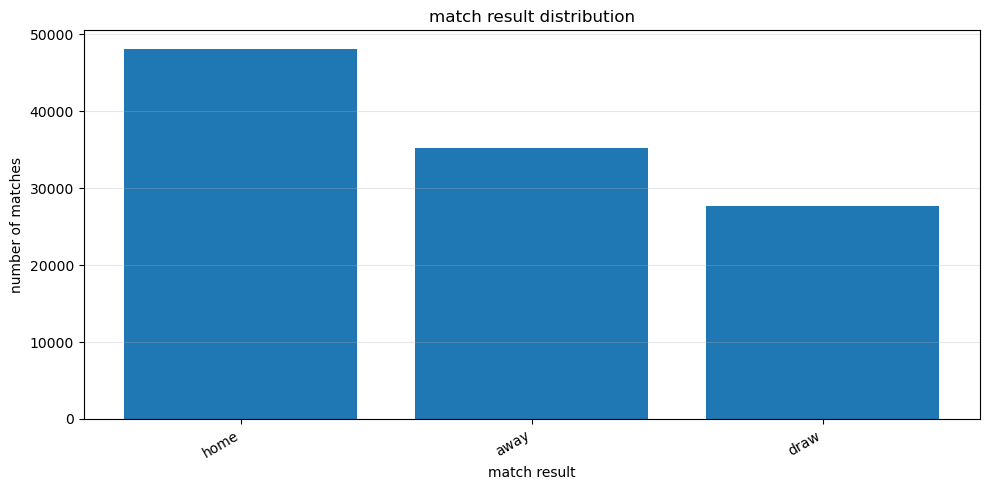

majority class:home
majority baseline accuracy :0.4337
Saved: c:\Users\mojta_tok6stl\OneDrive\Desktop\learning_ai\Football_Match_Prediction\reports\phase_2_eda\class_balance_report.json


,majority_class,majority_baseline_accuracy,number_of_classes,target_missing_count,total_rows,valid_target_rows
0,home,0.433693,3,0,110938,110938


In [23]:
target_values = prepare_categorical_series(df_eda[TARGET_COL])

target_counts = target_values.value_counts(dropna=False)
target_percentage = target_values.value_counts(normalize=True,dropna=False).mul(100).round(2)



target_distribution = pd.DataFrame({
    'count': target_counts,
    'percentage': target_percentage
})

target_distribution.index.name = TARGET_COL


print('Target distribution')
print('*'*60)

display(target_distribution)

safe_save_csv(
    target_distribution.reset_index(),
    'target_distribution.csv',
    index=False
)

plot_bar(
    target_distribution['count'],
    title='match result distribution',
    xlabel='match result',
    ylabel='number of matches',
    filename='01_match_result_distribution.png',
    rotation=30
)

valid_target_values = df_eda[TARGET_COL].dropna()


if len(valid_target_values) >0 :
    valid_target_counts = valid_target_values.value_counts()
    
    
    majority_class = valid_target_counts.idxmax()
    majority_baseline_acccuracy = valid_target_counts.max()/ len(valid_target_values)
    
    print(f'majority class:{majority_class}')
    print(f'majority baseline accuracy :{majority_baseline_acccuracy:.4f}')
    
    
    class_balance_report = {
        'majority_class': str(majority_class),
        'majority_baseline_accuracy': float(majority_baseline_acccuracy),
        'number_of_classes':int(valid_target_counts.nunique()),
        'target_missing_count': int(df_eda[TARGET_COL].isna().sum()),
        'total_rows': int(len(df_eda)),
        'valid_target_rows': int(len(valid_target_values))
    }
    
    
    safe_save_json(class_balance_report,'class_balance_report.json')
    
    display(pd.DataFrame([class_balance_report]))
    
else:
    raise ValueError('target  column has no valid non-missing values')

fixture date analysis
********************************************************************************
original non-null fixture_date values: 110,938
successfully parsed fixture_date values :110,938
fixture date parse success:100.00%
minimum fixture date: 2019-12-01 00:45:00
maximum fixture date: 2021-05-01 00:00:00

matches by year


,year,matches_count
0,2019,6105
1,2020,71588
2,2021,33245


Saved: c:\Users\mojta_tok6stl\OneDrive\Desktop\learning_ai\Football_Match_Prediction\reports\phase_2_eda\yearly_match_counts.csv
Saved: c:\Users\mojta_tok6stl\OneDrive\Desktop\learning_ai\Football_Match_Prediction\reports\phase_2_eda\monthly_match_counts.csv
saved figure:c:\Users\mojta_tok6stl\OneDrive\Desktop\learning_ai\Football_Match_Prediction\reports\phase_2_eda\figures\02_matches_by_year.png


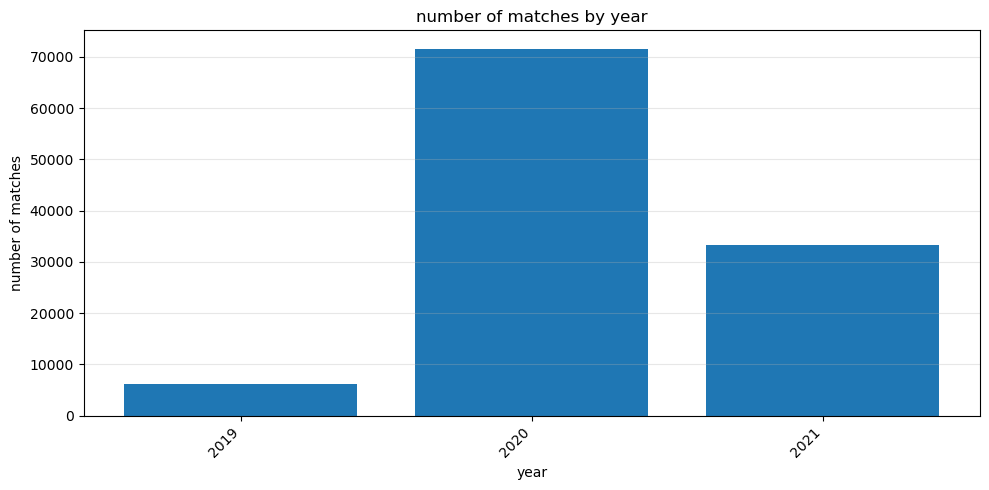

saved figure:c:\Users\mojta_tok6stl\OneDrive\Desktop\learning_ai\Football_Match_Prediction\reports\phase_2_eda\figures\03_matches_by_month.png


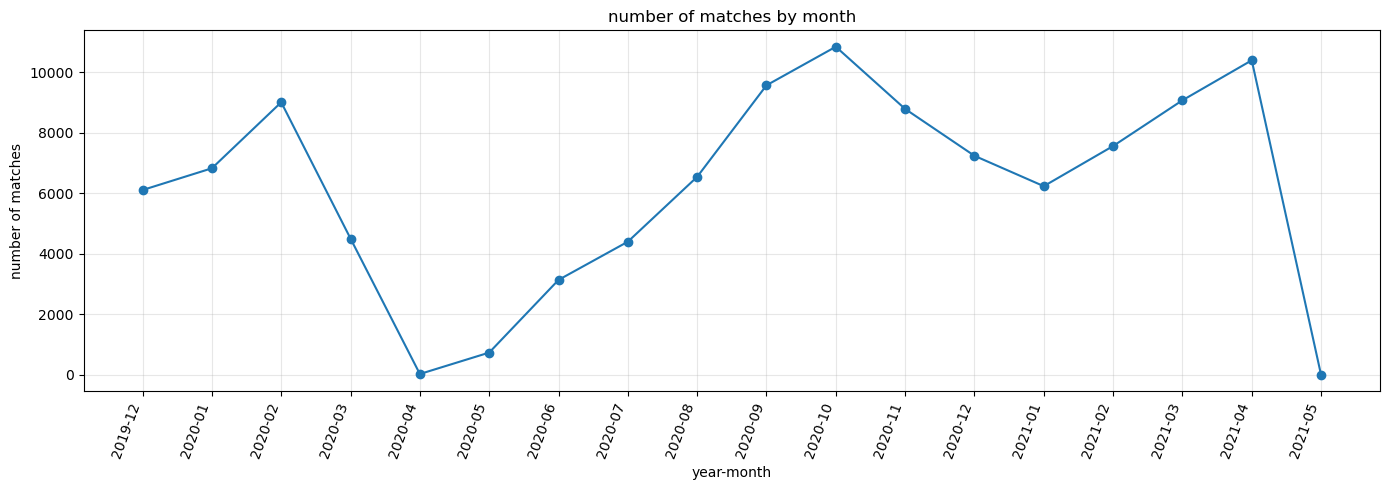

In [24]:

eda_df = df.copy()

if 'fixture_date' in eda_df.columns:
    eda_df['fixture_date_parsed'] = pd.to_datetime(
        eda_df['fixture_date'], errors='coerce'
    )
    
    original_non_null_dates = eda_df['fixture_date'].notna().sum()
    parsed_non_null_dates = eda_df['fixture_date_parsed'].notna().sum()
    
    
    if original_non_null_dates > 0:
        date_parse_success = parsed_non_null_dates / original_non_null_dates*100
    else:
        date_parse_success = 0
        
        
    print('fixture date analysis')
    print('*'*80)
    
    print(f'original non-null fixture_date values: {original_non_null_dates:,}')
    print(f'successfully parsed fixture_date values :{parsed_non_null_dates:,}')
    print(f'fixture date parse success:{date_parse_success:.2f}%')
    print(f'minimum fixture date: {eda_df['fixture_date_parsed'].min()}')
    print(f'maximum fixture date: {eda_df['fixture_date_parsed'].max()}')
    
    
    eda_df['fixture_year'] = eda_df['fixture_date_parsed'].dt.year
    eda_df['fixture_month'] = eda_df['fixture_date_parsed'].dt.month
    eda_df['fixture_year_month'] = eda_df['fixture_date_parsed'].dt.to_period('M').astype(str)
    
    
    valid_date_df = eda_df[eda_df['fixture_date_parsed'].notna()].copy()
    
    
    yearly_match_counts = (
        valid_date_df['fixture_year'].astype(int).value_counts().sort_index()
    )
    
    monthly_match_counts = (valid_date_df['fixture_year_month'].value_counts().sort_index())
    
    
    yearly_match_counts.name = 'matches_count'
    monthly_match_counts.name = 'matches_count'
    
    yearly_match_counts.index.name = 'year'
    monthly_match_counts.index.name = 'year_month'
    
    print("\nmatches by year")
    display(yearly_match_counts.reset_index())
    
    safe_save_csv(
            yearly_match_counts.reset_index(),
            'yearly_match_counts.csv',
            index=False
    )
    
    safe_save_csv(
        monthly_match_counts.reset_index(),
        'monthly_match_counts.csv',
        index=False
    )
    
    
    plot_bar(
        yearly_match_counts,
        title='number of matches by year',
        xlabel='year',
        ylabel='number of matches',
        filename='02_matches_by_year.png',
        rotation=45
    )
    
    
    
    if len(monthly_match_counts) <= 120:
        plot_line(
                monthly_match_counts,
                title='number of matches by month',
                xlabel='year-month',
                ylabel='number of matches',
                filename='03_matches_by_month.png',
                rotation=70,
                figsize=(14,5)
        )
    else:
        print("Monthly plot skipped because there are too many months to display clearly.")
else:
        print("fixture_date column does not exist. Skipping date analysis ")    

Competition distribution
------------------------------------------------------------


,matches_count,percentage
competition,,
Premier League,5565,5.02
Club Friendlies,3724,3.36
Primera Division,2369,2.14
Super League,1530,1.38
3. Liga,1327,1.20
Ligue 1,1210,1.09
Championship,1097,0.99
League One,1050,0.95
Superliga,1048,0.94


Saved: c:\Users\mojta_tok6stl\OneDrive\Desktop\learning_ai\Football_Match_Prediction\reports\phase_2_eda\competition_counts.csv
saved figure:c:\Users\mojta_tok6stl\OneDrive\Desktop\learning_ai\Football_Match_Prediction\reports\phase_2_eda\figures\04_top_competitions.png


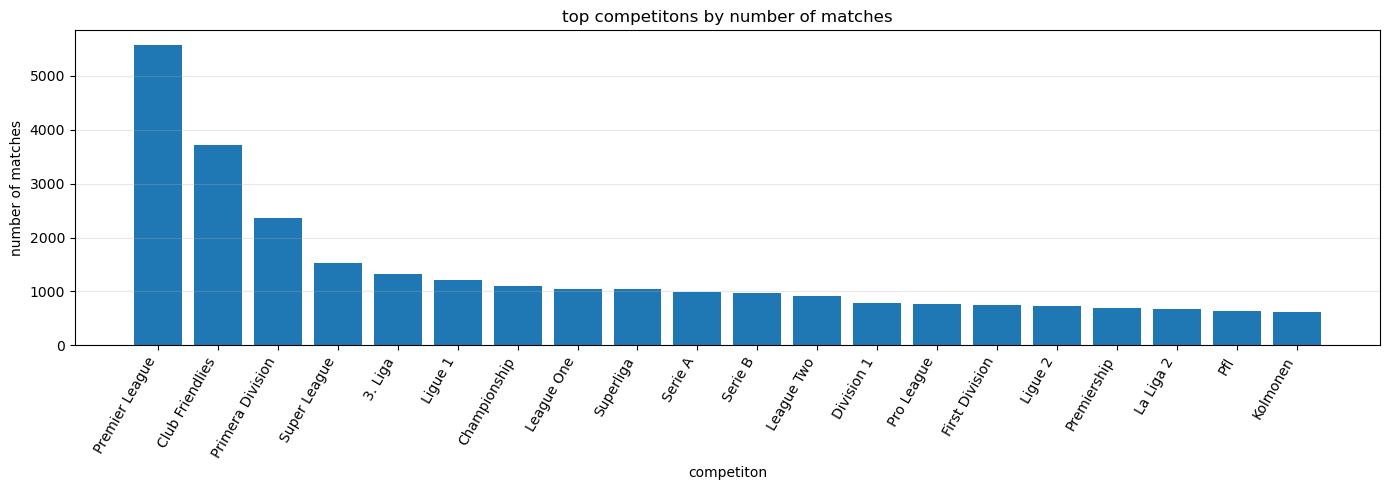


minimum matches required per competition : 554


match_result,away,draw,home,row_count
competition,,,,
Premier League,32.94,26.59,40.47,5565
Club Friendlies,31.23,22.72,46.05,3724
Primera Division,27.73,29.59,42.68,2369
Super League,28.63,28.56,42.81,1530
3. Liga,33.84,24.49,41.67,1327
Ligue 1,29.42,29.67,40.91,1210
Championship,33.55,26.34,40.11,1097
League One,31.81,25.90,42.29,1050
Superliga,31.87,25.76,42.37,1048


Saved: c:\Users\mojta_tok6stl\OneDrive\Desktop\learning_ai\Football_Match_Prediction\reports\phase_2_eda\competition_target_distribution.csv
saved figure:c:\Users\mojta_tok6stl\OneDrive\Desktop\learning_ai\Football_Match_Prediction\reports\phase_2_eda\figures\05_target_distribution_by_competition.png


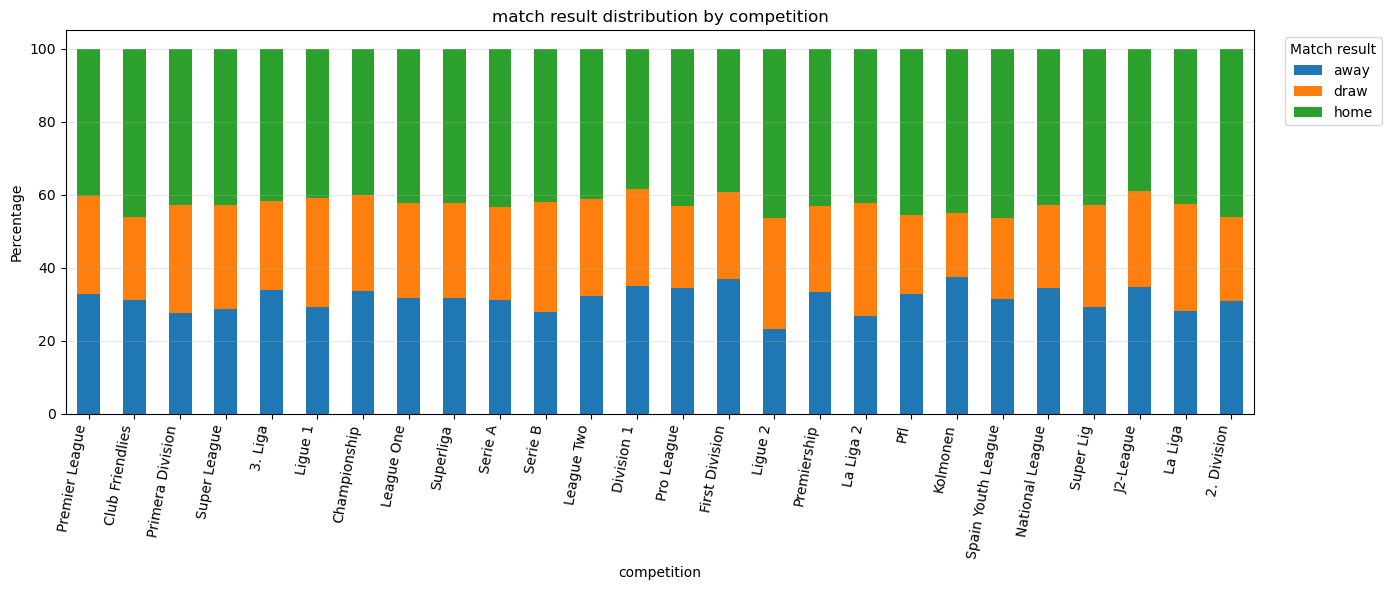

In [25]:
if 'competition' in eda_df.columns:
    competition_values = prepare_categorical_series(eda_df['competition'])
    
    competition_counts = competition_values.value_counts(dropna=False)
    competition_percentage = competition_values.value_counts(normalize=True,dropna=False).mul(100).round(2)
    
    competition_summary = pd.DataFrame({
        'matches_count': competition_counts,
        'precentage': competition_percentage
    })
    
    competition_summary = pd.DataFrame({
        'matches_count': competition_counts,
        'percentage': competition_percentage
    })
    
    
    competition_summary.index.name = 'competition'
    
    print('Competition distribution')
    print('-'*60)
    
    display(competition_summary.head(30))
    
    safe_save_csv(
            competition_summary.reset_index(),
            'competition_counts.csv',
            index=False
    )
    
    plot_bar(
        competition_counts.head(20),
        title='top competitons by number of matches',
        xlabel='competiton',
        ylabel='number of matches',
        filename='04_top_competitions.png',
        rotation=60,
        figsize=(14,5)
    )
    
    min_competition_count = max(20,int(len(eda_df)*0.005))
    
    competition_target_distribution = target_distribution_by_group(
        eda_df,group_col='competition',min_count=min_competition_count,target_col =TARGET_COL
    )
    
    
    print(f'\nminimum matches required per competition : {min_competition_count:,}')
    
    
    if not competition_target_distribution.empty:
        display(competition_target_distribution.head(30))
        
        safe_save_csv(
            competition_target_distribution.reset_index().rename(columns={'index':'competition'}),
            'competition_target_distribution.csv',
            index=False
        )
        
        plot_stacked_percentage(
            competition_target_distribution.drop(columns=['row_count']).head(30),
            title='match result distribution by competition',
            xlabel= 'competition',
            filename='05_target_distribution_by_competition.png',
            rotation=80,
            figsize=(14,6)
        )
    else:
        print('no competition group has enough records for target distribution analysis')
else:
    print("competition column does not exist. Skipping competition analysis.")

cup game distribution
------------------------------------------------------------


,count,percentage
cup_game,,
False,101856,91.81
True,9081,8.19
missing,1,0.00


Saved: c:\Users\mojta_tok6stl\OneDrive\Desktop\learning_ai\Football_Match_Prediction\reports\phase_2_eda\cup_game_distribution.csv

 target distribution by cup game:


match_result,away,draw,home
cup_game,,,
False,31.35,25.24,43.41
True,35.70,21.41,42.89
missing,100.00,0.00,0.00


Saved: c:\Users\mojta_tok6stl\OneDrive\Desktop\learning_ai\Football_Match_Prediction\reports\phase_2_eda\cup_game_target_distribution.csv
saved figure:c:\Users\mojta_tok6stl\OneDrive\Desktop\learning_ai\Football_Match_Prediction\reports\phase_2_eda\figures\06_target_distribution_by_cup_game.png


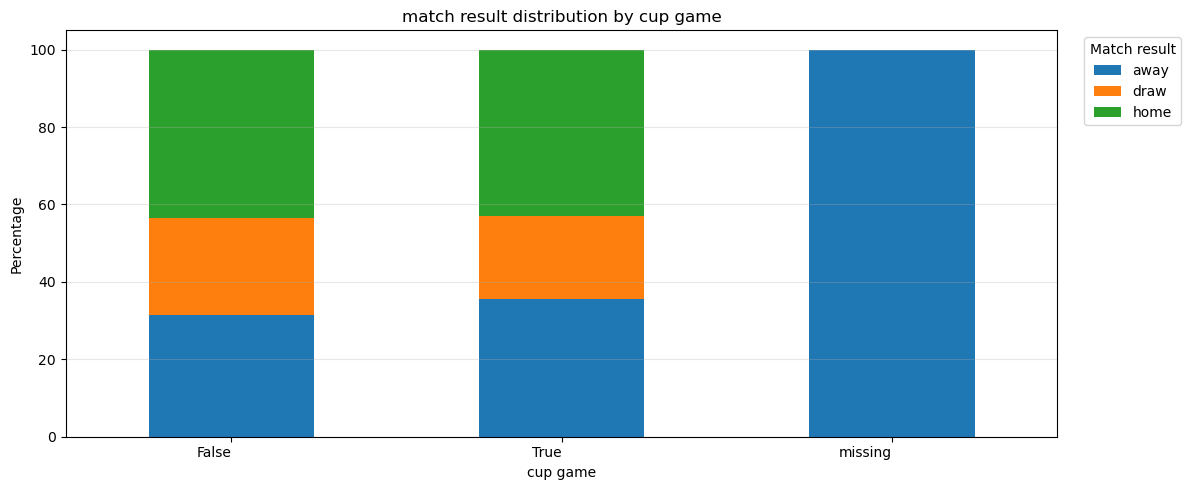

In [26]:
if 'cup_game' in eda_df.columns:
    cup_values = prepare_categorical_series(eda_df['cup_game'])
    
    
    cup_counts = cup_values.value_counts(dropna=False)
    cup_percentages = cup_values.value_counts(normalize=True,dropna=False).mul(100).round(2)
    
    
    cup_summary = pd.DataFrame({
        'count': cup_counts,
        'percentage': cup_percentages
    })
    
    cup_summary.index.name ='cup_game'
    
    print('cup game distribution')
    print('-'*60)
    
    display(cup_summary)
    
    
    safe_save_csv(
        cup_summary.reset_index(),
        'cup_game_distribution.csv',
        index=False
    )
    
    
    cup_target_distribution = crosstab_percentage(
        eda_df,
        row_col='cup_game',
        target_col=TARGET_COL
    )
    
    print('\n target distribution by cup game:')
    display(cup_target_distribution)
    
    
    safe_save_csv(
        cup_target_distribution.reset_index().rename(columns={'index':'cup_game'}),'cup_game_target_distribution.csv',index=False
    )
    
    
    plot_stacked_percentage(
        cup_target_distribution,
        title='match result distribution by cup game',
        xlabel='cup game',
        filename='06_target_distribution_by_cup_game.png',
        rotation=0
    )
    
else:
    print("cup_game column does not exist  Skipping cup game analysis ")

home club  distribution
------------------------------------------------------------


,home_matches,percentage
home_club,,
Al Ittihad,91,0.08
River Plate,71,0.06
Rangers,64,0.06
Liverpool,63,0.06
Al Ahli,62,0.06
Juventus,61,0.05
Independiente,60,0.05
Internacional,59,0.05
Olimpia,58,0.05


Saved: c:\Users\mojta_tok6stl\OneDrive\Desktop\learning_ai\Football_Match_Prediction\reports\phase_2_eda\home_club_counts.csv
saved figure:c:\Users\mojta_tok6stl\OneDrive\Desktop\learning_ai\Football_Match_Prediction\reports\phase_2_eda\figures\07_top_home_clubs.png


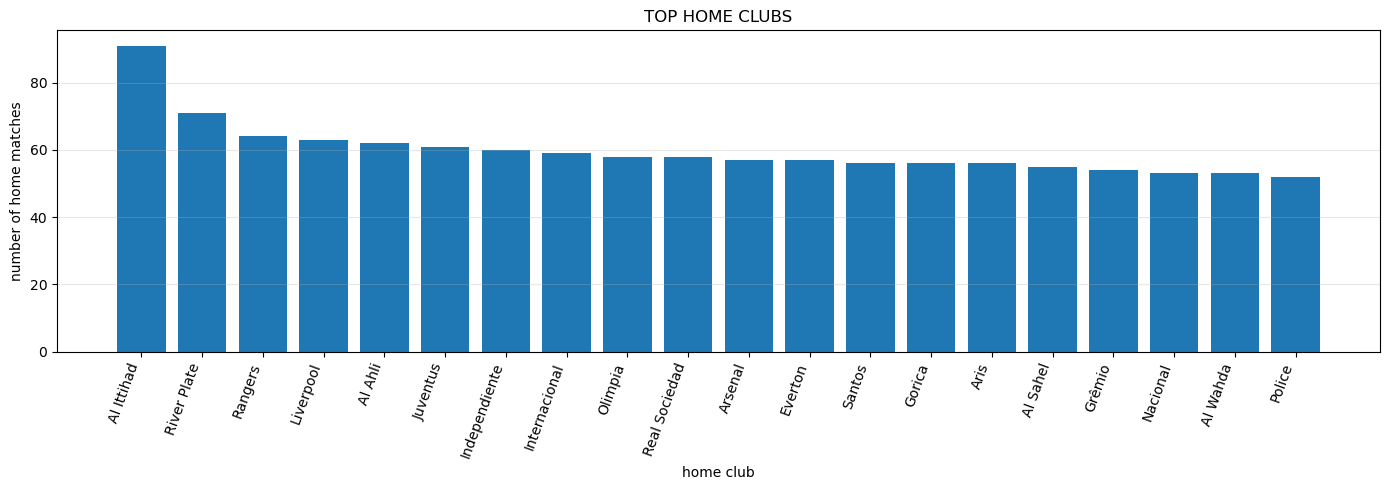


away club distribution
--------------------------------------------------------------------------------


,away_matches,percentage
away_club,,
Al Ittihad,82,0.07
River Plate,77,0.07
Liverpool,65,0.06
Rangers,64,0.06
Al Ahli,64,0.06
Olimpia,63,0.06
Arsenal,59,0.05
Real Sociedad,58,0.05
Santos,57,0.05


Saved: c:\Users\mojta_tok6stl\OneDrive\Desktop\learning_ai\Football_Match_Prediction\reports\phase_2_eda\away_club_counts.csv
saved figure:c:\Users\mojta_tok6stl\OneDrive\Desktop\learning_ai\Football_Match_Prediction\reports\phase_2_eda\figures\08_top_away_clubs.png


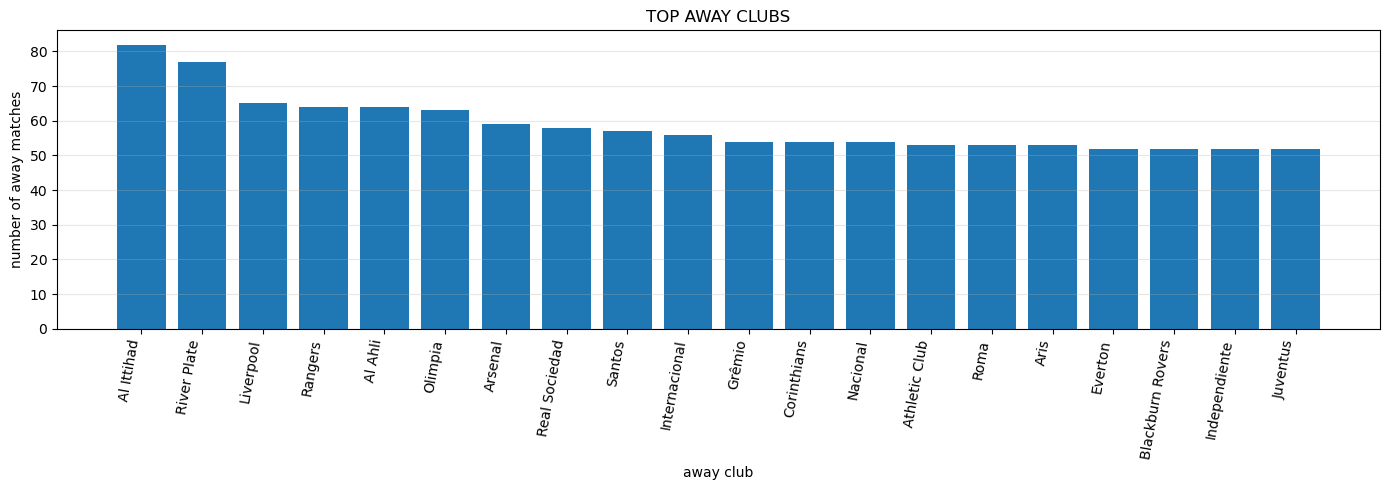


 combined club coverage
----------------------------------------------------------------------


,total_appearances,percentage
club,,
Al Ittihad,173,0.08
River Plate,148,0.07
Liverpool,128,0.06
Rangers,128,0.06
Al Ahli,126,0.06
Olimpia,121,0.05
Real Sociedad,116,0.05
Arsenal,116,0.05
Internacional,115,0.05


Saved: c:\Users\mojta_tok6stl\OneDrive\Desktop\learning_ai\Football_Match_Prediction\reports\phase_2_eda\combined_club_coverage.csv
unique clubs : 10,215
clubs with fewer than 5 appearances :1,533
clubs with fewer than 10 appearances :3,263
median club appearances : 16.00
Saved: c:\Users\mojta_tok6stl\OneDrive\Desktop\learning_ai\Football_Match_Prediction\reports\phase_2_eda\club_coverage_report.json


In [27]:
if 'home_club' in eda_df.columns:
    home_club_values = prepare_categorical_series(eda_df['home_club'])
    
    home_club_counts = home_club_values.value_counts(dropna=False)
    home_club_percentages = home_club_values.value_counts(normalize=True,dropna=False).mul(100).round(2)
    
    
    home_club_summary = pd.DataFrame({
        'home_matches': home_club_counts,
        'percentage': home_club_percentages
    })
    
    home_club_summary.index.name = 'home_club'
    
    print('home club  distribution')
    print('-'*60)
    
    
    display(home_club_summary.head(30))
    
    
    safe_save_csv(
        home_club_summary.reset_index(),
        'home_club_counts.csv',
        index=False
    )
    
    
    plot_bar(
        home_club_counts.head(20),
        title= 'TOP HOME CLUBS',
        xlabel='home club',
        ylabel='number of home matches',
        filename='07_top_home_clubs.png',
        rotation= 70,
        figsize=(14,5)
    )
    
else:
    print('home club column does not exist  skipping home club analysis')


if 'away_club' in eda_df.columns:
    away_club_values = prepare_categorical_series(eda_df['away_club'])
    
    away_club_counts = away_club_values.value_counts(dropna=False)
    away_club_percentages = away_club_values.value_counts(normalize=True,dropna=False).mul(100).round(2)
    
    
    away_club_summary = pd.DataFrame({
        'away_matches': away_club_counts,
        'percentage': away_club_percentages
    })
    
    away_club_summary.index.name = 'away_club'
    
    print('\naway club distribution')
    print('-'*80)
    
    display(away_club_summary.head(30))
    
    safe_save_csv(
        away_club_summary.reset_index(),
        'away_club_counts.csv',
        index=False
    )
    
    plot_bar(
        away_club_counts.head(20),
        title='TOP AWAY CLUBS',
        xlabel= 'away club',
        ylabel= 'number of away matches',
        filename='08_top_away_clubs.png',
        rotation=80,
        figsize=(14,5)
    )
else:
    print('away club columns does not exist skipping away club analysis')
    

if 'home_club' in eda_df.columns and 'away_club' in eda_df.columns:
    combined_clubs = pd.concat(
        [
            prepare_categorical_series(eda_df['home_club']),
            prepare_categorical_series(eda_df['away_club'])
        ],
        axis=0,
        ignore_index=True
    )
    
    combined_club_counts = combined_clubs.value_counts(dropna=False)
    combined_club_percentages = combined_clubs.value_counts(normalize=True,dropna=False).mul(100).round(2)
    
    
    combined_club_summary = pd.DataFrame({
        'total_appearances': combined_club_counts,
        'percentage': combined_club_percentages
    })
    
    combined_club_summary.index.name = 'club'
    print('\n combined club coverage')
    print('-'*70)
    
    
    display(combined_club_summary.head(30))
    
    safe_save_csv(
            combined_club_summary.reset_index(),
            'combined_club_coverage.csv',
            index=False
    )
    
    rare_clubs_less_5 = int((combined_club_counts <5).sum())
    rare_clubs_less_10 = int((combined_club_counts<10).sum())
    
    
    club_coverage_report = {
        'unique_clubs': int(combined_club_counts.shape[0]),
        'clubs_with_fewer_than_5_appearances': rare_clubs_less_5,
        'clubs_with_fewer_than_10_appearances': rare_clubs_less_10,
        'max_club_appearances': int(combined_club_counts.max()),
        'median_club_appearances': float(combined_club_counts.median())
    }
    
    
    print(f'unique clubs : {club_coverage_report['unique_clubs']:,}')
    print(f'clubs with fewer than 5 appearances :{rare_clubs_less_5:,}')
    print(f'clubs with fewer than 10 appearances :{rare_clubs_less_10:,}')
    print(f'median club appearances : {club_coverage_report['median_club_appearances']:.2f}')
    
    
    safe_save_json(
        club_coverage_report,'club_coverage_report.json'
    )
else:
    print('home club and away_club columns are not both available skipping combined club analysis')

relevent missing values analysis
--------------------------------------------------------------------------------


,column,missing_count,missing_percentage,dtype,unique_count
179,away_club_recent_manager_id_10,27129,24.45,float64,7936
89,home_club_recent_manager_id_10,26653,24.03,float64,7891
178,away_club_recent_manager_id_9,26150,23.57,float64,8044
88,home_club_recent_manager_id_9,25733,23.20,float64,8002
177,away_club_recent_manager_id_8,25219,22.73,float64,8144
87,home_club_recent_manager_id_8,24869,22.42,float64,8150
176,away_club_recent_manager_id_7,24377,21.97,float64,8303
86,home_club_recent_manager_id_7,23980,21.62,float64,8265
175,away_club_recent_manager_id_6,23525,21.21,float64,8440
85,home_club_recent_manager_id_6,23258,20.96,float64,8385


Saved: c:\Users\mojta_tok6stl\OneDrive\Desktop\learning_ai\Football_Match_Prediction\reports\phase_2_eda\relevant_missing_values.csv
saved figure:c:\Users\mojta_tok6stl\OneDrive\Desktop\learning_ai\Football_Match_Prediction\reports\phase_2_eda\figures\09_top_relevant_missing_values.png


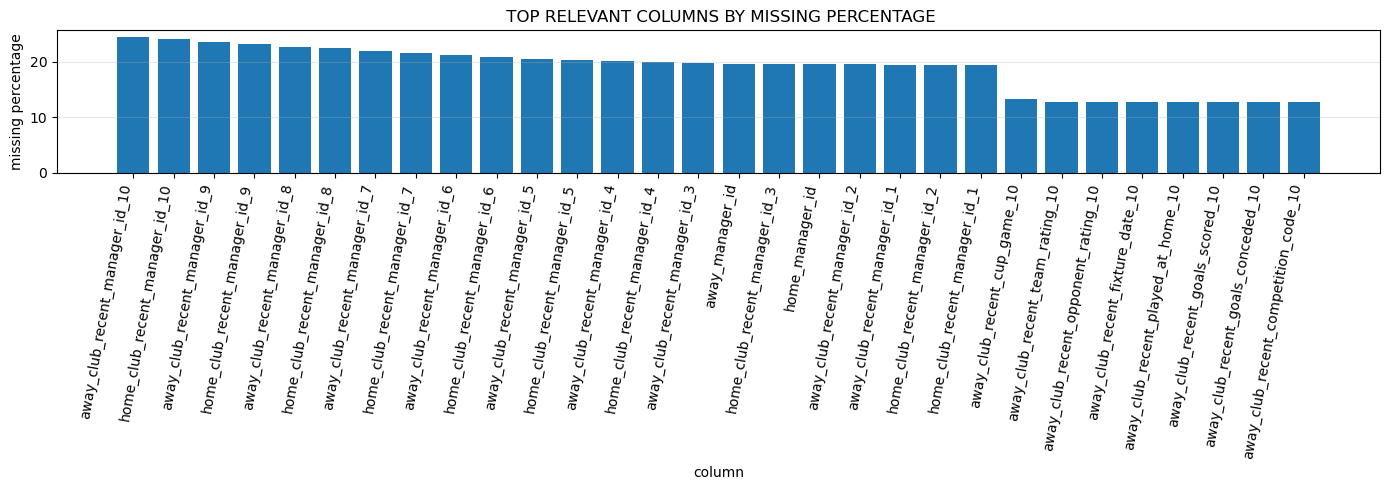

In [28]:
recent_columns_info_eda = recent_pattern_info(eda_df)

recent_cols = (
    recent_columns_info_eda['column'].tolist()
    if not recent_columns_info_eda.empty
    else []
)

main_existing_cols = [col for col in MAIN_MATCH_COLUMNS if col in eda_df.columns]

relevant_columns = list(dict.fromkeys(main_existing_cols+recent_cols))

print('relevent missing values analysis')
print('-'*80)


if len(relevant_columns) == 0:
    relevant_missing_summary = pd.DataFrame()
    print('no relevant columns were found for missing-value analysis')

else:
    relevant_missing_summary  = pd.DataFrame({
        'column': relevant_columns,
        'missing_count': [int(eda_df[col].isna().sum() ) for col in relevant_columns],
        'missing_percentage': [round(eda_df[col].isna().mean()*100,2) for col in relevant_columns],
        'dtype': [str(eda_df[col].dtype) for col in relevant_columns],
        'unique_count':[int(eda_df[col].nunique(dropna=True)) for col in relevant_columns]
    })
    
    relevant_missing_summary = relevant_missing_summary.sort_values(
        ['missing_percentage','missing_count'],
        ascending=[False,False]
    )
    
    display(relevant_missing_summary.head(30))
    
    safe_save_csv(
        relevant_missing_summary,
        'relevant_missing_values.csv',
        index = False
    )
    
    top_missing_relevant = (
        relevant_missing_summary[relevant_missing_summary['missing_count']>0].head(30)
    )
    
    if not top_missing_relevant.empty:
        plot_bar( 
                top_missing_relevant.set_index('column')['missing_percentage'],
                title =' TOP RELEVANT COLUMNS BY MISSING PERCENTAGE',
                xlabel='column',
                ylabel='missing percentage',
                filename= '09_top_relevant_missing_values.png',
                rotation=80,
                figsize=(14,5)
                )
    else:
        print('no missing values were found in relevant columns')

In [29]:
print('recent-history columns analysis')
print('-'*80)

recent_columns_info_eda = recent_pattern_info(eda_df)

print(f'number of detected recent_history columns : {len(recent_columns_info_eda)}')

if not recent_columns_info_eda.empty:
    recent_columns_info_eda = recent_columns_info_eda.sort_values(
        ['club_side','feature','recent_number']
    )
    
    display(recent_columns_info_eda.head(30))
    
    safe_save_csv(
        recent_columns_info_eda,
        'recent_colunmns_info_eda.csv',
        index=False
    )
    
    
    recent_feature_availability = (
        recent_columns_info_eda
        .groupby(['club_side','feature'])
        .agg(
            deteceted_lags= ('recent_number',lambda x: sorted(set(x))),
            deteceted_count=('recent_number','unique'),
            avg_missing_percentage = ('missing_percentage','mean'),
            max_missing_percentage = ('missing_percentage','max'),
            avg_unique_count = ('unique_count','mean')
        )
        .reset_index()
        .sort_values(['club_side','feature'])
    )
    
    
    recent_feature_availability['avg_missing_percentage']= (
        recent_feature_availability['avg_missing_percentage'].round(2)
    )
    
    recent_feature_availability['max_missing_percentage'] = (
        recent_feature_availability['max_missing_percentage'].round(2)
    )
    recent_feature_availability['avg_unique_count'] = (
        recent_feature_availability['avg_unique_count'].round(2)
    )
    
    print('\n recent feature availability: ')
    display(recent_feature_availability)
    
    
    safe_save_csv(
        recent_feature_availability,
        'recent_feature_availability.csv',
        index=False
    )
    
    
    expected_lags  = set(range(1,11))
    completeness_rows  = []
    
    
    for (club_side, feature) , group  in recent_columns_info_eda.groupby(['club_side','feature']):
        detected_lags  = set(group['recent_number'].tolist())
        
        completeness_rows.append({
            'club_side':club_side,
            'feature': feature,
            'expected_lags': sorted(detected_lags),
            'detected_lags': len(detected_lags),
            'missing_lags': sorted(expected_lags - detected_lags),
            'extra_lags': sorted(detected_lags - expected_lags),
            'is_complete_1_to_10': detected_lags == expected_lags
        })
        
    recent_completeness = (
        pd.DataFrame(completeness_rows).sort_values(['club_side','feature'])
    )
    
    print('\n recent-history lag completeneess')
    display(recent_completeness)
    
    safe_save_csv(
        recent_completeness,
        'recent_history_completeness.csv',
        index=False
    )
    
    incomplete_recent_features = recent_completeness[~recent_completeness['is_complete_1_to_10']]
    
    if len(incomplete_recent_features) == 0:
        print('all detected recent-history features are complete from lag 1 to lag 10')
        
    else:
        print('warning --> some recent history features are incomplete')
        display(incomplete_recent_features)
        
        
else:
    recent_feature_availability = pd.DataFrame()
    recent_completeness = pd.DataFrame()
    print('no recent-history columns were found')

recent-history columns analysis
--------------------------------------------------------------------------------
number of detected recent_history columns : 180


,column,club_side,feature,recent_number,dtype,missing_count,missing_percentage,unique_count
170,away_club_recent_competition_code_1,away_club,competition_code,1,float64,1226,1.11,864
171,away_club_recent_competition_code_2,away_club,competition_code,2,float64,2593,2.34,856
172,away_club_recent_competition_code_3,away_club,competition_code,3,float64,4034,3.64,854
173,away_club_recent_competition_code_4,away_club,competition_code,4,float64,5516,4.97,850
174,away_club_recent_competition_code_5,away_club,competition_code,5,float64,7000,6.31,836
175,away_club_recent_competition_code_6,away_club,competition_code,6,float64,8426,7.60,828
176,away_club_recent_competition_code_7,away_club,competition_code,7,float64,9867,8.89,821
177,away_club_recent_competition_code_8,away_club,competition_code,8,float64,11295,10.18,808
178,away_club_recent_competition_code_9,away_club,competition_code,9,float64,12762,11.50,791
179,away_club_recent_competition_code_10,away_club,competition_code,10,float64,14216,12.81,777


Saved: c:\Users\mojta_tok6stl\OneDrive\Desktop\learning_ai\Football_Match_Prediction\reports\phase_2_eda\recent_colunmns_info_eda.csv

 recent feature availability: 


,club_side,feature,deteceted_lags,deteceted_count,avg_missing_percentage,max_missing_percentage,avg_unique_count
0,away_club,competition_code,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10]","[1, 2, 3, 4, 5, 6, 7, 8, 9, 10]",6.94,12.81,828.5
1,away_club,cup_game,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10]","[1, 2, 3, 4, 5, 6, 7, 8, 9, 10]",7.22,13.36,2.0
2,away_club,fixture_date,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10]","[1, 2, 3, 4, 5, 6, 7, 8, 9, 10]",6.94,12.81,19651.7
3,away_club,goals_conceded,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10]","[1, 2, 3, 4, 5, 6, 7, 8, 9, 10]",6.94,12.81,15.6
4,away_club,goals_scored,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10]","[1, 2, 3, 4, 5, 6, 7, 8, 9, 10]",6.94,12.81,16.9
5,away_club,manager_id,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10]","[1, 2, 3, 4, 5, 6, 7, 8, 9, 10]",21.35,24.45,8485.7
6,away_club,opponent_rating,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10]","[1, 2, 3, 4, 5, 6, 7, 8, 9, 10]",6.94,12.82,97015.8
7,away_club,played_at_home,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10]","[1, 2, 3, 4, 5, 6, 7, 8, 9, 10]",6.94,12.81,2.0
8,away_club,team_rating,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10]","[1, 2, 3, 4, 5, 6, 7, 8, 9, 10]",6.94,12.82,97057.5
9,home_club,competition_code,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10]","[1, 2, 3, 4, 5, 6, 7, 8, 9, 10]",6.54,12.22,831.3


Saved: c:\Users\mojta_tok6stl\OneDrive\Desktop\learning_ai\Football_Match_Prediction\reports\phase_2_eda\recent_feature_availability.csv

 recent-history lag completeneess


,club_side,feature,expected_lags,detected_lags,missing_lags,extra_lags,is_complete_1_to_10
0,away_club,competition_code,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10]",10,[],[],True
1,away_club,cup_game,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10]",10,[],[],True
2,away_club,fixture_date,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10]",10,[],[],True
3,away_club,goals_conceded,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10]",10,[],[],True
4,away_club,goals_scored,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10]",10,[],[],True
5,away_club,manager_id,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10]",10,[],[],True
6,away_club,opponent_rating,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10]",10,[],[],True
7,away_club,played_at_home,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10]",10,[],[],True
8,away_club,team_rating,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10]",10,[],[],True
9,home_club,competition_code,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10]",10,[],[],True


Saved: c:\Users\mojta_tok6stl\OneDrive\Desktop\learning_ai\Football_Match_Prediction\reports\phase_2_eda\recent_history_completeness.csv
all detected recent-history features are complete from lag 1 to lag 10


In [30]:
print('recent fixture data leakage check')
print('-'*80)

leakage_date_rows = []
violation_examples = []


if 'fixture_date_parsed' not in eda_df.columns and 'fixture_date' in eda_df.columns:
    eda_df['fixture_date_parsed'] = pd.to_datetime(
        eda_df['fixture_date'],
        errors='coerce'
    )
    
    

if 'fixture_date_parsed' in eda_df.columns:
    
    current_dates = eda_df['fixture_date_parsed']
    
    for side in ['home_club','away_club']:
        recent_date_cols = get_recent_columns(
            side,
            'fixture_date',
            numbers=range(1,11),
            dataframe=eda_df
        )
        
        
        for col in recent_date_cols:
            recent_dates = pd.to_datetime(eda_df[col],errors='coerce')
            
            valid_mask = current_dates.notna() & recent_dates.notna()
            violation_mask = valid_mask & (recent_dates >= current_dates)
            
            valid_comparisons = int(valid_mask.sum())
            violation_count = int(violation_mask.sum())
            
            
            leakage_date_rows.append({
                'column': col,
                'side': side,
                'valid_comparisons': valid_comparisons,
                'violation_count': violation_count,
                'violation_percentage':(
                    round(violation_count/valid_comparisons *100,4)
                    if valid_comparisons>0
                    else np.nan
                ),
                
                'min_recent_date':recent_dates.min(),
                'max_recent_date': recent_dates.max()
            })
            
            
            if violation_count > 0:
                example_cols  = []
                
                if ID_COL in eda_df.columns:
                    example_cols.append(ID_COL)
                    
                example_cols += ['fixture_date_parsed',col]
                
                temp_examples = eda_df.loc[violation_mask,example_cols].copy()
                temp_examples['violation_column'] = col
                temp_examples = temp_examples.rename(columns={
                    'fixture_date_parsed': 'current_fixture_date',
                    col : 'recent_fixture_date'
                })                    
                
                
                violation_examples.append(temp_examples.head(5))
                
    recent_date_leakage_check = pd.DataFrame(leakage_date_rows)
    
    if not recent_date_leakage_check.empty:
        recent_date_leakage_check = recent_date_leakage_check.sort_values(
            ['violation_count','violation_percentage'],
            ascending=[False,False]
        )
        
    display(recent_date_leakage_check)
    
    safe_save_csv(
        recent_date_leakage_check,
        'recent_fixture_date_leakage_check.csv',
        index=False
    )    
    
    total_violations  = (
        int(recent_date_leakage_check['violation_count'].sum())
        if not recent_date_leakage_check.empty
        else 0
    )
    
    
    print(f'total recent-date leakage violation :{total_violations :,}')
    
    
    if total_violations >0:
        print('warning -> some recent fixture dates are not before the current fixture date')
        print('these rows must be investigated before modeling')
        
        
        recent_date_violation_examples = pd.concat(
            violation_examples,
            axis=0,
            ignore_index=True
        ) if violation_examples  else pd.DataFrame()
        
        
        if not recent_date_violation_examples.empty:
            display(recent_date_violation_examples.head(40))
            
            safe_save_csv(
                recent_date_violation_examples,
                'recent_fixture_date_violation_examples.csv',
                index= False
            )
    else:
        
        recent_date_violation_examples = pd.DataFrame()
        print('no date leakage was detected based on recent fixture dates')
        

else:
    recent_date_leakage_check = pd.DataFrame()
    recent_date_violation_examples = pd.DataFrame()
    print('current fixture_date could not be parsed skipping recent-date leakage check')

recent fixture data leakage check
--------------------------------------------------------------------------------


,column,side,valid_comparisons,violation_count,violation_percentage,min_recent_date,max_recent_date
0,home_club_recent_fixture_date_1,home_club,109779,0,0.0,2019-01-04 14:00:00,2021-04-28 23:00:00
1,home_club_recent_fixture_date_2,home_club,108487,0,0.0,2019-01-05 02:30:00,2021-04-25 23:00:00
2,home_club_recent_fixture_date_3,home_club,107165,0,0.0,2019-01-03 15:45:00,2021-04-23 23:00:00
3,home_club_recent_fixture_date_4,home_club,105837,0,0.0,2019-01-03 15:45:00,2021-04-22 00:00:00
4,home_club_recent_fixture_date_5,home_club,104461,0,0.0,2019-01-03 15:45:00,2021-04-18 23:00:00
5,home_club_recent_fixture_date_6,home_club,103042,0,0.0,2019-01-04 22:30:00,2021-04-17 01:00:00
6,home_club_recent_fixture_date_7,home_club,101643,0,0.0,2019-01-02 16:00:00,2021-04-15 00:30:00
7,home_club_recent_fixture_date_8,home_club,100219,0,0.0,2019-01-03 23:30:00,2021-04-08 00:30:00
8,home_club_recent_fixture_date_9,home_club,98802,0,0.0,2019-01-02 16:00:00,2021-04-03 14:00:00
9,home_club_recent_fixture_date_10,home_club,97379,0,0.0,2019-01-04 11:30:00,2021-03-30 18:45:00


Saved: c:\Users\mojta_tok6stl\OneDrive\Desktop\learning_ai\Football_Match_Prediction\reports\phase_2_eda\recent_fixture_date_leakage_check.csv
total recent-date leakage violation :0
no date leakage was detected based on recent fixture dates


recent numeric feature by lag
--------------------------------------------------------------------------------


,side,feature,lag,column,non_missing_count,missing_percentage,mean,median,std,min,max,q01,q25,q75,q99
0,home_club,goals_conceded,1,home_club_recent_goals_conceded_1,109779,1.04,1.4236,1.0000,1.3501,0.0000,18.0000,0.0000,0.0000,2.0000,6.0000
1,home_club,goals_conceded,2,home_club_recent_goals_conceded_2,108487,2.21,1.3469,1.0000,1.3124,0.0000,18.0000,0.0000,0.0000,2.0000,5.0000
2,home_club,goals_conceded,3,home_club_recent_goals_conceded_3,107165,3.40,1.3762,1.0000,1.3198,0.0000,14.0000,0.0000,0.0000,2.0000,6.0000
3,home_club,goals_conceded,4,home_club_recent_goals_conceded_4,105837,4.60,1.3565,1.0000,1.3093,0.0000,18.0000,0.0000,0.0000,2.0000,6.0000
4,home_club,goals_conceded,5,home_club_recent_goals_conceded_5,104461,5.84,1.3672,1.0000,1.3096,0.0000,18.0000,0.0000,0.0000,2.0000,5.0000
5,home_club,goals_conceded,6,home_club_recent_goals_conceded_6,103042,7.12,1.3591,1.0000,1.3063,0.0000,18.0000,0.0000,0.0000,2.0000,5.0000
6,home_club,goals_conceded,7,home_club_recent_goals_conceded_7,101643,8.38,1.3587,1.0000,1.2935,0.0000,15.0000,0.0000,0.0000,2.0000,5.0000
7,home_club,goals_conceded,8,home_club_recent_goals_conceded_8,100219,9.66,1.3564,1.0000,1.2932,0.0000,18.0000,0.0000,0.0000,2.0000,5.0000
8,home_club,goals_conceded,9,home_club_recent_goals_conceded_9,98802,10.94,1.3483,1.0000,1.2890,0.0000,14.0000,0.0000,0.0000,2.0000,5.0000
9,home_club,goals_conceded,10,home_club_recent_goals_conceded_10,97379,12.22,1.3573,1.0000,1.2870,0.0000,14.0000,0.0000,0.0000,2.0000,5.0000


Saved: c:\Users\mojta_tok6stl\OneDrive\Desktop\learning_ai\Football_Match_Prediction\reports\phase_2_eda\recent_numeric_stats_by_lag.csv

 mean recent {feature} by lag:


side,away_club,home_club
lag,,
1,1.3232,1.4236
2,1.3940,1.3469
3,1.3582,1.3762
4,1.3747,1.3565
5,1.3596,1.3672
6,1.3649,1.3591
7,1.3626,1.3587
8,1.3593,1.3564
9,1.3616,1.3483


saved figure:c:\Users\mojta_tok6stl\OneDrive\Desktop\learning_ai\Football_Match_Prediction\reports\phase_2_eda\figures\10_recent_goals_conceded_mean_by_lag.png


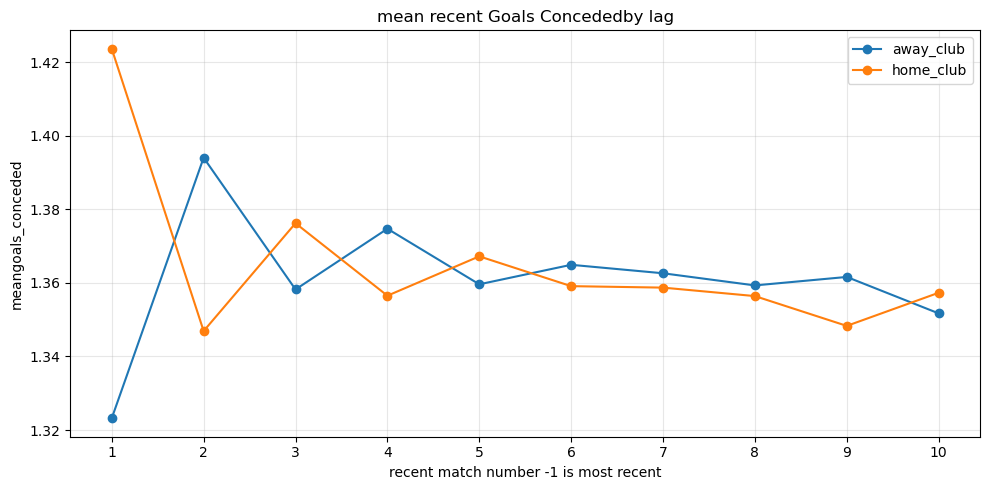


 mean recent {feature} by lag:


side,away_club,home_club
lag,,
1,6.7866,6.3255
2,6.4606,6.6516
3,6.5905,6.5266
4,6.5202,6.5976
5,6.5731,6.5488
6,6.5362,6.5821
7,6.5494,6.5564
8,6.5350,6.5595
9,6.5307,6.5506


saved figure:c:\Users\mojta_tok6stl\OneDrive\Desktop\learning_ai\Football_Match_Prediction\reports\phase_2_eda\figures\10_recent_team_rating_mean_by_lag.png


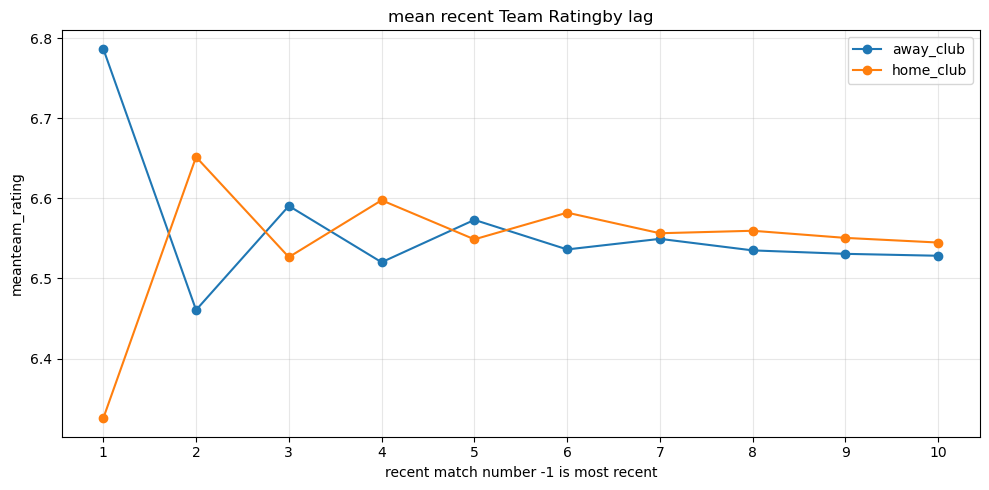


 mean recent {feature} by lag:


side,away_club,home_club
lag,,
1,6.2818,6.7494
2,6.6048,6.4047
3,6.4525,6.5329
4,6.5122,6.4438
5,6.4511,6.4748
6,6.4630,6.4311
7,6.4307,6.4335
8,6.4189,6.4136
9,6.4082,6.3919


saved figure:c:\Users\mojta_tok6stl\OneDrive\Desktop\learning_ai\Football_Match_Prediction\reports\phase_2_eda\figures\10_recent_opponent_rating_mean_by_lag.png


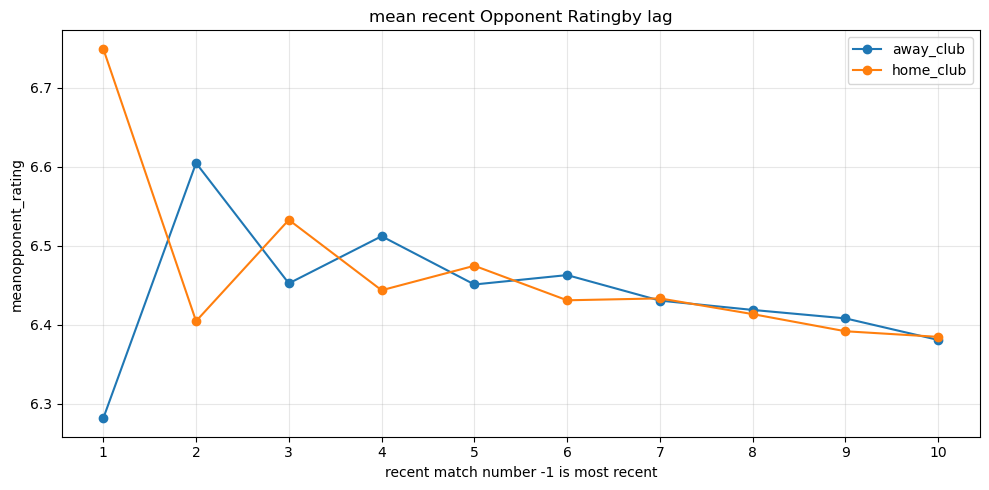

In [31]:
print('recent numeric feature by lag')
print('-'*80)

important_recent_numeric_features = [
    'golas_scored',
    'goals_conceded',
    'team_rating',
    'opponent_rating'
]

recent_numeric_stats_rows = []

for side in ['home_club','away_club']:
    for feature in important_recent_numeric_features:
        for lag in range(1,11):
            col = f'{side}_recent_{feature}_{lag}'
            
            if col not in eda_df.columns:
                continue
            
            values = to_numeric_series(eda_df[col])
            
            
            recent_numeric_stats_rows.append({
                'side':side,
                'feature':feature,
                'lag':lag,
                'column':col,
                'non_missing_count': int(values.notna().sum()),
                'missing_percentage': round(values.isna().mean()*100,2),
                'mean': values.mean(),
                'median': values.median(),
                'std': values.std(),
                'min': values.min(),
                'max':values.max(),
                'q01': values.quantile(0.01),
                'q25': values.quantile(0.25),
                'q75': values.quantile(0.75),
                'q99': values.quantile(0.99)
            })
            
recent_numeric_stats = pd.DataFrame(recent_numeric_stats_rows)
    
if not recent_numeric_stats.empty:
        numeric_round_cols = [
            'mean','median','std','min','max',
            'q01','q25','q75','q99'
        ]
        
        
        recent_numeric_stats[numeric_round_cols]= (
            recent_numeric_stats[numeric_round_cols].round(4)
        )
        
        
        display(recent_numeric_stats.head(40))
        
        
        safe_save_csv(
            recent_numeric_stats,
            'recent_numeric_stats_by_lag.csv',
            index=False
        )
        
        for feature in important_recent_numeric_features :
            temp = recent_numeric_stats[recent_numeric_stats['feature'] == feature].copy()
            
            if temp.empty:
                continue
            
            pivot_mean = temp.pivot(
                index='lag',
                columns='side',
                values='mean'
            )
            
            print('\n mean recent {feature} by lag:')
            display(pivot_mean)
            
            fig,ax = plt.subplots(figsize=(10,5))
            
            for side in pivot_mean.columns:
                ax.plot(
                    pivot_mean.index,
                    pivot_mean[side],
                    marker='o',
                    label = side
                )
                
            ax.set_title(f'mean recent {feature.replace('_',' ').title()}by lag')
            ax.set_xlabel('recent match number -1 is most recent')
            ax.set_ylabel(f'mean{feature}')
            ax.set_xticks(range(1,11))
            ax.grid(alpha=0.3)
            ax.legend()
            
            save_current_figure(
                f'10_recent_{feature}_mean_by_lag.png',
                fig=fig
            )
            
            
            plt.show()
            plt.close(fig)
else:
        print('no recent numeric columns were found')

In [32]:
RECENT_SIDES = {
    'home_club': 'home',
    'away_club': 'away'
}


RECENT_LAGS_10 = range(1,11)
MIN_VALID_VALUES_FOR_OUTLIER_CHECK = 10


outlier_check_rows = []
missing_recent_numeric_groups = []


for side , side_prefix in RECENT_SIDES.items():
    for feature in important_recent_numeric_features:
        cols = get_recent_columns(
                side=side,
                feature=feature,
                numbers= RECENT_LAGS_10,
                dataframe= eda_df
            )
            
            
        if len(cols) == 0 :
                missing_recent_numeric_groups.append({
                    'side':side,
                    'feature':feature,
                    'reason': 'no matching recent_history columns found'
                })
                continue
                
        for col in cols:
            value = to_numeric_series(eda_df[col])
            valid_values = values.dropna()
            valid_count = len(valid_values)
            
            
            if valid_count < MIN_VALID_VALUES_FOR_OUTLIER_CHECK:
                outlier_check_rows.append({
                    'column': col,
                    'side':side,
                    'feature': feature,
                    'valid_count': valid_count,
                    'missing_count': int(values.isna().sum()),
                    'missing_percentage': round(values.isna().mean()*100,2),
                    'q1': np.nan,
                    'median': np.nan,
                    'q3': np.nan,
                    'iqr': np.nan,
                    'lower_bound': np.nan,
                    'upper_bound': np.nan,
                    'outlier_count': np.nan,
                    'min': valid_values.min() if valid_count > 0 else np.nan,
                    'max': valid_values.max() if valid_count > 0 else np.nan,
                    'status': 'skipped , not enough valid numeric values'
                })
                continue
            
            q1 = valid_values.quantile(0.25)
            median = valid_values.median()
            q3 = valid_values.quantile(0.75)
            iqr = q3 - q1
            
            
            lower_bound = q1-1.5*iqr
            upper_bound = q3 + 1.5*iqr
            
            
            outlier_mask = (values < lower_bound)| (values> upper_bound)
            outlier_count = int(outlier_mask.sum())
            
            
            outlier_check_rows.append({
                'column': col,
                'side': side,
                'feature': feature,
                'valid_count': valid_count,
                'missing_count': int(values.isna().sum()),
                'missing_percentage': round(values.isna().mean()*100,2),
                'q1':q1,
                'median': median,
                'q3': q3,
                'lower_bound': lower_bound,
                'upper_bound': upper_bound,
                'outlier_count': outlier_count,
                'outlier_percentage': round(outlier_count/valid_count*100,2),
                'min': valid_values.min(),
                'max' : valid_values.max(),
                'status': 'checked'
                })
            
outlier_check = pd.DataFrame(outlier_check_rows)

if not outlier_check.empty:
    outlier_check = outlier_check.sort_values(
        ['outlier_percentage','outlier_count'],
        ascending=[False,False],
        na_position='last'
    )
    
    display(outlier_check.head(50))
    safe_save_csv(outlier_check,'recent_numeric_outlier_check.csv',index=False)
    
else:
    print('no recent numeric columns were available for outlier checking')
    
missing_recent_numeric_groups = pd.DataFrame(missing_recent_numeric_groups)


if not missing_recent_numeric_groups.empty:
    print('recent numeric feature groups with no detected columns : ')
    display(missing_recent_numeric_groups)
    safe_save_csv(missing_recent_numeric_groups,'missing_recent_numeric_groups.csv',index=False)
    

,column,side,feature,valid_count,missing_count,missing_percentage,q1,median,q3,lower_bound,upper_bound,outlier_count,outlier_percentage,min,max,status
0,home_club_recent_goals_conceded_1,home_club,goals_conceded,96715,14223,12.82,4.776239,5.858191,7.353536,0.910293,11.219483,4296,4.44,0.2556,45.36215,checked
1,home_club_recent_goals_conceded_2,home_club,goals_conceded,96715,14223,12.82,4.776239,5.858191,7.353536,0.910293,11.219483,4296,4.44,0.2556,45.36215,checked
2,home_club_recent_goals_conceded_3,home_club,goals_conceded,96715,14223,12.82,4.776239,5.858191,7.353536,0.910293,11.219483,4296,4.44,0.2556,45.36215,checked
3,home_club_recent_goals_conceded_4,home_club,goals_conceded,96715,14223,12.82,4.776239,5.858191,7.353536,0.910293,11.219483,4296,4.44,0.2556,45.36215,checked
4,home_club_recent_goals_conceded_5,home_club,goals_conceded,96715,14223,12.82,4.776239,5.858191,7.353536,0.910293,11.219483,4296,4.44,0.2556,45.36215,checked
5,home_club_recent_goals_conceded_6,home_club,goals_conceded,96715,14223,12.82,4.776239,5.858191,7.353536,0.910293,11.219483,4296,4.44,0.2556,45.36215,checked
6,home_club_recent_goals_conceded_7,home_club,goals_conceded,96715,14223,12.82,4.776239,5.858191,7.353536,0.910293,11.219483,4296,4.44,0.2556,45.36215,checked
7,home_club_recent_goals_conceded_8,home_club,goals_conceded,96715,14223,12.82,4.776239,5.858191,7.353536,0.910293,11.219483,4296,4.44,0.2556,45.36215,checked
8,home_club_recent_goals_conceded_9,home_club,goals_conceded,96715,14223,12.82,4.776239,5.858191,7.353536,0.910293,11.219483,4296,4.44,0.2556,45.36215,checked
9,home_club_recent_goals_conceded_10,home_club,goals_conceded,96715,14223,12.82,4.776239,5.858191,7.353536,0.910293,11.219483,4296,4.44,0.2556,45.36215,checked


Saved: c:\Users\mojta_tok6stl\OneDrive\Desktop\learning_ai\Football_Match_Prediction\reports\phase_2_eda\recent_numeric_outlier_check.csv
recent numeric feature groups with no detected columns : 


,side,feature,reason
0,home_club,golas_scored,no matching recent_history columns found
1,away_club,golas_scored,no matching recent_history columns found


Saved: c:\Users\mojta_tok6stl\OneDrive\Desktop\learning_ai\Football_Match_Prediction\reports\phase_2_eda\missing_recent_numeric_groups.csv


In [33]:
FORM_LAGS = range(1,6)

RECENT_FROM_FEATURE_SPECS = [
    {
        'source_feature': 'goals_scored',
        'output_suffix': 'avg_goals_scored_last5',
    },
    {
        'source_feature': 'goals_conceded',
        'output_suffix' : 'avg_goals_conceded_last5'
    },
    {
        'source_feature':'team_rating',
        'output_suffix' : 'avg_team_rating_last5'
    },
    {
            'source_feature': 'opponent_rating',
            'output_suffix': 'avg_opponent_rating_last5'
    }
]




def add_recent_mean_feature(
    dataframe,
    side,
    feature,
    new_col,
    lags = FORM_LAGS,
    min_valid_values =1
):
    
    # Dany this is just for eda and final features will be better , this is not for final
    # OK
    cols = get_recent_columns(
        side = side,
        feature= feature,
        numbers= lags,
        dataframe= dataframe
    )
    
    
    metadata = {
        'new_feature': new_col,
        'side': side,
        'source_feature':feature,
        'available_columns': cols,
        'available_lag_count': len(cols),
        'created': False,
        'reason': None
    }

    if len(cols) == 0:
        metadata['reason'] = 'no matching columns found'
        return dataframe,metadata
    
    
    
    numeric_part = dataframe[cols].apply(pd.to_numeric,errors = 'coerce')
    valid_count_per_row = numeric_part.notna().sum(axis=1)
    
    dataframe[new_col] = numeric_part.mean(axis=1)
    dataframe.loc[valid_count_per_row < min_valid_values,new_col] = np.nan
    
    metadata['created'] = True
    metadata['non_null_count'] = int(dataframe[new_col].notna().sum())
    metadata['missing_percentage'] = round(dataframe[new_col].isna().mean()*100,2)
    metadata['mean'] = dataframe[new_col].mean()
    metadata['std'] = dataframe[new_col].std()
    
    return dataframe,metadata






def add_difference_feature(dataframe,left_col,right_col,new_col):
    
    if left_col not in dataframe.columns or right_col not in dataframe.columns:
        return False
    
    dataframe[new_col] = dataframe[left_col] - dataframe[right_col]
    return True


recent_form_feature_metadata = []
created_form_features = []


for side, prefix in RECENT_SIDES.items():
    for spec in RECENT_FROM_FEATURE_SPECS:
        new_col = f'{prefix}_{spec['output_suffix']}_eda'
        
        eda_df,metadata = add_recent_mean_feature(
            dataframe=eda_df,
            side=side,
            feature=spec['source_feature'],
            new_col= new_col,
            lags = FORM_LAGS
        )
        
        recent_form_feature_metadata.append(metadata)
        
        if metadata['created']:
            created_form_features.append(new_col)
            
derived_form_features = []

derived_feature_specs = [
    {
        "left": "home_avg_goals_scored_last5_eda",
        "right": "home_avg_goals_conceded_last5_eda",
        "new": "home_goal_diff_last5_eda"
    },
    {
        "left": "away_avg_goals_scored_last5_eda",
        "right": "away_avg_goals_conceded_last5_eda",
        "new": "away_goal_diff_last5_eda"
    },
    {
        "left": "home_goal_diff_last5_eda",
        "right": "away_goal_diff_last5_eda",
        "new": "goal_diff_advantage_home_minus_away_eda"
    },
    {
        "left": "home_avg_team_rating_last5_eda",
        "right": "away_avg_team_rating_last5_eda",
        "new": "rating_advantage_home_minus_away_eda"
    },
    {
        "left": "home_avg_opponent_rating_last5_eda",
        "right": "away_avg_opponent_rating_last5_eda",
        "new": "recent_opponent_strength_diff_home_minus_away_eda"
    }
]


for spec in derived_feature_specs:
    created = add_difference_feature(
        dataframe=eda_df,
        left_col = spec['left'],
        right_col= spec['right'],
        new_col=spec['new']
    )
    
    if created:
        derived_form_features.append(spec['new'])
        

eda_form_features = list(dict.fromkeys(created_form_features+derived_form_features))

recent_form_feature_metadata = pd.DataFrame(recent_form_feature_metadata)

print('recent from feature creation metadate:')
display(recent_form_feature_metadata)


print('\n temporary eda from features:')


for col in eda_form_features:
    print('-',col)
    

if eda_form_features:
    display(eda_df[eda_form_features+[TARGET_COL]].head())
    
else:
    print('no temporary eda  form features were created')

safe_save_csv(
    recent_form_feature_metadata,
    'recent_form_feature_creation_metadata.csv',
    index=False
)


recent from feature creation metadate:


,new_feature,side,source_feature,available_columns,available_lag_count,created,reason,non_null_count,missing_percentage,mean,std
0,home_avg_goals_scored_last5_eda,home_club,goals_scored,"[home_club_recent_goals_scored_1, home_club_recent_goals_scored_2, home_club_recent_goals_scored_3, home_club_recent...",5,True,None,109779,1.04,1.386605,0.729885
1,home_avg_goals_conceded_last5_eda,home_club,goals_conceded,"[home_club_recent_goals_conceded_1, home_club_recent_goals_conceded_2, home_club_recent_goals_conceded_3, home_club_...",5,True,None,109779,1.04,1.382413,0.738302
2,home_avg_team_rating_last5_eda,home_club,team_rating,"[home_club_recent_team_rating_1, home_club_recent_team_rating_2, home_club_recent_team_rating_3, home_club_recent_te...",5,True,None,109779,1.04,6.532879,1.966577
3,home_avg_opponent_rating_last5_eda,home_club,opponent_rating,"[home_club_recent_opponent_rating_1, home_club_recent_opponent_rating_2, home_club_recent_opponent_rating_3, home_cl...",5,True,None,109779,1.04,6.561690,1.930088
4,away_avg_goals_scored_last5_eda,away_club,goals_scored,"[away_club_recent_goals_scored_1, away_club_recent_goals_scored_2, away_club_recent_goals_scored_3, away_club_recent...",5,True,None,109712,1.11,1.393540,0.727229
5,away_avg_goals_conceded_last5_eda,away_club,goals_conceded,"[away_club_recent_goals_conceded_1, away_club_recent_goals_conceded_2, away_club_recent_goals_conceded_3, away_club_...",5,True,None,109712,1.11,1.370342,0.740146
6,away_avg_team_rating_last5_eda,away_club,team_rating,"[away_club_recent_team_rating_1, away_club_recent_team_rating_2, away_club_recent_team_rating_3, away_club_recent_te...",5,True,None,109712,1.11,6.590857,1.963501
7,away_avg_opponent_rating_last5_eda,away_club,opponent_rating,"[away_club_recent_opponent_rating_1, away_club_recent_opponent_rating_2, away_club_recent_opponent_rating_3, away_cl...",5,True,None,109712,1.11,6.502116,1.956769



 temporary eda from features:
- home_avg_goals_scored_last5_eda
- home_avg_goals_conceded_last5_eda
- home_avg_team_rating_last5_eda
- home_avg_opponent_rating_last5_eda
- away_avg_goals_scored_last5_eda
- away_avg_goals_conceded_last5_eda
- away_avg_team_rating_last5_eda
- away_avg_opponent_rating_last5_eda
- home_goal_diff_last5_eda
- away_goal_diff_last5_eda
- goal_diff_advantage_home_minus_away_eda
- rating_advantage_home_minus_away_eda
- recent_opponent_strength_diff_home_minus_away_eda


,home_avg_goals_scored_last5_eda,home_avg_goals_conceded_last5_eda,home_avg_team_rating_last5_eda,home_avg_opponent_rating_last5_eda,away_avg_goals_scored_last5_eda,away_avg_goals_conceded_last5_eda,away_avg_team_rating_last5_eda,away_avg_opponent_rating_last5_eda,home_goal_diff_last5_eda,away_goal_diff_last5_eda,goal_diff_advantage_home_minus_away_eda,rating_advantage_home_minus_away_eda,recent_opponent_strength_diff_home_minus_away_eda,match_result
0,1.0,1.4,5.214695,4.259672,1.4,1.0,8.966735,3.409159,-0.4,0.4,-8.000000e-01,-3.752041,0.850513,away
1,0.8,1.2,8.460816,4.599486,0.6,1.6,5.749176,6.288742,-0.4,-1.0,6.000000e-01,2.711640,-1.689257,home
2,1.6,1.0,6.401456,5.734863,1.6,0.8,7.372082,5.746204,0.6,0.8,-2.000000e-01,-0.970626,-0.011341,draw
3,2.0,1.2,6.924396,5.471637,2.8,2.0,6.351386,6.068977,0.8,0.8,2.220446e-16,0.573010,-0.597340,away
4,1.8,1.2,6.304380,5.658264,1.4,0.8,6.058370,5.990369,0.6,0.6,2.220446e-16,0.246010,-0.332105,home


Saved: c:\Users\mojta_tok6stl\OneDrive\Desktop\learning_ai\Football_Match_Prediction\reports\phase_2_eda\recent_form_feature_creation_metadata.csv


,feature,match_result,count,missing_count,mean,median,std,min,max
0,home_avg_goals_scored_last5_eda,away,34719,455,1.294799,1.200000e+00,0.687935,0.000000,8.000000
1,home_avg_goals_scored_last5_eda,draw,27426,225,1.320002,1.200000e+00,0.678646,0.000000,11.000000
2,home_avg_goals_scored_last5_eda,home,47634,479,1.491868,1.400000e+00,0.773227,0.000000,9.000000
3,home_avg_goals_conceded_last5_eda,away,34719,455,1.533177,1.400000e+00,0.812499,0.000000,10.000000
4,home_avg_goals_conceded_last5_eda,draw,27426,225,1.342759,1.200000e+00,0.687852,0.000000,11.000000
5,home_avg_goals_conceded_last5_eda,home,47634,479,1.295357,1.200000e+00,0.691100,0.000000,10.000000
6,home_avg_team_rating_last5_eda,away,34719,455,6.271057,5.887614e+00,1.789072,1.532350,37.557150
7,home_avg_team_rating_last5_eda,draw,27426,225,6.261184,5.880887e+00,1.734938,2.448743,44.996550
8,home_avg_team_rating_last5_eda,home,47634,479,6.880146,6.413200e+00,2.152692,2.372240,35.567475
9,home_avg_opponent_rating_last5_eda,away,34719,455,7.036116,6.550767e+00,2.210567,2.674450,42.722750


Saved: c:\Users\mojta_tok6stl\OneDrive\Desktop\learning_ai\Football_Match_Prediction\reports\phase_2_eda\form_features_by_target_summary.csv
saved figure:c:\Users\mojta_tok6stl\OneDrive\Desktop\learning_ai\Football_Match_Prediction\reports\phase_2_eda\figures\11_goal_diff_advantage_home_minus_away_eda_by_match_reuslt.png


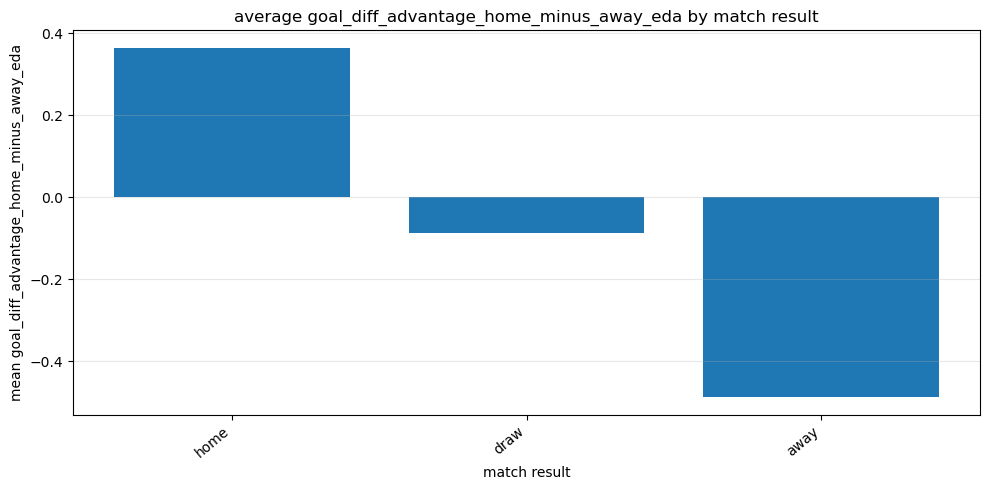

saved figure:c:\Users\mojta_tok6stl\OneDrive\Desktop\learning_ai\Football_Match_Prediction\reports\phase_2_eda\figures\11_rating_advantage_home_minus_away_eda_by_match_reuslt.png


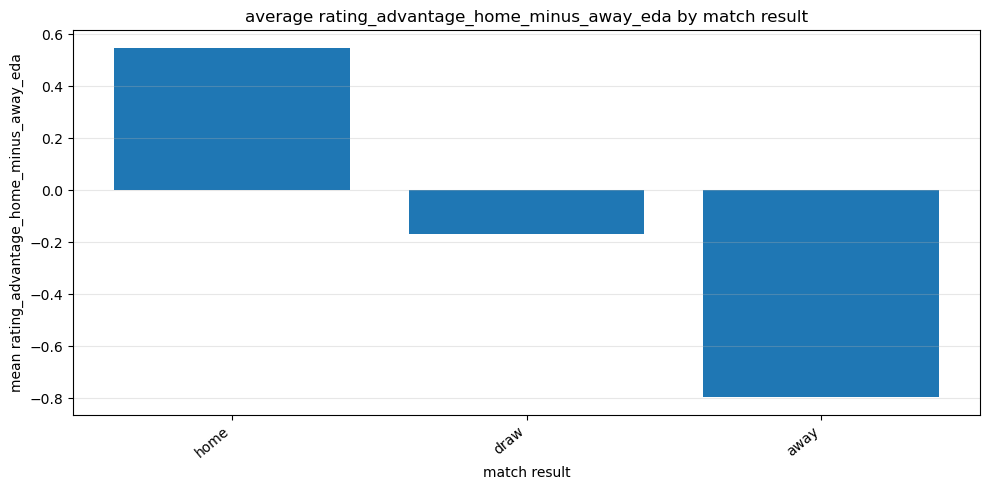

saved figure:c:\Users\mojta_tok6stl\OneDrive\Desktop\learning_ai\Football_Match_Prediction\reports\phase_2_eda\figures\11_home_goal_diff_last5_eda_by_match_reuslt.png


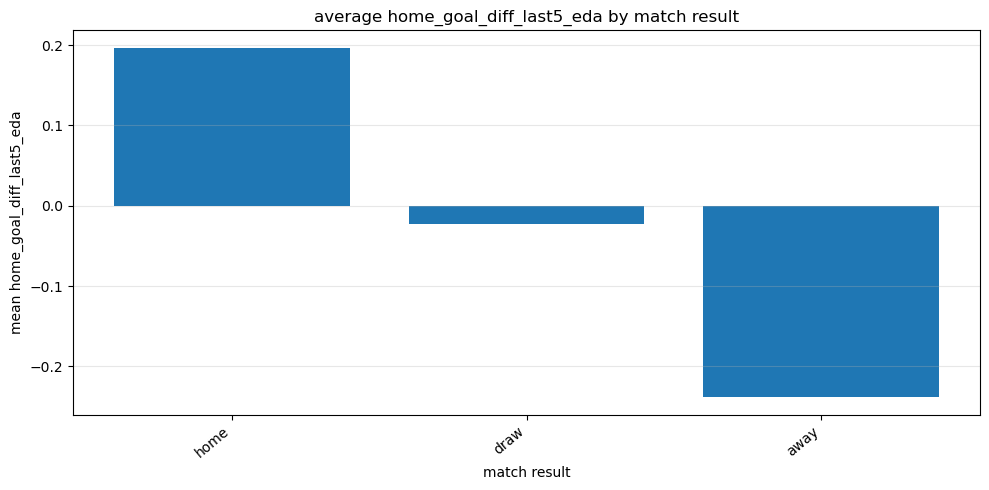

saved figure:c:\Users\mojta_tok6stl\OneDrive\Desktop\learning_ai\Football_Match_Prediction\reports\phase_2_eda\figures\11_away_goal_diff_last5_eda_by_match_reuslt.png


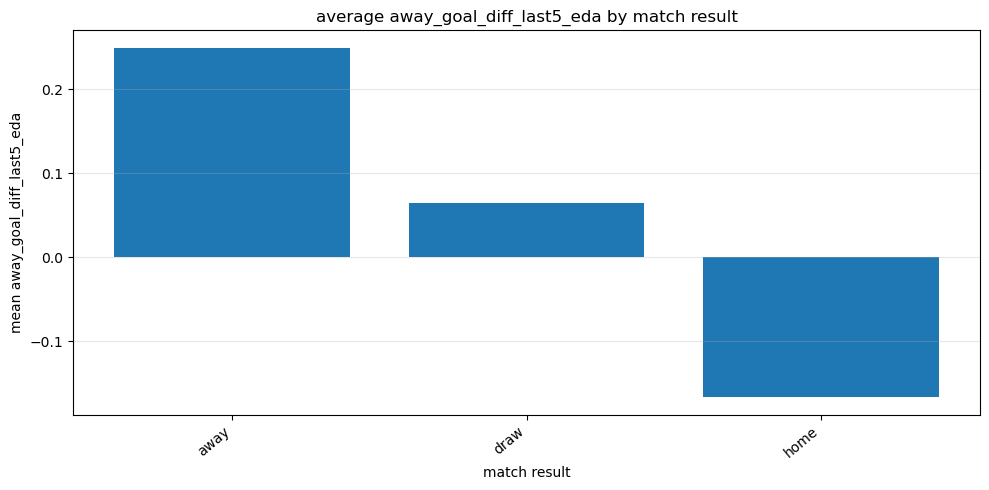

saved figure:c:\Users\mojta_tok6stl\OneDrive\Desktop\learning_ai\Football_Match_Prediction\reports\phase_2_eda\figures\11_home_avg_goals_scored_last5_eda_by_match_reuslt.png


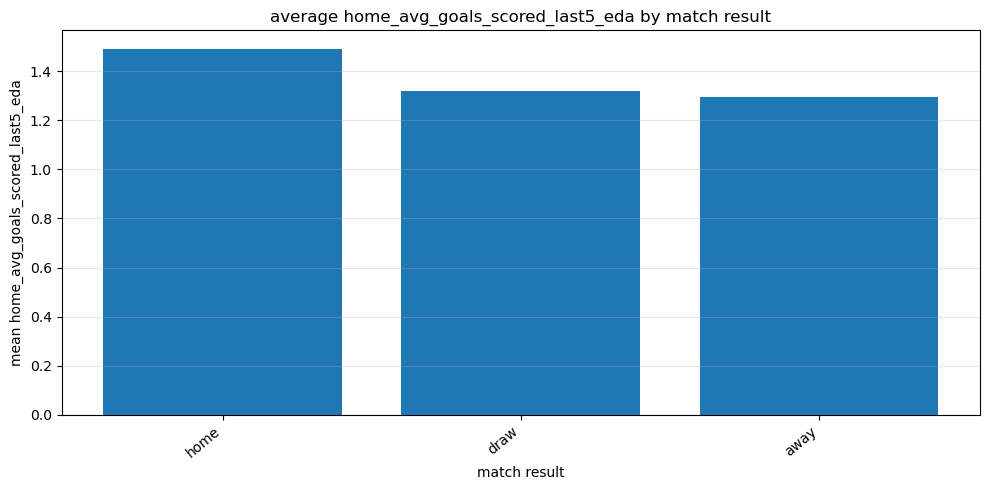

saved figure:c:\Users\mojta_tok6stl\OneDrive\Desktop\learning_ai\Football_Match_Prediction\reports\phase_2_eda\figures\11_away_avg_goals_scored_last5_eda_by_match_reuslt.png


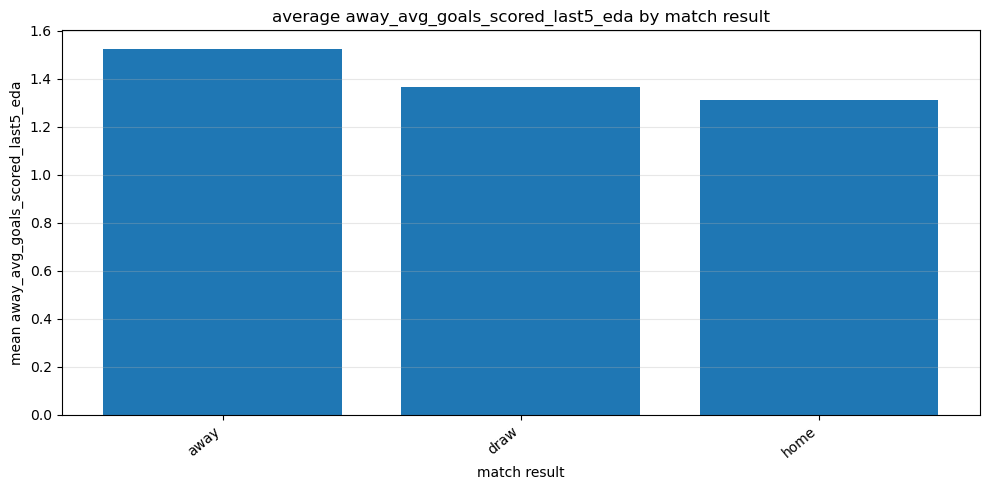

saved figure:c:\Users\mojta_tok6stl\OneDrive\Desktop\learning_ai\Football_Match_Prediction\reports\phase_2_eda\figures\11_home_avg_goals_conceded_last5_eda_by_match_reuslt.png


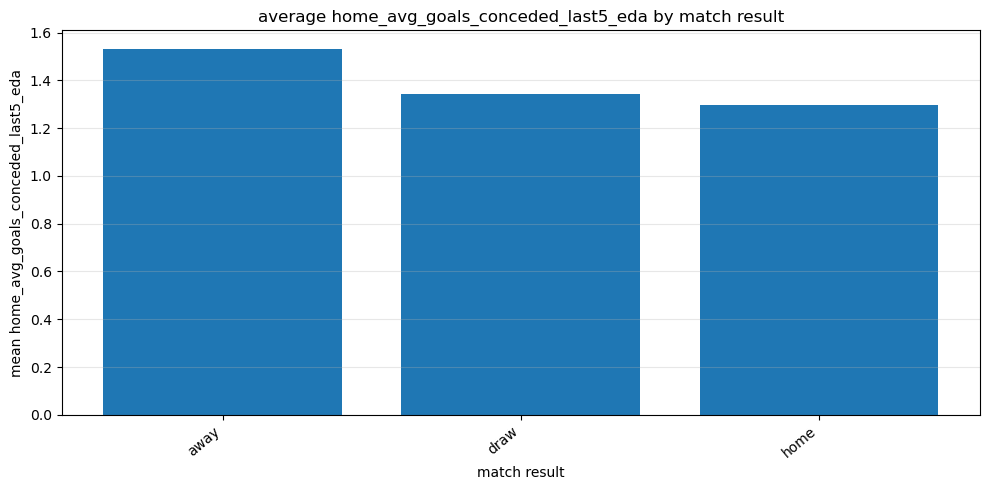

saved figure:c:\Users\mojta_tok6stl\OneDrive\Desktop\learning_ai\Football_Match_Prediction\reports\phase_2_eda\figures\11_away_avg_goals_conceded_last5_eda_by_match_reuslt.png


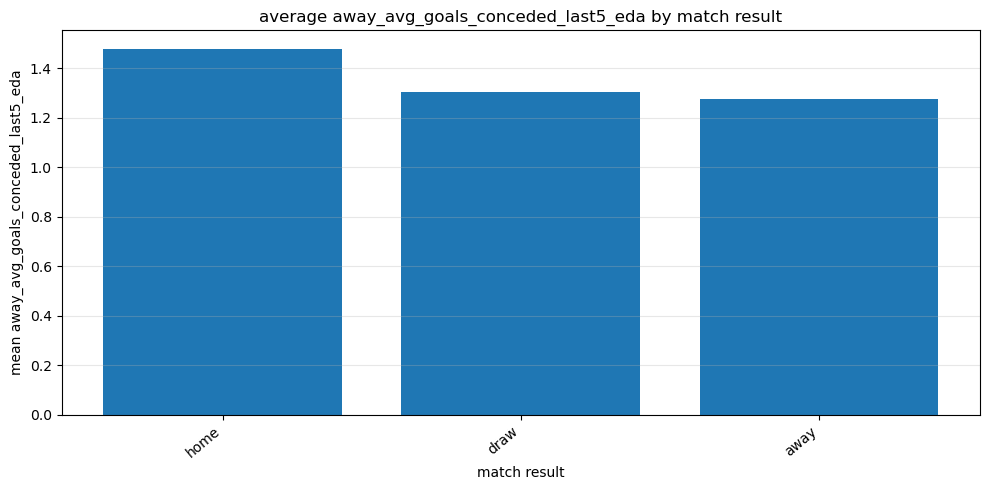

In [34]:

form_target_summary_rows = []

for feature in eda_form_features:
    if feature  not in eda_df.columns:
        continue
    
    feature_summary = (
        eda_df
        .groupby(TARGET_COL,dropna=False)[feature]
        .agg(
            count = 'count',
            missing_count = lambda x: int(x.isna().sum()),
            mean='mean',
            median = 'median',
            std = 'std',
            min = 'min',
            max = 'max'
        ).reset_index()
    )
    
    feature_summary.insert(0,'feature',feature)
    form_target_summary_rows.append(feature_summary)
    
if form_target_summary_rows:
    form_target_summary = pd.concat(form_target_summary_rows,ignore_index=True)
    
    display(form_target_summary)
    
    safe_save_csv(
        form_target_summary,
        'form_features_by_target_summary.csv',
        index=False
    )
    
    
    selected_form_features_to_plot = [
        'goal_diff_advantage_home_minus_away_eda',
        'rating_advantage_home_minus_away_eda',
        'recent_opponent_strnght_diff_home_minus_away_eda',
        'home_goal_diff_last5_eda',
        'away_goal_diff_last5_eda',
        'home_avg_goals_scored_last5_eda',
        'away_avg_goals_scored_last5_eda',
        "home_avg_goals_conceded_last5_eda",
        "away_avg_goals_conceded_last5_eda"
    ]
    
    
    for feature in selected_form_features_to_plot:
        if feature not in eda_df.columns:
            continue
        
        target_means = (
            eda_df
            .groupby(TARGET_COL,dropna=False)[feature]
            .mean()
            .sort_values(ascending=False)
        )
        
        
        if target_means.notna().sum() <2 :
            print(f'skipped plot for {feature}: not enough valid target means')
            continue
        
        
        plot_bar(
            target_means,
            title=f'average {feature} by match result',
            xlabel='match result',
            ylabel=f'mean {feature}',
            filename=f'11_{feature}_by_match_reuslt.png',
            rotation=40
        )
        
        
else:
    print('no form features were available for target-level summary')

saved figure:c:\Users\mojta_tok6stl\OneDrive\Desktop\learning_ai\Football_Match_Prediction\reports\phase_2_eda\figures\12_home_club_recent_played_at_home_rate_by_lag.png


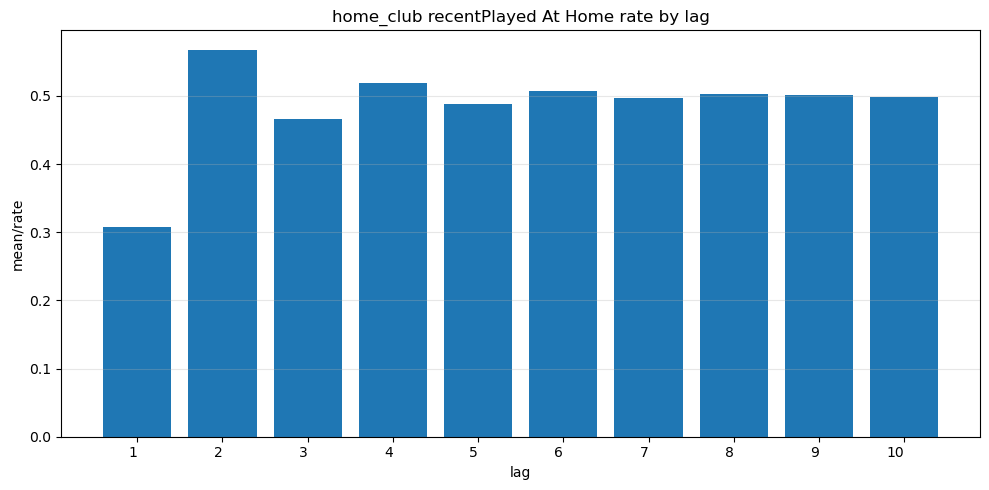

saved figure:c:\Users\mojta_tok6stl\OneDrive\Desktop\learning_ai\Football_Match_Prediction\reports\phase_2_eda\figures\12_home_club_recent_cup_game_rate_by_lag.png


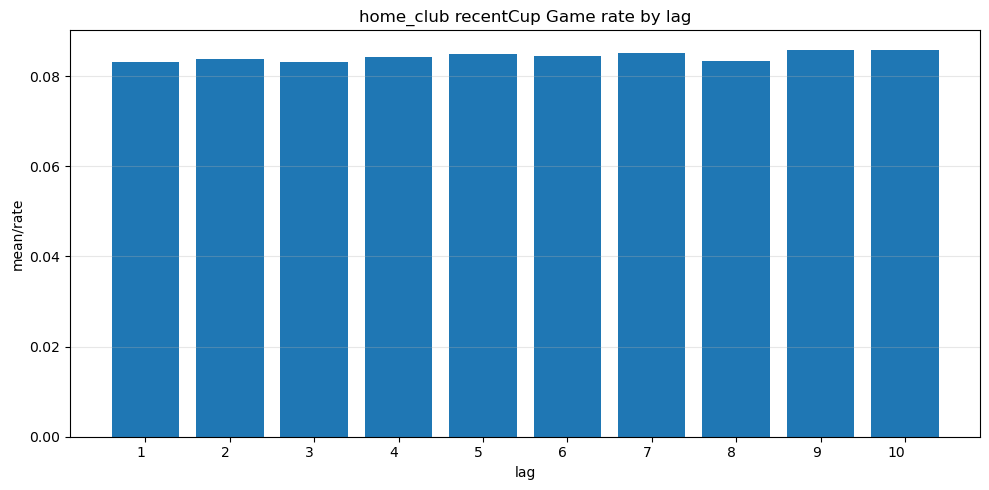

saved figure:c:\Users\mojta_tok6stl\OneDrive\Desktop\learning_ai\Football_Match_Prediction\reports\phase_2_eda\figures\12_away_club_recent_played_at_home_rate_by_lag.png


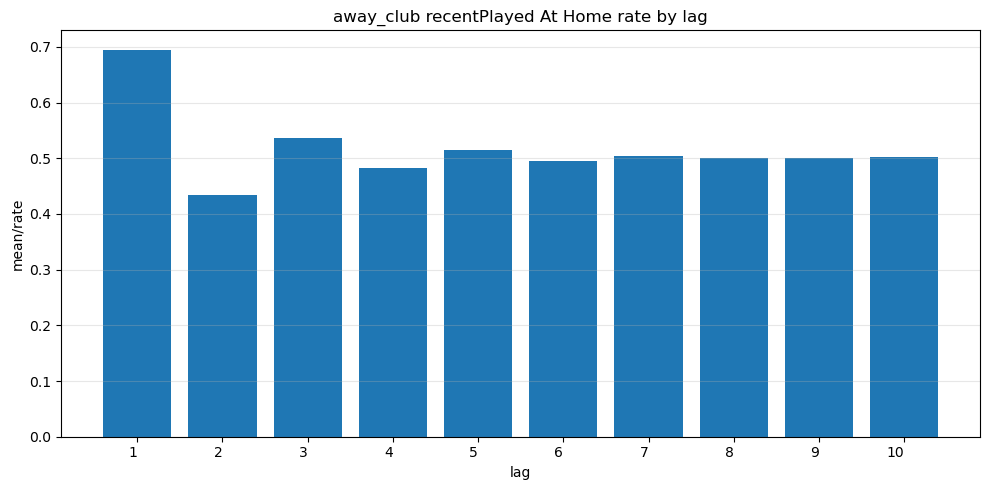

saved figure:c:\Users\mojta_tok6stl\OneDrive\Desktop\learning_ai\Football_Match_Prediction\reports\phase_2_eda\figures\12_away_club_recent_cup_game_rate_by_lag.png


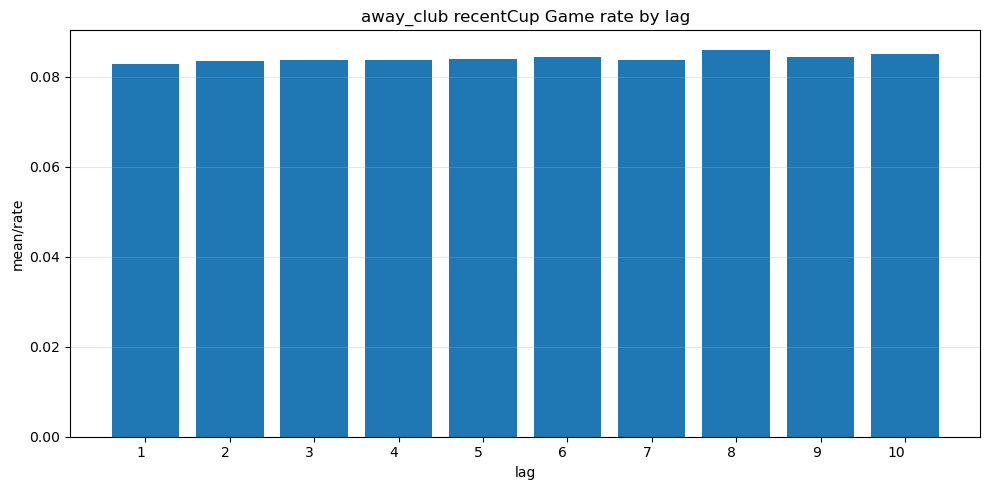

[{'side': 'home_club',
  'feature': 'played_at_home',
  'available_lags': 10,
  'new_eda_feature': 'home_recent_played_at_home_rate_last10_eda',
  'created': True,
  'overall_mean': 0.4846018668729396,
  'overall_missing_percentage': 6.54,
  'min_value': 0.0,
  'max_value': 1.0,
  'invalid_binary_value_count': 0,
  'reason': None},
 {'side': 'home_club',
  'feature': 'cup_game',
  'available_lags': 10,
  'new_eda_feature': 'home_recent_cup_game_rate_last10_eda',
  'created': True,
  'overall_mean': 0.08438733648115179,
  'overall_missing_percentage': 6.84,
  'min_value': 0.0,
  'max_value': 1.0,
  'invalid_binary_value_count': 0,
  'reason': None},
 {'side': 'away_club',
  'feature': 'played_at_home',
  'available_lags': 10,
  'new_eda_feature': 'away_recent_played_at_home_rate_last10_eda',
  'created': True,
  'overall_mean': 0.5176314476800217,
  'overall_missing_percentage': 6.93,
  'min_value': 0.0,
  'max_value': 1.0,
  'invalid_binary_value_count': 0,
  'reason': None},
 {'side':

Saved: c:\Users\mojta_tok6stl\OneDrive\Desktop\learning_ai\Football_Match_Prediction\reports\phase_2_eda\recent_context_summary.csv
saved figure:c:\Users\mojta_tok6stl\OneDrive\Desktop\learning_ai\Football_Match_Prediction\reports\phase_2_eda\figures\13_home_recent_played_at_home_rate_last10_eda_by_match_result.png


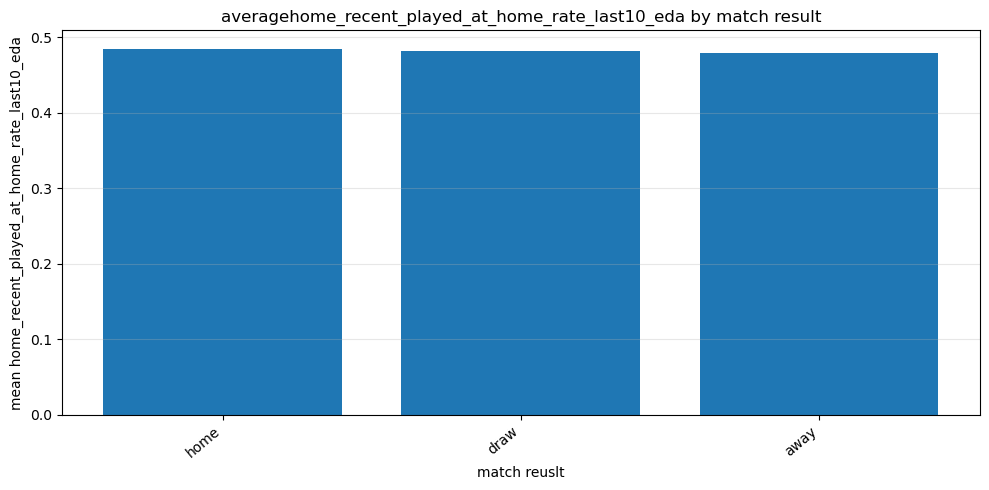

saved figure:c:\Users\mojta_tok6stl\OneDrive\Desktop\learning_ai\Football_Match_Prediction\reports\phase_2_eda\figures\13_home_recent_cup_game_rate_last10_eda_by_match_result.png


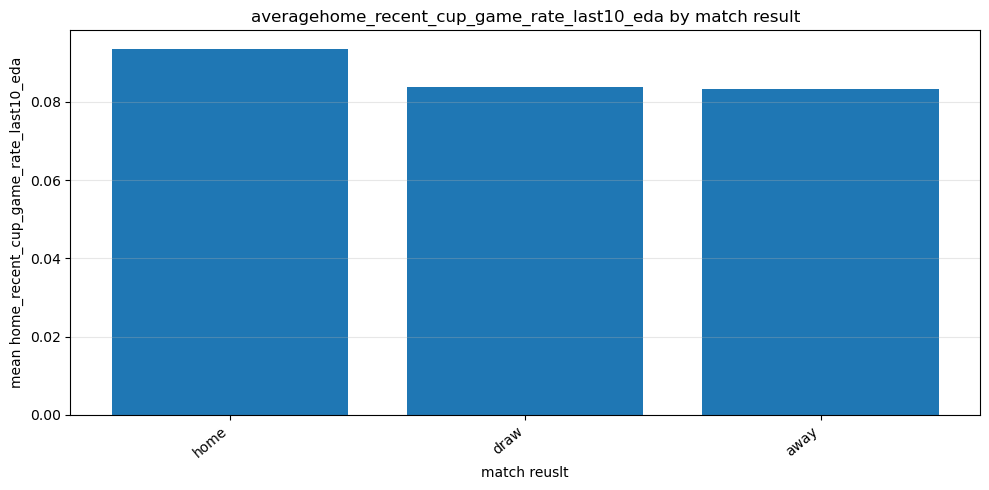

saved figure:c:\Users\mojta_tok6stl\OneDrive\Desktop\learning_ai\Football_Match_Prediction\reports\phase_2_eda\figures\13_away_recent_played_at_home_rate_last10_eda_by_match_result.png


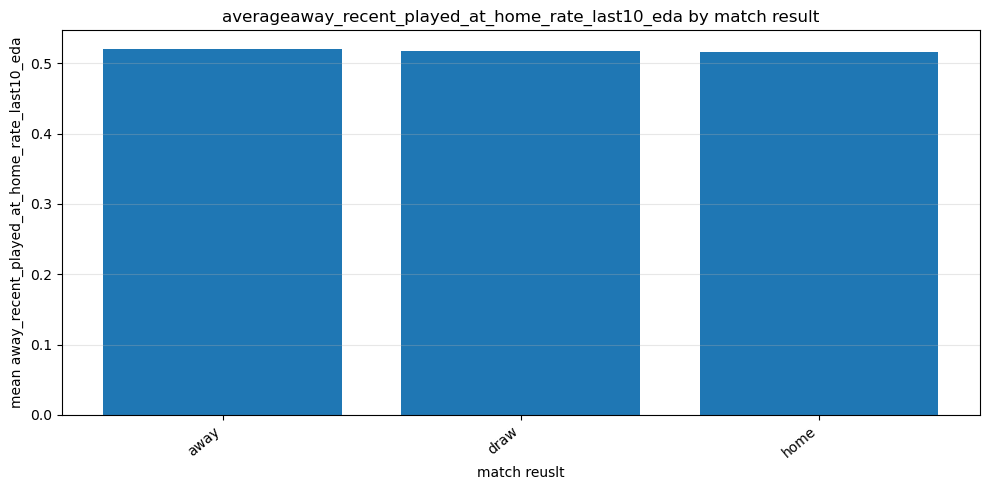

saved figure:c:\Users\mojta_tok6stl\OneDrive\Desktop\learning_ai\Football_Match_Prediction\reports\phase_2_eda\figures\13_away_recent_cup_game_rate_last10_eda_by_match_result.png


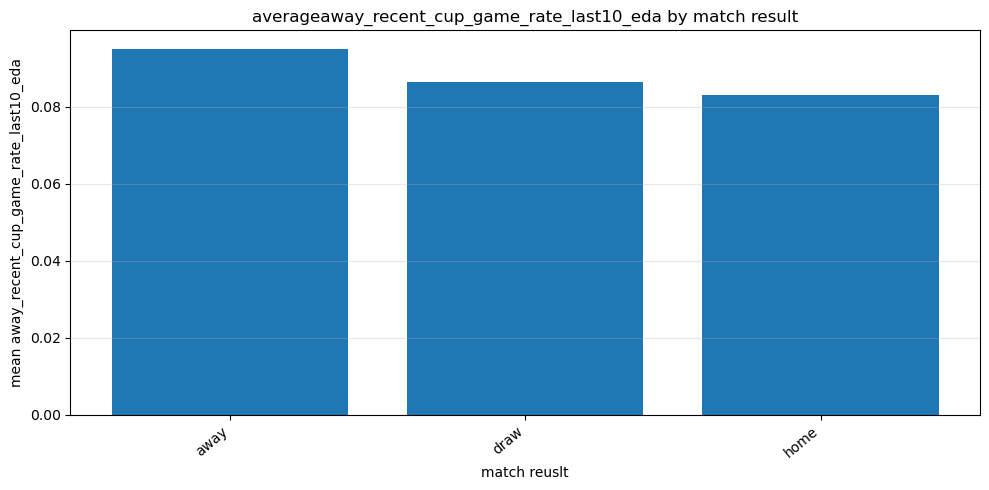

In [35]:
RECENT_CONTEX_FEATURES = ['played_at_home','cup_game']
CONTEXT_LAGS = range(1,11)


recent_context_rows = []
recent_context_eda_features = []


for side,prefix in RECENT_SIDES.items():
    for feature in RECENT_CONTEX_FEATURES:
        cols = get_recent_columns(
            side = side,
            feature=feature,
            numbers = CONTEXT_LAGS,
            dataframe=eda_df
        )
        
        
        if len(cols) == 0:
            recent_context_rows.append({
                'side': side,
                'feature': feature,
                'available_lags': 0,
                'new_eda_feature': None,
                'created': False,
                'reason': 'no matching columns found'
            })
            
            continue
        
        numeric_part = eda_df[cols].apply(pd.to_numeric,errors='coerce')
        
        
        new_col = f'{prefix}_recent_{feature}_rate_last10_eda'
        eda_df[new_col] = numeric_part.mean(axis=1)
        
        recent_context_eda_features.append(new_col)
        
        stacked_values = numeric_part.stack(dropna=True)
        
        
        invalid_binary_count = int(
            (~stacked_values.isin([0,1])).sum()
        ) if len(stacked_values)> 0 else 0
        
        
        
        recent_context_rows.append({
            'side': side,
            'feature': feature,
            'available_lags': len(cols),
            'new_eda_feature': new_col,
            'created': True,
            'overall_mean': stacked_values.mean() if len(stacked_values)> 0 else np.nan,
            'overall_missing_percentage': round(numeric_part.isna().mean().mean()*100,2),
            'min_value': stacked_values.min() if len(stacked_values) > 0 else np.nan,
            'max_value': stacked_values.max() if len(stacked_values)>0 else np.nan,
            'invalid_binary_value_count': invalid_binary_count,
            'reason': None
        })
        
        lag_means= numeric_part.mean(axis=0)
        lag_means.index = [int(col.rsplit('_',1)[-1]) for col in lag_means.index]
        lag_means = lag_means.sort_index()
        
        
        plot_bar(
            lag_means,
            title=f'{side} recent{feature.replace('_',' ').title()} rate by lag',
            xlabel='lag',
            ylabel='mean/rate',
            filename=f'12_{side}_recent_{feature}_rate_by_lag.png',
            rotation=0
        )
        
        
recent_context_summary = pd.DataFrame(recent_context_rows)

display(recent_context_rows)

safe_save_csv(
    recent_context_summary,'recent_context_summary.csv',index=False
)



for feature in recent_context_eda_features:
    if feature not in eda_df.columns:
        continue
    
    target_means = (
        eda_df
        .groupby(TARGET_COL,dropna=False)[feature]
        .mean()
        .sort_values(ascending=False)
    )
    
    if target_means.notna().sum() < 2:
        print(f'skipped plot for {feature}: not enough valid target means')
        continue
    
    plot_bar(
        target_means,
        title=f'average{feature} by match result',
        xlabel= 'match reuslt',
        ylabel= f'mean {feature}',
        filename = f'13_{feature}_by_match_result.png',
        rotation=40
    )

,column,exists,unique_manager,missing_count,missing_percentage,most_frequent_manager_count,most_frequent_manager_percentage
0,home_manager_id,True,8804,21721,19.58,4455,4.99
1,away_manager_id,True,8938,21815,19.66,4512,5.06


Saved: c:\Users\mojta_tok6stl\OneDrive\Desktop\learning_ai\Football_Match_Prediction\reports\phase_2_eda\manager_summary.csv


,new_feature,created,reason,current_col,previous_col,non_null_count,missing_percentage,change_rate_percentage
0,home_manager_changed_from_last_match_eda,True,None,home_manager_id,home_club_recent_manager_id_1,87810,20.85,3.28
1,away_manager_changed_from_last_match_eda,True,None,away_manager_id,away_club_recent_manager_id_1,87695,20.95,3.40


Saved: c:\Users\mojta_tok6stl\OneDrive\Desktop\learning_ai\Football_Match_Prediction\reports\phase_2_eda\manager_change_feature_creation_summary.csv

Feature: home_manager_changed_from_last_match_eda


,count,percentage
home_manager_changed_from_last_match_eda,,
0.0,84933,76.56
NaN,23128,20.85
1.0,2877,2.59


Saved: c:\Users\mojta_tok6stl\OneDrive\Desktop\learning_ai\Football_Match_Prediction\reports\phase_2_eda\home_manager_changed_from_last_match_eda_distribution.csv


match_result,away,draw,home
home_manager_changed_from_last_match_eda,,,
0.0,30.86,25.28,43.85
1.0,33.61,27.22,39.17
NaN,34.56,23.32,42.12


Saved: c:\Users\mojta_tok6stl\OneDrive\Desktop\learning_ai\Football_Match_Prediction\reports\phase_2_eda\home_manager_changed_from_last_match_eda_target_distribution.csv
saved figure:c:\Users\mojta_tok6stl\OneDrive\Desktop\learning_ai\Football_Match_Prediction\reports\phase_2_eda\figures\14_home_manager_changed_from_last_match_eda_target_distribution.png


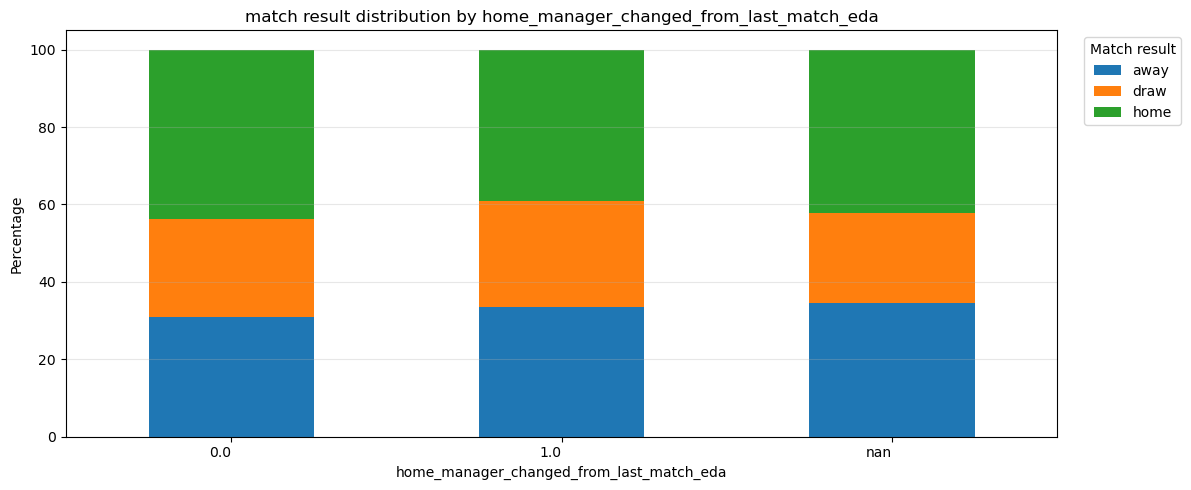


Feature: away_manager_changed_from_last_match_eda


,count,percentage
away_manager_changed_from_last_match_eda,,
0.0,84715,76.36
NaN,23243,20.95
1.0,2980,2.69


Saved: c:\Users\mojta_tok6stl\OneDrive\Desktop\learning_ai\Football_Match_Prediction\reports\phase_2_eda\away_manager_changed_from_last_match_eda_distribution.csv


match_result,away,draw,home
away_manager_changed_from_last_match_eda,,,
0.0,32.33,25.48,42.19
1.0,28.96,24.73,46.31
NaN,29.79,22.92,47.29


Saved: c:\Users\mojta_tok6stl\OneDrive\Desktop\learning_ai\Football_Match_Prediction\reports\phase_2_eda\away_manager_changed_from_last_match_eda_target_distribution.csv
saved figure:c:\Users\mojta_tok6stl\OneDrive\Desktop\learning_ai\Football_Match_Prediction\reports\phase_2_eda\figures\14_away_manager_changed_from_last_match_eda_target_distribution.png


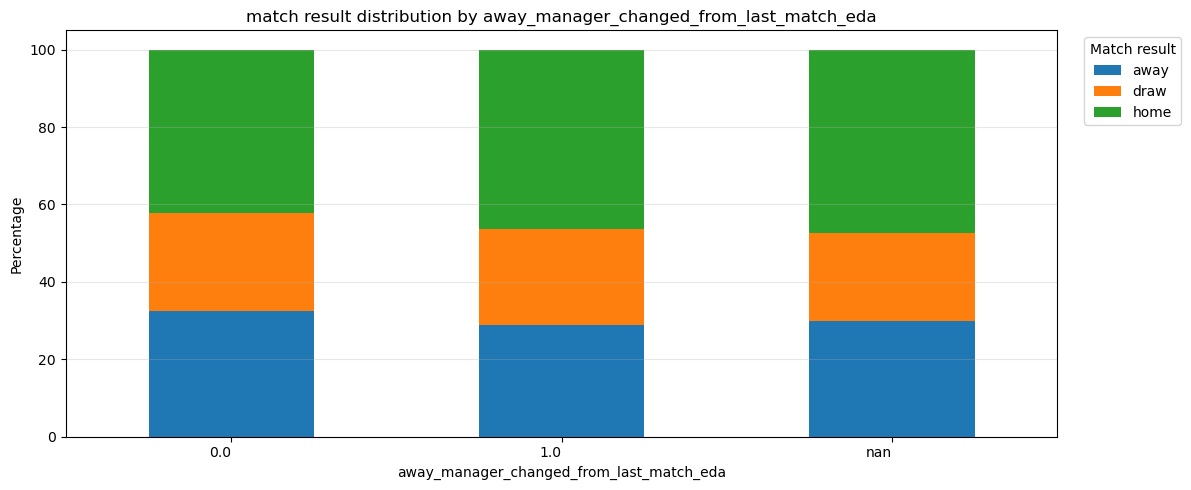

In [36]:
MANAGER_COLUMNS = ['home_manager_id', 'away_manager_id']

manager_summary_rows = []

for col in MANAGER_COLUMNS:
    if col not in eda_df.columns:
        manager_summary_rows.append({
            'column': col,
            'exists': False,
            'unique_manager': np.nan,
            'missing_count': np.nan,
            'missing_percentage': np.nan,
            'most_frequent_manager_count': np.nan,
            'most_frequent_manager_percentage': np.nan
        })

        continue

    value_counts = eda_df[col].value_counts(dropna=True)

    most_frequent_count = int(value_counts.iloc[0]) if len(value_counts) > 0 else 0

    non_missing_count = eda_df[col].notna().sum()

    most_frequent_percentage = (
        most_frequent_count / non_missing_count * 100
        if non_missing_count > 0
        else np.nan
    )

    manager_summary_rows.append({
        'column': col,
        'exists': True,
        'unique_manager': int(eda_df[col].nunique(dropna=True)),
        'missing_count': int(eda_df[col].isna().sum()),
        'missing_percentage': round(eda_df[col].isna().mean() * 100, 2),
        'most_frequent_manager_count': most_frequent_count,
        'most_frequent_manager_percentage': round(most_frequent_percentage, 2)
    })


manager_summary = pd.DataFrame(manager_summary_rows)

display(manager_summary)

safe_save_csv(
    manager_summary,
    'manager_summary.csv',
    index=False
)


def clean_id_for_comparison(series):
    cleaned = series.astype('string').str.strip()

    cleaned = cleaned.replace(
        {
            '': pd.NA,
            'nan': pd.NA,
            'NaN': pd.NA,
            'None': pd.NA,
            'none': pd.NA,
            '<NA>': pd.NA
        }
    )

    numeric_version = pd.to_numeric(cleaned, errors='coerce')
    numeric_success_rate = numeric_version.notna().mean()

    if numeric_success_rate >= 0.90:
        cleaned = numeric_version.round(0).astype('Int64').astype('string')

    return cleaned


manager_changed_specs = [
    {
        'current_col': 'home_manager_id',
        'previous_col': 'home_club_recent_manager_id_1',
        'new_col': 'home_manager_changed_from_last_match_eda'
    },
    {
        'current_col': 'away_manager_id',
        'previous_col': 'away_club_recent_manager_id_1',
        'new_col': 'away_manager_changed_from_last_match_eda'
    }
]


manager_change_features = []
manager_change_creation_rows = []


for spec in manager_changed_specs:
    current_col = spec['current_col']
    previous_col = spec['previous_col']
    new_col = spec['new_col']

    if current_col not in eda_df.columns or previous_col not in eda_df.columns:
        manager_change_creation_rows.append({
            'new_feature': new_col,
            'created': False,
            'reason': 'current or previous manager column is missing',
            'current_col': current_col,
            'previous_col': previous_col
        })

        continue

    current_values = clean_id_for_comparison(eda_df[current_col])
    previous_values = clean_id_for_comparison(eda_df[previous_col])

    missing_mask = current_values.isna() | previous_values.isna()

    comparison = current_values.ne(previous_values).fillna(False).astype(int)

    eda_df[new_col] = comparison.astype(float)
    eda_df.loc[missing_mask, new_col] = np.nan

    manager_change_features.append(new_col)

    manager_change_creation_rows.append({
        'new_feature': new_col,
        'created': True,
        'reason': None,
        'current_col': current_col,
        'previous_col': previous_col,
        'non_null_count': int(eda_df[new_col].notna().sum()),
        'missing_percentage': round(eda_df[new_col].isna().mean() * 100, 2),
        'change_rate_percentage': round(eda_df[new_col].mean() * 100, 2)
    })


manager_change_creation_summary = pd.DataFrame(manager_change_creation_rows)

display(manager_change_creation_summary)

safe_save_csv(
    manager_change_creation_summary,
    'manager_change_feature_creation_summary.csv',
    index=False
)


if manager_change_features:
    for feature in manager_change_features:
        print('\nFeature:', feature)

        feature_counts = eda_df[feature].value_counts(dropna=False)
        feature_percentages = (
            eda_df[feature]
            .value_counts(normalize=True, dropna=False)
            .mul(100)
            .round(2)
        )

        feature_dist = pd.DataFrame({
            'count': feature_counts,
            'percentage': feature_percentages
        })

        display(feature_dist)

        feature_dist_export = feature_dist.reset_index()
        feature_dist_export.columns = [feature, 'count', 'percentage']

        safe_save_csv(
            feature_dist_export,
            f'{feature}_distribution.csv',
            index=False
        )

        manager_target_table = (
            pd.crosstab(
                eda_df[feature],
                eda_df[TARGET_COL],
                normalize='index',
                dropna=False
            )
            .mul(100)
            .round(2)
        )

        display(manager_target_table)

        safe_save_csv(
            manager_target_table.reset_index(),
            f'{feature}_target_distribution.csv',
            index=False
        )

        if manager_target_table.shape[0] > 0 and manager_target_table.shape[1] > 1:
            plot_stacked_percentage(
                manager_target_table,
                title=f'match result distribution by {feature}',
                xlabel=feature,
                filename=f'14_{feature}_target_distribution.png',
                rotation=0
            )
        else:
            print(f'skipped stacked plot for {feature}: not enough categories')

else:
    print('manager change feature could not be created')

number of usable numeric eda features for correlation : 19


,home_avg_goals_scored_last5_eda,home_avg_goals_conceded_last5_eda,home_avg_team_rating_last5_eda,home_avg_opponent_rating_last5_eda,away_avg_goals_scored_last5_eda,away_avg_goals_conceded_last5_eda,away_avg_team_rating_last5_eda,away_avg_opponent_rating_last5_eda,home_goal_diff_last5_eda,away_goal_diff_last5_eda,goal_diff_advantage_home_minus_away_eda,rating_advantage_home_minus_away_eda,recent_opponent_strength_diff_home_minus_away_eda,home_recent_played_at_home_rate_last10_eda,home_recent_cup_game_rate_last10_eda,away_recent_played_at_home_rate_last10_eda,away_recent_cup_game_rate_last10_eda,home_manager_changed_from_last_match_eda,away_manager_changed_from_last_match_eda
home_avg_goals_scored_last5_eda,1.000000,-0.123916,0.593696,-0.164586,0.144311,0.081579,0.216973,0.136216,0.746279,0.040640,0.513700,0.340774,-0.275119,0.085368,0.070053,0.003983,0.028611,-0.044290,-0.002845
home_avg_goals_conceded_last5_eda,-0.123916,1.000000,-0.168948,0.586162,0.079946,0.139490,0.125295,0.220020,-0.752979,-0.040869,-0.517399,-0.265039,0.329243,-0.070342,-0.027777,0.014563,-0.007910,0.034055,-0.009303
home_avg_team_rating_last5_eda,0.593696,-0.168948,1.000000,-0.150010,0.216517,0.132115,0.379531,0.284133,0.507044,0.054442,0.330471,0.559507,-0.398668,0.107728,0.112765,0.001028,0.048549,-0.034327,-0.010046
home_avg_opponent_rating_last5_eda,-0.164586,0.586162,-0.150010,1.000000,0.129792,0.222074,0.275611,0.402169,-0.502346,-0.063402,-0.319016,-0.382602,0.537373,-0.104893,-0.011912,0.011161,-0.002192,0.011142,-0.013979
away_avg_goals_scored_last5_eda,0.144311,0.079946,0.216517,0.129792,1.000000,-0.123989,0.588147,-0.164494,0.042250,0.744497,-0.510977,-0.334458,0.269048,0.005323,0.028523,0.073683,0.065944,-0.011904,-0.048307
away_avg_goals_conceded_last5_eda,0.081579,0.139490,0.132115,0.222074,-0.123989,1.000000,-0.170334,0.590517,-0.039297,-0.754784,0.519860,0.273635,-0.342129,0.004167,-0.005945,-0.061569,-0.021692,-0.006996,0.039451
away_avg_team_rating_last5_eda,0.216973,0.125295,0.379531,0.275611,0.588147,-0.170334,1.000000,-0.148337,0.060110,0.503413,-0.324866,-0.554462,0.388278,0.002841,0.048186,0.097976,0.103963,-0.013593,-0.043485
away_avg_opponent_rating_last5_eda,0.136216,0.220020,0.284133,0.402169,-0.164494,0.590517,-0.148337,1.000000,-0.056977,-0.506053,0.325994,0.389866,-0.556022,0.005961,0.001797,-0.086628,-0.001294,-0.008409,0.023657
home_goal_diff_last5_eda,0.746279,-0.752979,0.507044,-0.502346,0.042250,-0.039297,0.060110,-0.056977,1.000000,0.054367,0.687745,0.403842,-0.403268,0.103799,0.065112,-0.007113,0.024299,-0.052176,0.004254
away_goal_diff_last5_eda,0.040640,-0.040869,0.054442,-0.063402,0.744497,-0.754784,0.503413,-0.506053,0.054367,1.000000,-0.687488,-0.405201,0.407966,0.000720,0.022866,0.090134,0.058196,-0.003333,-0.058467


Saved: c:\Users\mojta_tok6stl\OneDrive\Desktop\learning_ai\Football_Match_Prediction\reports\phase_2_eda\temporary_eda_features_correlation.csv
saved figure:c:\Users\mojta_tok6stl\OneDrive\Desktop\learning_ai\Football_Match_Prediction\reports\phase_2_eda\figures\15_temporary_eda_features_correlation.png


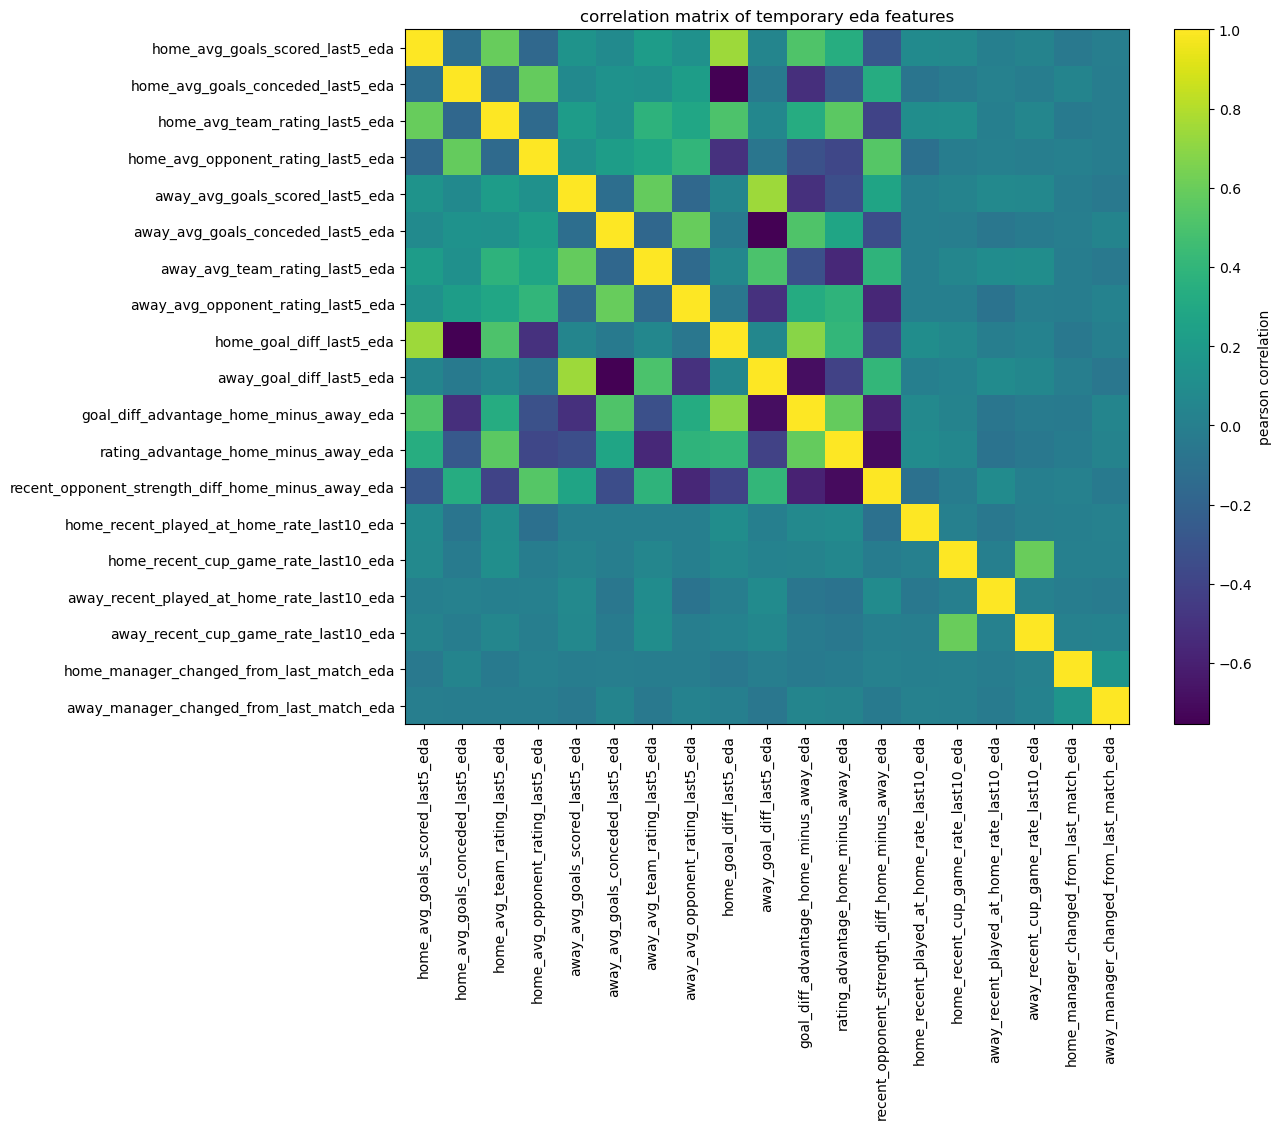

In [37]:
import matplotlib.pyplot as plt

candidate_numeric_eda_features = (
    eda_form_features + recent_context_eda_features + manager_change_features
)


numeric_eda_features = []


for col in candidate_numeric_eda_features:
    if col not in eda_df.columns:
        continue
    
    converted_col = pd.to_numeric(eda_df[col],errors='coerce')
    
    if converted_col.notna().sum() == 0:
        continue
    
    if converted_col.nunique(dropna=True)< 2:
        continue
    
    eda_df[col] = converted_col
    numeric_eda_features.append(col)
    
numeric_eda_features = list(dict.fromkeys(numeric_eda_features))

print(f'number of usable numeric eda features for correlation : {len(numeric_eda_features)}')

if len(numeric_eda_features) >= 2:
    corr_matrix =  eda_df[numeric_eda_features].corr(method='pearson',min_periods=10)
    
    display(corr_matrix)
    
    
    safe_save_csv(
        corr_matrix,
        'temporary_eda_features_correlation.csv', index=True
    )
    
    plt.figure(figsize=(max(10,len(corr_matrix.columns)*0.7),max(8,len(corr_matrix.index)*0.6)))
    plt.imshow(corr_matrix,aspect='auto')
    plt.colorbar(label='pearson correlation')
    
    plt.xticks(
        ticks=range(len(corr_matrix.columns)),
        labels=corr_matrix.columns,
        rotation =90
    )
    plt.yticks(
        ticks=range(len(corr_matrix.index)),
        labels=corr_matrix.index
    )
    
    plt.title('correlation matrix of temporary eda features')
    plt.tight_layout()
    
    save_current_figure('15_temporary_eda_features_correlation.png')
    plt.show()

else:
    print('not enough usable numeric eda features for correlation analysis')

In [38]:
eda_decision_note_rows = []

eda_decision_note_rows.append({
    'area': 'target',
    'finding': 'target distribution and majority-class baseline were analyzed',
    'next_phase_action': 'use stratified evaluation when possible and compare all models against the majority-class baseline',
    'priority': 'high'
})


if 'fixture_date' in eda_df.columns:
    eda_decision_note_rows.append({
        'area': 'fixture_date',
        'finding': 'fixture date availability are parsing quality were analyzed',
        'next_phase_action': 'use fixture_date for temporal features and prefer time-aware split as the main evalutation strategy',
        'priority': 'high'
    })
    
if (
    'recent_columns_info_eda' in  globals()
    and isinstance(recent_columns_info_eda,pd.DataFrame)
    and not recent_columns_info_eda.empty
):
    eda_decision_note_rows.append({
        'area': 'recent_history',
        'finding': f'{len(recent_columns_info_eda)} recent-history columns were detected',
        'next_phase_action': 'use recent-history columns to create form , rating goal-diffrence , opponent-strength and context features',
        'priority': 'high'
    })
    
    
    
if (
    'recent_date_leakage_check'in  globals() 
    and isinstance(recent_date_leakage_check,pd.DataFrame)
    and not recent_date_leakage_check.empty
    and 'violations_recent_date_not_before_current' in recent_date_leakage_check.columns
):
    total_date_violations = int(
        pd.to_numeric(
            recent_date_leakage_check['violations_recent_date_not_before_current'],
            errors='coerce'
        ).fillna(0).sum()
    )
    
    
    leakage_priority = 'high' if total_date_violations > 0 else 'medium'
    
    eda_decision_note_rows.append({
        'area': 'date_leakage',
        'finding': f'recent fixture date leakage violations found :{total_date_violations}',
        'next_phase_action': 'if violations exist, investigate affected rows before modeling or  remove invalid records',
        'priority': leakage_priority
    })
    
    
 
if 'competition' in eda_df.columns:
    eda_decision_note_rows.append({
        'area': 'competition',
        'finding': 'competition frequency and target distribution by competition were analyzed',
        'next_phase_action': 'encode competiton carefully rare competitions may need grouping before modeling',
        'priority' : 'medium'
    })
    


if 'cup_game' in eda_df.columns:
    eda_decision_note_rows.append({
        'area': 'cup_game',
        'finding': 'cupgame distribution and its relationship with result were analyzed',
        'next_phase_action': 'keep cupgame as a binary context feature if missing values and enconding are acceptable',
        'priority': 'medium'
    })
    
    

if (
    'manager_change_features' in globals() and isinstance(manager_change_features,list) and len(manager_change_features)>0
):
    eda_decision_note_rows.append({
        'area': 'manager',
        'finding': 'manager availability and manager-change indicators were analyzed',
        'next_phase_action': 'recent manager-change features in the feature engineering using the same missing value logic',
        'priority': 'medium'
    })
    
    
    
if (
    'outlier_check' in globals() and isinstance(outlier_check,pd.DataFrame) and not outlier_check.empty and 'outlier_percentage' in outlier_check.columns
):
    
    high_outlier_columns = outlier_check[
        pd.to_numeric(outlier_check['outlier_percentage'],errors='coerce') > 10
    ]
    
    eda_decision_note_rows.append({
        'area': 'outliers',
        'finding': f'{len(high_outlier_columns)} recent numeric columns have more than 10% IQR based outliers',
        'next_phase_action': 'do not automatically remvoe football outliers review them and prefer rubust models or transformations if needed',
        'priority': 'medium'
    })
    

eda_decision_notes = pd.DataFrame(eda_decision_note_rows)
display(eda_decision_notes)


safe_save_csv(
    eda_decision_notes,
    'eda_decisiton_notes_for_next_phases.csv',
    index=False
)


,area,finding,next_phase_action,priority
0,target,target distribution and majority-class baseline were analyzed,use stratified evaluation when possible and compare all models against the majority-class baseline,high
1,fixture_date,fixture date availability are parsing quality were analyzed,use fixture_date for temporal features and prefer time-aware split as the main evalutation strategy,high
2,recent_history,180 recent-history columns were detected,"use recent-history columns to create form , rating goal-diffrence , opponent-strength and context features",high
3,competition,competition frequency and target distribution by competition were analyzed,encode competiton carefully rare competitions may need grouping before modeling,medium
4,cup_game,cupgame distribution and its relationship with result were analyzed,keep cupgame as a binary context feature if missing values and enconding are acceptable,medium
5,manager,manager availability and manager-change indicators were analyzed,recent manager-change features in the feature engineering using the same missing value logic,medium
6,outliers,0 recent numeric columns have more than 10% IQR based outliers,do not automatically remvoe football outliers review them and prefer rubust models or transformations if needed,medium


Saved: c:\Users\mojta_tok6stl\OneDrive\Desktop\learning_ai\Football_Match_Prediction\reports\phase_2_eda\eda_decisiton_notes_for_next_phases.csv


In [39]:
import json

PHASE_2_REPORT_DIR.mkdir(parents=True, exist_ok=True)
PHASE_2_FIGURES_DIR.mkdir(parents=True, exist_ok=True)

if TARGET_COL not in eda_df.columns:
    raise ValueError(f"Target column '{TARGET_COL}' does not exist in eda_df.")

target_distribution_final = eda_df[TARGET_COL].value_counts(dropna=True)

if len(target_distribution_final) > 0:
    majority_class = target_distribution_final.idxmax()
    majority_baseline_accuracy = target_distribution_final.max() / target_distribution_final.sum()
else:
    majority_class = None
    majority_baseline_accuracy = None

phase_2_summary = {
    "dataset_shape": {
        "rows": int(eda_df.shape[0]),
        "columns": int(eda_df.shape[1])
    },
    "target_column": TARGET_COL,
    "target_unique_count": int(eda_df[TARGET_COL].nunique(dropna=True)),
    "target_missing_count": int(eda_df[TARGET_COL].isna().sum()),
    "majority_class": str(majority_class) if majority_class is not None else None,
    "majority_baseline_accuracy": (
        float(majority_baseline_accuracy)
        if majority_baseline_accuracy is not None
        else None
    ),
    "recent_history_columns_detected": (
        int(len(recent_columns_info_eda))
        if "recent_columns_info_eda" in globals()
        else None
    ),
    "temporary_form_features_created": eda_form_features if "eda_form_features" in globals() else [],
    "recent_context_features_created": recent_context_eda_features if "recent_context_eda_features" in globals() else [],
    "manager_change_features_created": manager_change_features if "manager_change_features" in globals() else [],
    "numeric_eda_features_used_for_correlation": numeric_eda_features if "numeric_eda_features" in globals() else [],
    "report_dir": str(PHASE_2_REPORT_DIR),
    "figures_dir": str(PHASE_2_FIGURES_DIR)
}

if "fixture_date_parsed" in eda_df.columns:
    fixture_date_non_null_rate = eda_df["fixture_date_parsed"].notna().mean() * 100

    phase_2_summary["fixture_date_parse_success_percentage"] = float(fixture_date_non_null_rate)
    phase_2_summary["fixture_min_date"] = str(eda_df["fixture_date_parsed"].min())
    phase_2_summary["fixture_max_date"] = str(eda_df["fixture_date_parsed"].max())

if "competition" in eda_df.columns:
    phase_2_summary["unique_competitions"] = int(
        eda_df["competition"].nunique(dropna=True)
    )

if "home_club" in eda_df.columns and "away_club" in eda_df.columns:
    phase_2_summary["unique_clubs_combined"] = int(
        pd.concat(
            [eda_df["home_club"], eda_df["away_club"]],
            ignore_index=True
        ).nunique(dropna=True)
    )
    
    # باگ  سینتکسی زدم ولی راحت ترین راه رو بریم :)

if 'recent_date_leakage_check' in globals() and not recent_date_leakage_check.empty:
    possible_leakage_cols = [
        'violations_recent_date_not_before_current',
        'violation_recent_date_not_before_current'
    ]
    
    leakage_col = None
    
    for col in possible_leakage_cols:
        if col in recent_date_leakage_check.column:
            leakage_col = col
            break
        
    if leakage_col is not None:
        phase_2_summary['recent_date_leakage_total_violations'] = int(
            pd.to_numeric(
                recent_date_leakage_check[leakage_col],
                errors='coerce'
            ).fillna(0).sum()
        )
        
        phase_2_summary['recent_date_leakage_column_used'] = leakage_col
        
    else:
        phase_2_summary['recent_date_leakage_total_violations'] = None
        phase_2_summary['recent_date_leakage_note'] = (
            'recent_date_leakage_check exists but no expected leakage-count columns was found'
        )
        
        print('warning : no expected leakage columns was not found in recent_date_leakage_check')
        print('available columns:')
        print(recent_date_leakage_check.column.tolist())

if "outlier_check" in globals() and not outlier_check.empty:
    valid_outlier_percentages = pd.to_numeric(
        outlier_check["outlier_percentage"],
        errors="coerce"
    )

    phase_2_summary["recent_numeric_outlier_columns_checked"] = int(
        valid_outlier_percentages.notna().sum()
    )

    phase_2_summary["recent_numeric_columns_with_outlier_percentage_above_10"] = int(
        (valid_outlier_percentages > 10).sum()
    )

summary_path = PHASE_2_REPORT_DIR / "phase_2_summary.json"

with open(summary_path, "w", encoding="utf-8") as f:
    json.dump(
        phase_2_summary,
        f,
        indent=4,
        ensure_ascii=False,
        default=str
    )

print("Phase 2 summary saved to:", summary_path)
print(json.dumps(phase_2_summary, indent=4, ensure_ascii=False, default=str))

print("-" * 80)
print("PHASE 2 COMPLETED SUCCESSFULLY")
print("-" * 80)

available columns:
['home_club_recent_fixture_date_1', 'home_club_recent_fixture_date_2', 'home_club_recent_fixture_date_3', 'home_club_recent_fixture_date_4', 'home_club_recent_fixture_date_5', 'home_club_recent_fixture_date_6', 'home_club_recent_fixture_date_7', 'home_club_recent_fixture_date_8', 'home_club_recent_fixture_date_9', 'home_club_recent_fixture_date_10', 'away_club_recent_fixture_date_1', 'away_club_recent_fixture_date_2', 'away_club_recent_fixture_date_3', 'away_club_recent_fixture_date_4', 'away_club_recent_fixture_date_5', 'away_club_recent_fixture_date_6', 'away_club_recent_fixture_date_7', 'away_club_recent_fixture_date_8', 'away_club_recent_fixture_date_9', 'away_club_recent_fixture_date_10']
Phase 2 summary saved to: c:\Users\mojta_tok6stl\OneDrive\Desktop\learning_ai\Football_Match_Prediction\reports\phase_2_eda\phase_2_summary.json
{
    "dataset_shape": {
        "rows": 110938,
        "columns": 213
    },
    "target_column": "match_result",
    "target_uniqu

# Phase 3/10 — Data Cleaning And Handleing Outliers

In [73]:
from dataclasses import dataclass
from pathlib import Path
from typing import Dict, List,Tuple , Optional
import re

import numpy as np
import pandas as pd

@dataclass
class CleaningConfig:
    input_file: str = "football_data.csv"
    report_csv_file: str = "cleaning_report.csv"
    # report_txt_file: str = "cleaning_report.txt"
    flagged_output_file: str = "flagged_outliers.csv"
    cleaned_output_file: str = "cleaned_football_data.csv"

    serious_missing_pct: float = 30.0

    MAX_RESONABLE_GOALS: int = 10

In [41]:

def add_report(report: List[Dict], step: str, metric: str, value, details: str = "") -> None:
    report.append({
        'step':step,
        'metric':metric,
        'value':value,
        'details':details
    })
    
def collect_flagged_rows(
    flagged_parts: List[pd.DataFrame],
    df: pd.DataFrame,
    mask: pd.Series,
    reason: str,
    action: str
) -> None:
    if mask is None:
        return

    mask = mask.reindex(df.index, fill_value=False).fillna(False).astype(bool)

    if int(mask.sum()) == 0:
        return

    part = df.loc[mask].copy()
    part["flag_reason"] = reason
    part["flag_action"] = action
    flagged_parts.append(part)

def increment_count(removal_counts: Dict[str,int],key:str,amount:int)-> None:
    removal_counts[key] = int(removal_counts.get(key,0)) +int(amount)

def remove_rows(
    df: pd.DataFrame,
    mask: pd.Series,
    reason: str,
    removal_key: str,
    removal_counts: Dict[str, int],
    flagged_parts: List[pd.DataFrame],
) -> pd.DataFrame:

    mask = mask.reindex(df.index, fill_value=False).fillna(False).astype(bool)

    n_removed = int(mask.sum())
    n_total = len(df)

    collect_flagged_rows(
        flagged_parts=flagged_parts,
        df=df,
        mask=mask,
        reason=reason,
        action="removed",
    )

    if n_total > 0 and n_removed >= n_total:
        raise ValueError(
            f"This cleaning rule would remove all rows: {reason}. "
            f"Rows to remove: {n_removed:,}/{n_total:,}. "
            "Tis rule is too strict. Change it to flag-only or relax the threshold."
        )

    increment_count(removal_counts, removal_key, n_removed)

    if n_removed > 0:
        print(f"Removed {n_removed:,} rows: {reason}")

    return df.loc[~mask].copy()



In [42]:
def load_and_inspect_data(config:CleaningConfig,report:List[Dict])-> Tuple[pd.DataFrame,int]:
    
    print("Loading dataset...")
    
    input_path = Path(config.input_file)
    
    if not input_path.exists():
        raise FileNotFoundError(f'Input file not found {input_path.resolve()}')
    
    
    df_raw = pd.read_csv(input_path,low_memory=False)
    original_rows = len(df_raw)
    
    
    print('Raw Shape:',df_raw.shape)
    print('Raw Columns:')
    print(list(df_raw.columns))
    print('\nRAw dtypes: ')
    display(df_raw.dtypes)
    df = df_raw.copy()
    print("\nFirst rows")
    display(df.head())


    add_report(report, "Step 1: Load and inspect data", "rows", original_rows)
    add_report(report, "Step 1: Load and inspect data", "columns_count", len(df.columns))

    return df, original_rows

In [68]:
config = CleaningConfig()
report = []
flagged_parts = []
removal_counts = {}
cleaning_df, _ = load_and_inspect_data(config, report)

Loading dataset...
Raw Shape: (110938, 190)
Raw Columns:
['match_id', 'match_result', 'home_club', 'away_club', 'fixture_date', 'competition', 'competition_code', 'cup_game', 'home_manager_id', 'away_manager_id', 'home_club_recent_fixture_date_1', 'home_club_recent_fixture_date_2', 'home_club_recent_fixture_date_3', 'home_club_recent_fixture_date_4', 'home_club_recent_fixture_date_5', 'home_club_recent_fixture_date_6', 'home_club_recent_fixture_date_7', 'home_club_recent_fixture_date_8', 'home_club_recent_fixture_date_9', 'home_club_recent_fixture_date_10', 'home_club_recent_played_at_home_1', 'home_club_recent_played_at_home_2', 'home_club_recent_played_at_home_3', 'home_club_recent_played_at_home_4', 'home_club_recent_played_at_home_5', 'home_club_recent_played_at_home_6', 'home_club_recent_played_at_home_7', 'home_club_recent_played_at_home_8', 'home_club_recent_played_at_home_9', 'home_club_recent_played_at_home_10', 'home_club_recent_cup_game_1', 'home_club_recent_cup_game_2', 'ho

match_id                                  int64
match_result                             object
home_club                                object
away_club                                object
fixture_date                             object
                                         ...   
away_club_recent_competition_code_6     float64
away_club_recent_competition_code_7     float64
away_club_recent_competition_code_8     float64
away_club_recent_competition_code_9     float64
away_club_recent_competition_code_10    float64
Length: 190, dtype: object


First rows


,match_id,match_result,home_club,away_club,fixture_date,competition,competition_code,cup_game,home_manager_id,away_manager_id,home_club_recent_fixture_date_1,home_club_recent_fixture_date_2,home_club_recent_fixture_date_3,home_club_recent_fixture_date_4,home_club_recent_fixture_date_5,home_club_recent_fixture_date_6,home_club_recent_fixture_date_7,home_club_recent_fixture_date_8,home_club_recent_fixture_date_9,home_club_recent_fixture_date_10,home_club_recent_played_at_home_1,home_club_recent_played_at_home_2,home_club_recent_played_at_home_3,home_club_recent_played_at_home_4,home_club_recent_played_at_home_5,home_club_recent_played_at_home_6,home_club_recent_played_at_home_7,home_club_recent_played_at_home_8,home_club_recent_played_at_home_9,home_club_recent_played_at_home_10,home_club_recent_cup_game_1,home_club_recent_cup_game_2,home_club_recent_cup_game_3,home_club_recent_cup_game_4,home_club_recent_cup_game_5,home_club_recent_cup_game_6,home_club_recent_cup_game_7,home_club_recent_cup_game_8,home_club_recent_cup_game_9,home_club_recent_cup_game_10,home_club_recent_goals_scored_1,home_club_recent_goals_scored_2,home_club_recent_goals_scored_3,home_club_recent_goals_scored_4,home_club_recent_goals_scored_5,home_club_recent_goals_scored_6,home_club_recent_goals_scored_7,home_club_recent_goals_scored_8,home_club_recent_goals_scored_9,home_club_recent_goals_scored_10,home_club_recent_goals_conceded_1,home_club_recent_goals_conceded_2,home_club_recent_goals_conceded_3,home_club_recent_goals_conceded_4,home_club_recent_goals_conceded_5,home_club_recent_goals_conceded_6,home_club_recent_goals_conceded_7,home_club_recent_goals_conceded_8,home_club_recent_goals_conceded_9,home_club_recent_goals_conceded_10,home_club_recent_team_rating_1,home_club_recent_team_rating_2,home_club_recent_team_rating_3,home_club_recent_team_rating_4,home_club_recent_team_rating_5,home_club_recent_team_rating_6,home_club_recent_team_rating_7,home_club_recent_team_rating_8,home_club_recent_team_rating_9,home_club_recent_team_rating_10,home_club_recent_opponent_rating_1,home_club_recent_opponent_rating_2,home_club_recent_opponent_rating_3,home_club_recent_opponent_rating_4,home_club_recent_opponent_rating_5,home_club_recent_opponent_rating_6,home_club_recent_opponent_rating_7,home_club_recent_opponent_rating_8,home_club_recent_opponent_rating_9,home_club_recent_opponent_rating_10,home_club_recent_manager_id_1,home_club_recent_manager_id_2,home_club_recent_manager_id_3,home_club_recent_manager_id_4,home_club_recent_manager_id_5,home_club_recent_manager_id_6,home_club_recent_manager_id_7,home_club_recent_manager_id_8,home_club_recent_manager_id_9,home_club_recent_manager_id_10,home_club_recent_competition_code_1,home_club_recent_competition_code_2,home_club_recent_competition_code_3,home_club_recent_competition_code_4,home_club_recent_competition_code_5,home_club_recent_competition_code_6,home_club_recent_competition_code_7,home_club_recent_competition_code_8,home_club_recent_competition_code_9,home_club_recent_competition_code_10,away_club_recent_fixture_date_1,away_club_recent_fixture_date_2,away_club_recent_fixture_date_3,away_club_recent_fixture_date_4,away_club_recent_fixture_date_5,away_club_recent_fixture_date_6,away_club_recent_fixture_date_7,away_club_recent_fixture_date_8,away_club_recent_fixture_date_9,away_club_recent_fixture_date_10,away_club_recent_played_at_home_1,away_club_recent_played_at_home_2,away_club_recent_played_at_home_3,away_club_recent_played_at_home_4,away_club_recent_played_at_home_5,away_club_recent_played_at_home_6,away_club_recent_played_at_home_7,away_club_recent_played_at_home_8,away_club_recent_played_at_home_9,away_club_recent_played_at_home_10,away_club_recent_cup_game_1,away_club_recent_cup_game_2,away_club_recent_cup_game_3,away_club_recent_cup_game_4,away_club_recent_cup_game_5,away_club_recent_cup_game_6,away_club_recent_cup_game_7,away_club_recent_cup_game_8,away_club_recent_cup_game_9,away_club_recent_cup_game_10,aw

In [44]:
def get_recent_columns(side: str, feature: str, numbers=range(1, 11), dataframe = cleaning_df):

    side = str(side).strip().lower().replace("-", "_").replace(" ", "_")
    feature = str(feature).strip().lower().replace("-", "_").replace(" ", "_")

    cols = []

    for number in numbers:
        col = f"{side}_recent_{feature}_{number}"
        if col in dataframe.columns:
            cols.append(col)

    return cols


def recent_pattern_info(dataframe = cleaning_df):

    pattern = re.compile(r"^(home_club|away_club)_recent_(.+)_(\d+)$")
    rows = []

    for col in dataframe.columns:
        match = pattern.match(col)

        if match:
            rows.append({
                "column": col,
                "club_side": match.group(1),
                "feature": match.group(2),
                "recent_number": int(match.group(3)),
                "dtype": str(dataframe[col].dtype),
                "missing_count": int(dataframe[col].isna().sum()),
                "missing_percentage": round(dataframe[col].isna().mean() * 100, 2),
                "unique_count": int(dataframe[col].nunique(dropna=True))
            })

    return pd.DataFrame(rows)

In [45]:
TARGET_COL = "match_result"
ID_COL = 'match_id'
SIDES = ['home_club', 'away_club']


CATEGORICAL_COLS = ['home_club', 'away_club',"competition_code","cup_game","home_manager_id","away_manager_id"]


categorical_features = ["competition_code","cup_game","manager_id", "played_at_home"]
for col in categorical_features:
    for side in SIDES:
        CATEGORICAL_COLS += get_recent_columns(side,col, range(1,11), cleaning_df)
    
NUMERIC_COLS = []

numeric_features = ['goals_scored', 'goals_conceded', 'team_rating', 'opponent_rating']
for col in numeric_features:
    for side in SIDES:
        NUMERIC_COLS += get_recent_columns(side,col, range(1,11), cleaning_df)

DATES_COLS = ['fixture_date']
for side in SIDES:
    DATES_COLS += get_recent_columns(side, 'fixture_date', range(1,11), cleaning_df)

EXPECTED_COLUMNS = [ID_COL, TARGET_COL]
EXPECTED_COLUMNS += CATEGORICAL_COLS
EXPECTED_COLUMNS += NUMERIC_COLS
EXPECTED_COLUMNS += DATES_COLS


In [46]:
def validate_expected_columns(df:pd.DataFrame,report:List[Dict]) -> None:
    missing_expected = [col for col in EXPECTED_COLUMNS if col not in df.columns]
    present_expected = [col for col in EXPECTED_COLUMNS  if col in df.columns]
    
    
    add_report(
        report,
        step='Step 1: Load and inspect data',
        metric= 'expected_columns_present',
        value = len(present_expected),
        details = ','.join(present_expected),
    )
        
    add_report(
        report,
        step='Step 1: Load and inspect data',
        metric= 'expected_columns_mising',
        value = len(missing_expected),
        details = ','.join(missing_expected) if missing_expected else 'None',
    )
    
    if missing_expected:
        print('Warning : Some expected columns are missing')
        print(missing_expected)
        
    if TARGET_COL not in df.columns:
        raise ValueError(
            f'Required target column {TARGET_COL} is missing  after column normalization'
            "please check the dataset column names  "
        )
        

In [47]:


def analyze_missing_values(
    df: pd.DataFrame,
    config: CleaningConfig,
    report: List[Dict]
) -> pd.DataFrame:

    step = "Step 2: Missing value analysis"

    missing = pd.DataFrame({
        "missing_count": df.isna().sum(),
        "missing_pct": df.isna().mean() * 100.0,
    }).sort_values("missing_pct", ascending=False)

    print("Missing value analysis")
    display(missing)

    serious = missing[missing["missing_pct"] >= config.serious_missing_pct]

    if len(serious) > 0:
        print(f"\nColumns with serious missingness >= {config.serious_missing_pct:.1f}%:")
        display(serious)
    else:
        print(f"\nNo columns exceed the serious missing threshold of {config.serious_missing_pct:.1f}%")

    for col, row in missing.iterrows():
        add_report(
            report,
            step=step,
            metric=f"missing_{col}",
            value=int(row["missing_count"]),
            details=f"{row['missing_pct']:.2f}% missing"
        )

    return missing

In [ ]:

def remove_duplicates(
    df: pd.DataFrame,
    report: List[Dict],
    removal_counts: Dict[str, int],
    flagged_parts: List[pd.DataFrame],
) -> pd.DataFrame:

    step = "Step 3: Duplicate detection"

    exact_dup_mask = df.duplicated(keep="first")
    n_exact = int(exact_dup_mask.sum())

    add_report(report, step, "exact_duplicate_rows_found", n_exact)

    df = remove_rows(
        df=df,
        mask=exact_dup_mask,
        reason="Exact duplicate row",
        removal_key="exact_duplicate_rows_removed",
        removal_counts=removal_counts,
        flagged_parts=flagged_parts,
    )

    if ID_COL not in df.columns:
        add_report(
            report,
            step,
            "duplicate_match_id_check",
            "skipped",
            "match_id column is missing"
        )
        print("Duplicate match_id check skipped because 'match_id' is missing.")
        return df

    non_missing_id_mask = df[ID_COL].notna()
    dup_id_mask = df.loc[non_missing_id_mask, ID_COL].duplicated(keep=False)

    duplicate_indices = df.loc[non_missing_id_mask].loc[dup_id_mask].index
    duplicate_id_row_count = len(duplicate_indices)

    add_report(
        report,
        step,
        "duplicate_match_id_rows_found",
        duplicate_id_row_count,
        "Rows whose record_key appears more than once"
    )

    if duplicate_id_row_count == 0:
        print("No duplicate match_id values found after exact duplicate removal.")
        return df

    dup_df = df.loc[duplicate_indices].copy()

    check_cols = [
        col for col in  EXPECTED_COLUMNS if col in df.columns
    ]

    conflict_summary = (
        dup_df.groupby("match_id")[check_cols]
        .nunique(dropna=False)
        .max(axis=1)
    )

    conflicting_keys = conflict_summary[conflict_summary > 1].index
    n_conflicting_keys = len(conflicting_keys)

    add_report(
        report,
        step,
        "conflicting_duplicate_match_id_found",
        n_conflicting_keys,
        "Duplicate match_id values with different values in important columns"
    )

    temp = df.loc[non_missing_id_mask].copy()
    temp["__cleaning_missing_count_for_duplicate_choice"] = temp.isna().sum(axis=1)

    sort_cols = ["match_id", "__cleaning_missing_count_for_duplicate_choice"]


    temp = temp.sort_values(sort_cols, kind="mergesort")

    keep_indices = temp.drop_duplicates(subset=["match_id"], keep="first").index
    remove_indices = temp.index.difference(keep_indices)

    duplicate_key_remove_mask = pd.Series(False, index=df.index)
    duplicate_key_remove_mask.loc[remove_indices] = True

    df = remove_rows(
        df=df,
        mask=duplicate_key_remove_mask,
        reason="Duplicate match_id; kept the row with fewest missing values",
        removal_key="duplicate_match_id_removed",
        removal_counts=removal_counts,
        flagged_parts=flagged_parts,
    )

    df = df.drop(
        columns=[
            "__cleaning_missing_count_for_duplicate_choice",
        ],
        errors="ignore"
    )

    return df

In [ ]:
def convert_data_types(
    df: pd.DataFrame,
    report: List[Dict],
    flagged_parts: List[pd.DataFrame],
) -> pd.DataFrame:

    step = "Step 4: Data type correction"
    df = df.copy()

    missing_tokens = {
        "",
        " ",
        "na",
        "n/a",
        "nan",
        "none",
        "null",
        "<na>",
        "missing",
        "unknown",
    }

    for col in DATES_COLS:
        if col not in df.columns:
            add_report(report, step, f"{col}_datetime_conversion", "skipped", "column missing")
            continue

        original = df[col].copy()
        original_text = original.astype("string").str.strip()
        original_text = original_text.mask(original_text.str.lower().isin(missing_tokens), pd.NA)

        non_missing_before = original_text.notna()

        parsed = pd.to_datetime(original_text, errors="coerce")

        invalid_mask = non_missing_before & parsed.isna()

        collect_flagged_rows(
            flagged_parts=flagged_parts,
            df=df,
            mask=invalid_mask,
            reason=f"Invalid datetime value in {col}",
            action="flagged_for_later_handling",
        )

        df[col] = parsed

        add_report(
            report,
            step,
            f"invalid_datetime_values_{col}",
            int(invalid_mask.sum()),
            "Non-empty values that could not be parsed as datetime.",
        )

    for col in NUMERIC_COLS:
        if col not in df.columns:
            add_report(report, step, f"{col}_numeric_conversion", "skipped", "column missing")
            continue

        original = df[col].copy()

        if pd.api.types.is_string_dtype(original) or original.dtype == "object":
            cleaned_numeric_text = (
                original.astype("string")
                .str.strip()
                .str.replace(",", "", regex=False)
            )

            cleaned_numeric_text = cleaned_numeric_text.mask(
                cleaned_numeric_text.str.lower().isin(missing_tokens),
                pd.NA,
            )
        else:
            cleaned_numeric_text = original

        non_missing_before = pd.Series(cleaned_numeric_text, index=df.index).notna()

        parsed = pd.to_numeric(cleaned_numeric_text, errors="coerce")

        invalid_mask = non_missing_before & parsed.isna()

        collect_flagged_rows(
            flagged_parts=flagged_parts,
            df=df,
            mask=invalid_mask,
            reason=f"Invalid numeric value in {col}",
            action="flagged_for_later_handling",
        )

        df[col] = parsed

        add_report(
            report,
            step,
            f"invalid_numeric_values_{col}",
            int(invalid_mask.sum()),
            "non-empty values that could not be parsed as numeric.",
        )

    for col in CATEGORICAL_COLS + [TARGET_COL]:

        if col not in df.columns:
            add_report(
                report,
                step,
                f"{col}_categorical_conversion",
                "skipped",
                "column missing"
            )
            continue

        original = df[col].copy()

        cleaned = (
            original.astype("string")
            .str.strip()
            .str.lower()
        )

        cleaned = cleaned.mask(
            cleaned.isin(missing_tokens),
            pd.NA
        )

        non_missing_before = cleaned.notna()

        invalid_mask = cleaned.isna() & non_missing_before

        if invalid_mask.any():
            collect_flagged_rows(
                flagged_parts=flagged_parts,
                df=df,
                mask=invalid_mask,
                reason=f"Invalid categorical value in {col}",
                action="flagged_for_review"
            )

        df[col] = cleaned.fillna(pd.NA)

        add_report(
            report,
            step,
            f"{col}_categorical_summary",
            {
                "missing_count": int((df[col] == "missing").sum()),
                "unique_count": int(df[col].nunique(dropna=True)),
                "top_category": df[col].value_counts().index[0] if len(df[col]) > 0 else None
            },
            "Categorical column cleaned and standardized."
        )
    print("Data type correction completed.")
    display(df.dtypes)

    return df

In [50]:
def clean_target(
    df: pd.DataFrame,
    config: CleaningConfig,
    report: List[Dict],
    removal_counts: Dict[str, int],
    flagged_parts: List[pd.DataFrame],
):
    

    step = "Step 5: Target cleaning"

    df = df.copy()
    if TARGET_COL not in df.columns:
        raise ValueError(f"Target column '{TARGET_COL}' is missing.")
    missing_target_mask = df[TARGET_COL].isna()

    add_report(
        report,
        step,
        "missing_target_rows",
        int(missing_target_mask.sum()),
        "Rows with missing match_result are removed."
    )

    df = remove_rows(
        df=df,
        mask=missing_target_mask,
        reason="Missing match_result target",
        removal_key="missing_target_removed",
        removal_counts=removal_counts,
        flagged_parts=flagged_parts,
    )

    invalid_match_result_values = ~df[TARGET_COL].isin(['home','away','draw'])
    add_report(
        report,
        step,
        'invalid_target_rows',
        int(invalid_match_result_values.sum()),
        "Rows with match_result values other then home, away and draw"
    )

    df = remove_rows(
        df=df,
        mask=invalid_match_result_values,
        reason='Invalid match_result target',
        removal_key="invalid_target_removed",
        removal_counts=removal_counts,
        flagged_parts=flagged_parts
    )
    return df

In [51]:
def check_time_consistency(
    df: pd.DataFrame,
    config: CleaningConfig,
    report: list,
    removal_counts: dict,
    flagged_parts: list,
):

    step = "Step 6: Time consistency check"
    df = df.copy()

    if "fixture_date_parsed" not in df.columns:
        df["fixture_date_parsed"] = pd.to_datetime(
            df["fixture_date"],
            errors="coerce"
        )

    current_date = df["fixture_date_parsed"]

    violations_summary = []
    violation_examples = []

    for side in SIDES:

        recent_date_cols = get_recent_columns(
            side=side,
            feature="fixture_date",
            numbers=range(1, 11),
            dataframe=df
        )

        for col in recent_date_cols:

            recent_date = pd.to_datetime(df[col], errors="coerce")

            valid_mask = current_date.notna() & recent_date.notna()

            future_leak_mask = valid_mask & (recent_date >= current_date)

            violation_count = int(future_leak_mask.sum())
            total_valid = int(valid_mask.sum())

            violations_summary.append({
                "column": col,
                "side": side,
                "violation_count": violation_count,
                "valid_count": total_valid,
                "violation_rate_%": round(
                    (violation_count / total_valid) * 100, 4
                ) if total_valid > 0 else 0,
                "min_recent_date": recent_date.min(),
                "max_recent_date": recent_date.max()
            })

            if violation_count > 0:
                collect_flagged_rows(
                    flagged_parts=flagged_parts,
                    df=df,
                    mask=future_leak_mask,
                    reason="Recent date the after the current date",
                    action="flagged_not_removed",
                )

                add_report(
                    report,
                    step,
                    "recent_date_after_current_date_flagged_not_removed",
                    violation_count,
                    "Recent date is flagged only because the current date might be miss input it",
                )

                cols = []
                if ID_COL in df.columns:
                    cols.append(ID_COL)

                cols += ["fixture_date_parsed", col]

                sample = df.loc[future_leak_mask, cols].copy()
                sample = sample.rename(columns={
                    "fixture_date_parsed": "current_date",
                    col: "recent_date"
                })

                sample["violation_column"] = col

                violation_examples.append(sample.head(5))

    result = pd.DataFrame(violations_summary)

    if not result.empty:
        result = result.sort_values(
            ["violation_count", "violation_rate_%"],
            ascending=[False, False]
        )

    print("Time consistency check completed")

    display(result)

    total = int(result["violation_count"].sum()) if not result.empty else 0

    print(f"Total time violations: {total:,}")

    if total > 0:
        print("WARNING: time leakage detected!")

        examples_df = pd.concat(violation_examples, ignore_index=True) if violation_examples else pd.DataFrame()

        if not examples_df.empty:
            display(examples_df.head(30))

    return df

In [52]:
def clean_cup_game(
    df: pd.DataFrame,
    config: CleaningConfig,
    report: List[Dict],
    removal_counts: Dict[str,int],
    flagged_parts: List[pd.DataFrame],
) -> pd.DataFrame:

    step = "Step 7 : Cup game cleaning"
    df = df.copy()

    cols = ['cup_game']
    for side in SIDES:
        cols += get_recent_columns(side, 'cup_game', range(1, 11), df)

    for col in cols:

        if col not in df.columns:
            add_report(
                report,
                step,
                f"{col}_cleaning",
                "skipped",
                f"{col} column missing"
            )
            continue

        original = df[col].copy()

        cleaned = (
            original.astype("string")
            .str.strip()
            .str.lower()
        )

        valid_map = {
            "1": 1,
            "0": 0,
            "0.0": 0,
            "1.0": 1,
            "true": 1,
            "false": 0,
            "yes": 1,
            "no": 0
        }

        mapped = cleaned.map(valid_map)

        invalid_mask = cleaned.notna() & mapped.isna()

        if invalid_mask.any():
            collect_flagged_rows(
                flagged_parts=flagged_parts,
                df=df,
                mask=invalid_mask,
                reason=f"Invalid binary cup_game value in {col}",
                action="set_to_missing"
            )

        df[col] = mapped

        add_report(
            report,
            step,
            f"{col}_binary_cleaning",
            {
                "invalid_count": int(invalid_mask.sum()),
                "missing_after": int(df[col].isna().sum()),
                "unique_values": df[col].dropna().unique().tolist()
            },
            "Converted to strict binary (0/1), invalid values set to NaN"
        )

    print("Cup game cleaning completed")
    return df

In [53]:
def clean_played_at_home(
    df: pd.DataFrame,
    config: CleaningConfig,
    report: List[Dict],
    removal_counts: Dict[str,int],
    flagged_parts: List[pd.DataFrame],
) -> pd.DataFrame:

    step = "Step 8 : Played at home cleaning"
    df = df.copy()

    cols = []
    for side in SIDES:
        cols += get_recent_columns(side, 'played_at_home', range(1, 11), df)

    for col in cols:

        if col not in df.columns:
            add_report(
                report,
                step,
                f"{col}_cleaning",
                "skipped",
                f"{col} column missing"
            )
            continue

        original = df[col].copy()

        cleaned = (
            original.astype("string")
            .str.strip()
            .str.lower()
        )

        valid_map = {
            "1": 1,
            "0": 0,
            "0.0": 0,
            "1.0": 1,
            "true": 1,
            "false": 0,
            "yes": 1,
            "no": 0
        }

        mapped = cleaned.map(valid_map)

        invalid_mask = cleaned.notna() & mapped.isna()

        if invalid_mask.any():
            collect_flagged_rows(
                flagged_parts=flagged_parts,
                df=df,
                mask=invalid_mask,
                reason=f"Invalid binary played_at_home value in {col}",
                action="set_to_missing"
            )

        df[col] = mapped

        add_report(
            report,
            step,
            f"{col}_binary_cleaning",
            {
                "invalid_count": int(invalid_mask.sum()),
                "missing_after": int(df[col].isna().sum()),
                "unique_values": df[col].dropna().unique().tolist()
            },
            "Converted to strict binary (0/1), invalid values set to NaN"
        )

    print("Played at home cleaning completed")
    return df

In [54]:
def clean_goal(
    df: pd.DataFrame,
    config: CleaningConfig,
    report: List[Dict],
    removal_counts: Dict[str, int],
    flagged_parts: List[pd.DataFrame],
) -> pd.DataFrame:

    step = "Step 9: Goal cleaning"
    df = df.copy()

    cols = []
    features = ['goals_scored', 'goals_conceded']

    for feature in features:
        for side in SIDES:
            cols += get_recent_columns(side, feature, range(1, 11), df)


    negative_mask = (df[cols] < 0).any(axis=1)

    add_report(
        report,
        step,
        "negative_goals_detected",
        int(negative_mask.sum()),
        "Rows with negative goal values."
    )

    df = remove_rows(
        df=df,
        mask=negative_mask,
        reason="Negative goal values detected",
        removal_key="negative_goals_removed",
        removal_counts=removal_counts,
        flagged_parts=flagged_parts,
    )

    high_mask = (df[cols] > config.MAX_RESONABLE_GOALS).any(axis=1)

    add_report(
        report,
        step,
        "high_goal_values_detected",
        int(high_mask.sum()),
        f"Rows with goals greater than {config.MAX_RESONABLE_GOALS} detected."
    )

    df = remove_rows(
        df=df,
        mask=high_mask,
        reason=f"Goals greater than {config.MAX_RESONABLE_GOALS}",
        removal_key="high_goal_removed",
        removal_counts=removal_counts,
        flagged_parts=flagged_parts,
    )

    add_report(
        report,
        step,
        "goal_cleaning_summary",
        {
            "remaining_rows": len(df),
            "columns_checked": len(cols),
            "max_goal_threshold": config.MAX_RESONABLE_GOALS
        },
        "Goal cleaning completed using strict validation rules."
    )

    print("Goal cleaning completed.")

    return df

In [55]:
def clean_rating(
    df: pd.DataFrame,
    config: CleaningConfig,
    report: List[Dict],
    removal_counts: Dict[str, int],
    flagged_parts: List[pd.DataFrame],
) -> pd.DataFrame:

    step = "Step 10: Rating cleaning"
    df = df.copy()

    cols = []
    features = ['team_rating', 'opponent_rating']

    for feature in features:
        for side in SIDES:
            cols += get_recent_columns(side, feature, range(1, 11), df)

    df[cols] = df[cols].apply(pd.to_numeric, errors='coerce')

    negative_mask = df[cols].lt(0).any(axis=1)

    add_report(
        report,
        step,
        "negative_ratings_detected",
        int(negative_mask.sum()),
        "Rows with negative ratings are removed."
    )

    df = remove_rows(
        df=df,
        mask=negative_mask,
        reason="Negative rating values",
        removal_key="negative_rating_removed",
        removal_counts=removal_counts,
        flagged_parts=flagged_parts,
    )

    high_mask = df[cols].gt(10)

    high_count = int(high_mask.sum().sum())

    if high_count > 0:

        collect_flagged_rows(
            flagged_parts=flagged_parts,
            df=df,
            mask=high_mask.any(axis=1),
            reason="Ratings > 10 replaced with NaN",
            action="flagged_not_removed",
        )

        df.loc[:, cols] = df[cols].mask(df[cols] > 10, np.nan)

        add_report(
            report,
            step,
            "high_rating_values_cleaned",
            high_count,
            "Values > 10 replaced with NaN (not removed)."
        )

    q1 = df[cols].quantile(0.25)
    q3 = df[cols].quantile(0.75)
    iqr = q3 - q1

    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    outlier_mask = (df[cols] < lower_bound) | (df[cols] > upper_bound)
    outlier_mask = outlier_mask.any(axis=1)

    if outlier_mask.any():

        collect_flagged_rows(
            flagged_parts=flagged_parts,
            df=df,
            mask=outlier_mask,
            reason="Rating outliers detected using IQR rule",
            action="flagged_not_removed",
        )

        add_report(
            report,
            step,
            "rating_iqr_outliers_flagged",
            int(outlier_mask.sum()),
            "IQR outliers flagged only."
        )

    add_report(
        report,
        step,
        "rating_cleaning_summary",
        {
            "remaining_rows": len(df),
            "columns_checked": len(cols),
            "high_values_set_to_nan": high_count,
            "outliers_flagged": int(outlier_mask.sum())
        },
        "Rating cleaning completed (negative removed, high values nulled, outliers flagged)."
    )

    print("Rating cleaning completed.")

    return df

In [ ]:
validate_expected_columns(cleaning_df,report)
analyze_missing_values(df=cleaning_df,config=config,report=report)
cleaning_df = convert_data_types(df=cleaning_df,report=report,flagged_parts=flagged_parts)
cleaning_df = clean_target(df=cleaning_df,config=config,report=report,removal_counts=removal_counts,flagged_parts=flagged_parts)
cleaning_df = check_time_consistency(df=cleaning_df,config=config,report=report,removal_counts=removal_counts,flagged_parts=flagged_parts)
cleaning_df = clean_cup_game(df=cleaning_df,config=config,report=report,removal_counts=removal_counts,flagged_parts=flagged_parts)
cleaning_df = clean_played_at_home(df=cleaning_df,config=config,report=report,removal_counts=removal_counts,flagged_parts=flagged_parts)
cleaning_df = clean_goal(df=cleaning_df,config=config,report=report,removal_counts=removal_counts,flagged_parts=flagged_parts)
cleaning_df = clean_rating(df=cleaning_df,config=config,report=report,removal_counts=removal_counts,flagged_parts=flagged_parts)
cleaning_df = remove_duplicates(df=cleaning_df,report=report,removal_counts=removal_counts,flagged_parts=flagged_parts)


Missing value analysis


,missing_count,missing_pct
away_club_recent_manager_id_10,27129,24.454200
home_club_recent_manager_id_10,26653,24.025131
away_club_recent_manager_id_9,26150,23.571725
home_club_recent_manager_id_9,25733,23.195839
away_club_recent_manager_id_8,25219,22.732517
...,...,...
competition,1,0.000901
match_result,0,0.000000
fixture_date,0,0.000000
competition_code,0,0.000000



No columns exceed the serious missing threshold of 30.0%
No duplicate match_id values found after exact duplicate removal.
Data type correction completed.


match_id                                         int64
match_result                            string[python]
home_club                               string[python]
away_club                               string[python]
fixture_date                            datetime64[ns]
                                             ...      
away_club_recent_competition_code_6     string[python]
away_club_recent_competition_code_7     string[python]
away_club_recent_competition_code_8     string[python]
away_club_recent_competition_code_9     string[python]
away_club_recent_competition_code_10    string[python]
Length: 190, dtype: object

Time consistency check completed


,column,side,violation_count,valid_count,violation_rate_%,min_recent_date,max_recent_date
0,home_club_recent_fixture_date_1,home_club,0,109779,0.0,2019-01-04 14:00:00,2021-04-28 23:00:00
1,home_club_recent_fixture_date_2,home_club,0,108487,0.0,2019-01-05 02:30:00,2021-04-25 23:00:00
2,home_club_recent_fixture_date_3,home_club,0,107165,0.0,2019-01-03 15:45:00,2021-04-23 23:00:00
3,home_club_recent_fixture_date_4,home_club,0,105837,0.0,2019-01-03 15:45:00,2021-04-22 00:00:00
4,home_club_recent_fixture_date_5,home_club,0,104461,0.0,2019-01-03 15:45:00,2021-04-18 23:00:00
5,home_club_recent_fixture_date_6,home_club,0,103042,0.0,2019-01-04 22:30:00,2021-04-17 01:00:00
6,home_club_recent_fixture_date_7,home_club,0,101643,0.0,2019-01-02 16:00:00,2021-04-15 00:30:00
7,home_club_recent_fixture_date_8,home_club,0,100219,0.0,2019-01-03 23:30:00,2021-04-08 00:30:00
8,home_club_recent_fixture_date_9,home_club,0,98802,0.0,2019-01-02 16:00:00,2021-04-03 14:00:00
9,home_club_recent_fixture_date_10,home_club,0,97379,0.0,2019-01-04 11:30:00,2021-03-30 18:45:00


Total time violations: 0
Cup game cleaning completed
Played at home cleaning completed
Removed 923 rows: Goals greater than 10
Goal cleaning completed.
Rating cleaning completed.


In [70]:
def save_output_files(
    df: pd.DataFrame,
    report: List[Dict],
    flagged_parts: List[pd.DataFrame],
    config: CleaningConfig,
) -> Tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:

    df.to_csv(
        config.cleaned_output_file,
        index=False,
        encoding="utf-8-sig"
    )

    add_report(
        report,
        "Step Final: Save outputs",
        "cleaned_dataset_saved",
        len(df),
        "Final cleaned dataset saved successfully."
    )

    report_df = pd.DataFrame(report)

    report_df.to_csv(
        config.report_csv_file,
        index=False,
        encoding="utf-8-sig"
    )

    # with open(config.report_txt_file, "w", encoding="utf-8") as f:
    #     f.write("\n".join(summary_lines))
    #     f.write("\n\n")
    #     f.write("Detailed structured report is available in report_csv_file.\n")

    if flagged_parts:
        flagged_df = pd.concat(flagged_parts, ignore_index=True, sort=False)
    else:
        flagged_df = pd.DataFrame()

    flagged_df.to_csv(
        config.flagged_output_file,
        index=False,
        encoding="utf-8-sig"
    )

    print("Saved output files:")
    print(f"- Cleaned dataset: {config.cleaned_output_file}")


    print(f"- Report CSV: {config.report_csv_file}")
    # print(f"- Report TXT: {config.report_txt_file}")
    print(f"- Flagged rows file: {config.flagged_output_file}")

    return df, report_df, flagged_df

In [58]:
cleaned_df, report_df, flagged_df = save_output_files(
        df=cleaning_df,
        report=report,
        flagged_parts=flagged_parts,
        config=config
    )

print("\nPipeline finished successfully.")
print("Final cleaned shape:", cleaned_df.shape)
print("Report shape:", report_df.shape)
print("Flagged rows shape:", flagged_df.shape)


Saved output files:
- Cleaned dataset: cleaned_football_data.csv
- Report CSV: cleaning_report.csv
- Flagged rows file: flagged_outliers.csv

Pipeline finished successfully.
Final cleaned shape: (110015, 191)
Report shape: (435, 4)
Flagged rows shape: (387129, 193)


# Phase 4/10 — Feature Engineering

In [59]:
from dataclasses import dataclass
from pathlib import Path
from typing import Dict ,List,Tuple , Optional
import json
import re

import numpy as np
import pandas as pd

@dataclass
class FeatureEngineeringConfig:
    input_cleaned_file : str = 'cleaned_football_data.csv'
    
    processed_data_dir : str = 'data/processed'
    report_dir : str = 'report/phase_4_feature_engineering'
    
    full_output_file : str = 'feature_engineered_full_football_data.csv'
    model_ready_output_file : str ='feature_engineered_model_ready.csv'
    
    feature_report_file : str = 'feature_creation_report.csv'
    final_feature_list_file : str = 'final_feature_list.csv'
    summary_json_file : str = 'feature_engineering_summary.json'
    
    
    recent_windows : Tuple[int,...] = (3,5,10)
    main_widnow : int = 5
    long_window : int = 10
    
    rare_category_threshold_pct : float = 1.0
    eps : float = 1e-6
    


fe_config = FeatureEngineeringConfig()

PHASE_4_PROCESSED_DIR = Path(fe_config.processed_data_dir)
PHASE_4_REPORT_DIR = Path(fe_config.report_dir)

PHASE_4_PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
PHASE_4_REPORT_DIR.mkdir(parents=True, exist_ok=True)

print("phase 4 Feature Engineering setup completed.")
print("processed data dir:", PHASE_4_PROCESSED_DIR)
print("peport dir:", PHASE_4_REPORT_DIR)


phase 4 Feature Engineering setup completed.
processed data dir: data\processed
peport dir: report\phase_4_feature_engineering


In [60]:
def load_cleaned_data(config:FeatureEngineeringConfig)-> pd.DataFrame:
    
    if 'cleaning_df' in globals():
        print("using existing cleaning_df from notebook")
        return cleaning_df.copy()
    
    
    candidate_paths = [
        Path(config.processed_data_dir)/ config.input_file_cleaned_file,Path(config.input_cleaned_file)
    ]
    
    
    for path in candidate_paths:
        if path.exists():
            print(f'loading cleaned dataset from: {path}')
            return pd.read_csv(path,low_memory=False)
        
    raise FileNotFoundError(
        'cleaned  dataset was not found'
        'please first run data cleaning'
    )
    
feature_df = load_cleaned_data(fe_config)

print('feature engineering input shape :', feature_df.shape)
display(feature_df.head())

using existing cleaning_df from notebook
feature engineering input shape : (110015, 191)


,match_id,match_result,home_club,away_club,fixture_date,competition,competition_code,cup_game,home_manager_id,away_manager_id,home_club_recent_fixture_date_1,home_club_recent_fixture_date_2,home_club_recent_fixture_date_3,home_club_recent_fixture_date_4,home_club_recent_fixture_date_5,home_club_recent_fixture_date_6,home_club_recent_fixture_date_7,home_club_recent_fixture_date_8,home_club_recent_fixture_date_9,home_club_recent_fixture_date_10,home_club_recent_played_at_home_1,home_club_recent_played_at_home_2,home_club_recent_played_at_home_3,home_club_recent_played_at_home_4,home_club_recent_played_at_home_5,home_club_recent_played_at_home_6,home_club_recent_played_at_home_7,home_club_recent_played_at_home_8,home_club_recent_played_at_home_9,home_club_recent_played_at_home_10,home_club_recent_cup_game_1,home_club_recent_cup_game_2,home_club_recent_cup_game_3,home_club_recent_cup_game_4,home_club_recent_cup_game_5,home_club_recent_cup_game_6,home_club_recent_cup_game_7,home_club_recent_cup_game_8,home_club_recent_cup_game_9,home_club_recent_cup_game_10,home_club_recent_goals_scored_1,home_club_recent_goals_scored_2,home_club_recent_goals_scored_3,home_club_recent_goals_scored_4,home_club_recent_goals_scored_5,home_club_recent_goals_scored_6,home_club_recent_goals_scored_7,home_club_recent_goals_scored_8,home_club_recent_goals_scored_9,home_club_recent_goals_scored_10,home_club_recent_goals_conceded_1,home_club_recent_goals_conceded_2,home_club_recent_goals_conceded_3,home_club_recent_goals_conceded_4,home_club_recent_goals_conceded_5,home_club_recent_goals_conceded_6,home_club_recent_goals_conceded_7,home_club_recent_goals_conceded_8,home_club_recent_goals_conceded_9,home_club_recent_goals_conceded_10,home_club_recent_team_rating_1,home_club_recent_team_rating_2,home_club_recent_team_rating_3,home_club_recent_team_rating_4,home_club_recent_team_rating_5,home_club_recent_team_rating_6,home_club_recent_team_rating_7,home_club_recent_team_rating_8,home_club_recent_team_rating_9,home_club_recent_team_rating_10,home_club_recent_opponent_rating_1,home_club_recent_opponent_rating_2,home_club_recent_opponent_rating_3,home_club_recent_opponent_rating_4,home_club_recent_opponent_rating_5,home_club_recent_opponent_rating_6,home_club_recent_opponent_rating_7,home_club_recent_opponent_rating_8,home_club_recent_opponent_rating_9,home_club_recent_opponent_rating_10,home_club_recent_manager_id_1,home_club_recent_manager_id_2,home_club_recent_manager_id_3,home_club_recent_manager_id_4,home_club_recent_manager_id_5,home_club_recent_manager_id_6,home_club_recent_manager_id_7,home_club_recent_manager_id_8,home_club_recent_manager_id_9,home_club_recent_manager_id_10,home_club_recent_competition_code_1,home_club_recent_competition_code_2,home_club_recent_competition_code_3,home_club_recent_competition_code_4,home_club_recent_competition_code_5,home_club_recent_competition_code_6,home_club_recent_competition_code_7,home_club_recent_competition_code_8,home_club_recent_competition_code_9,home_club_recent_competition_code_10,away_club_recent_fixture_date_1,away_club_recent_fixture_date_2,away_club_recent_fixture_date_3,away_club_recent_fixture_date_4,away_club_recent_fixture_date_5,away_club_recent_fixture_date_6,away_club_recent_fixture_date_7,away_club_recent_fixture_date_8,away_club_recent_fixture_date_9,away_club_recent_fixture_date_10,away_club_recent_played_at_home_1,away_club_recent_played_at_home_2,away_club_recent_played_at_home_3,away_club_recent_played_at_home_4,away_club_recent_played_at_home_5,away_club_recent_played_at_home_6,away_club_recent_played_at_home_7,away_club_recent_played_at_home_8,away_club_recent_played_at_home_9,away_club_recent_played_at_home_10,away_club_recent_cup_game_1,away_club_recent_cup_game_2,away_club_recent_cup_game_3,away_club_recent_cup_game_4,away_club_recent_cup_game_5,away_club_recent_cup_game_6,away_club_recent_cup_game_7,away_club_recent_cup_game_8,away_club_recent_cup_game_9,away_club_recent_cup_game_10,aw

In [61]:
TARGET_COL = 'match_result'
ID_COL = 'match_id'

SIDES = ['home_club','away_club']

SIDE_PREFIX = {
    'home_club': 'home',
    'away_club': 'away'
}


CURRENT_MAIN_COLUMNS = [
    'match_id',
    'matches_result',
    'home_club',
    'away_club',
    'fixture_date',
    'competition',
    'competition_code',
    'cupe_game',
    'home_manager_id',
    'away_manager_id'
]

if TARGET_COL not in feature_df.columns:
    raise ValueError(f"Target column '{TARGET_COL}' does not exist in feature_df.")

print('target column exists:', TARGET_COL)

target column exists: match_result


In [62]:
def normalize_column_name(column_name: str) -> str:
    column_name = str(column_name).strip().lower()
    column_name = re.sub(r"[^\w\s]+", " ", column_name)
    column_name = re.sub(r"\s+", "_", column_name)
    column_name = re.sub(r"_+", "_", column_name)
    column_name = column_name.strip("_")
    return column_name


def get_recent_columns(
    side : str,
    feature : str,
    numbers=range(1,11),
    dataframe : Optional[pd.DataFrame]=None
)-> List[str]:
    if dataframe is None:
        raise ValueError('dataframe must be provided explicitly')
    
    
    side = normalize_column_name(side)
    feature = normalize_column_name(feature)
    
    cols = []
    
    
    for number in numbers:
        col = f'{side}_recent_{feature}_{number}'
        
        if col in dataframe.columns:
            cols.append(col)
            
    return cols


def extract_lag_number(column_name:str)-> Optional[int]:
    
    match = re.search(r'_(\d+)$',str(column_name))
    
    if match:
        return int(match.group(1))
    
    return None


def get_aligned_recent_feature_frames(
    dataframe:pd.DataFrame,
    side :str,
    left_feature:str,
    right_feature: str,
    numbers=range(1,11),
)-> Tuple[pd.DataFrame,pd.DataFrame,List[str],List[str],List[int]]:
    
    
    left_cols =get_recent_columns(
        side = side,
        feature=left_feature,
        numbers = numbers,
        dataframe=dataframe
    )
    right_cols = get_recent_columns(
        side=side,
        feature=right_feature,
        numbers=numbers,
        dataframe=dataframe
    )
    
    
    left_lag_map = {
        extract_lag_number(col):col
        for col in left_cols
        if extract_lag_number(col) is not None
    }
    right_lag_map = {
        extract_lag_number(col):col
        for col in right_cols
        if extract_lag_number(col) is not None
    }
    
    request_lags = set(numbers)
    
    
    common_lags = sorted(
        lag
        for lag in set(left_lag_map.keys()) & set(right_lag_map.keys())
        if lag in request_lags
    )
    
    
    if len(common_lags) == 0:
        empty_left = pd.DataFrame(index=dataframe.index)
        empty_right = pd.DataFrame(index=dataframe.index)
        return empty_left,empty_right , [],[],[]
    
    left_cols_aligned = [left_lag_map[lag] for lag in common_lags]
    right_cols_aligeng = [right_lag_map[lag] for lag in common_lags]
    
    left_frame  = to_numeric_frame(dataframe,left_cols_aligned)
    right_frame = to_numeric_frame(dataframe,right_cols_aligeng)
    
    
    left_frame.columns = common_lags
    right_frame.columns= common_lags
    
    return left_frame,right_frame,left_cols_aligned,right_cols_aligeng,common_lags

    
    
def to_numeric_frame(df:pd.DataFrame,cols:List[str])-> pd.DataFrame:
    if len(cols) == 0:
        return pd.DataFrame(index=df.index)
    
    return df[cols].apply(pd.to_numeric,errors='coerce')



    

def safe_save_csv(df:pd.DataFrame,path:Path,index:bool=False)-> None:
    path.parent.mkdir(parents=True,exist_ok=True)
    df.to_csv(path,index=index)
    print('saved:',path)
    

def safe_save_json(obj:Dict,path:Path)->None:
    path.parent.mkdir(parents=True,exist_ok=True)
    
    
    with open(path,'w',encoding='utf-8') as f:
        json.dump(obj,f,indent=5,ensure_ascii=False,default=str)
        
    print('saved: ', path)
    
    
def add_feature_report(
    report_rows: List[Dict],
    feature_name : str,
    feature_group : str,
    source_columns: List[str],
    description: str,
    dataframe: pd.DataFrame
)  -> None:
    
    if feature_name in dataframe.columns:
        report_rows.append({
            'feature': feature_name,
            'feature_group': feature_group,
            'source_columns_count': len(source_columns),
            'source_columns': ','.join(source_columns),
            'missing_count': int(dataframe[feature_name].isna().sum()),
            'missing_percentage': round(dataframe[feature_name].isna().mean()*100,2),
            'unique_count': int(dataframe[feature_name].nunique(dropna=True)),
            'description': description
        })
        

def add_difference_feature(
    dataframe : pd.DataFrame,
    left_col : str,
    right_col: str,
    new_col : str,
    report_rows: list[Dict],
    feature_group: str,
    description:str
)-> None:
    if left_col in dataframe.columns and right_col in dataframe.columns:
        dataframe[new_col]=dataframe[left_col]-dataframe[right_col]
        
        
        
        add_feature_report(
            report_rows=report_rows,
            feature_name =new_col,
            feature_group=  feature_group,
            source_columns= [left_col,right_col],
            description=description,
            dataframe=dataframe
        )
        
        
        
    
def rowwise_weighted_mean(values:pd.DataFrame) -> pd.Series:
    
    
    if values.empty:
        return pd.Series(np.nan,index=values.index)
    
    n_cols = values.shape[1]
    weights = np.arange(n_cols,0,-1)
    
    valid = values.notna()
    
    weighted_sum = values.mul(weights,axis=1).where(valid).sum(axis=1)
    weight_sum = valid.mul(weights,axis=1).sum(axis=1)
    
    return weighted_sum/weight_sum.replace(0,np.nan)


def current_streak(condition_df:pd.DataFrame)-> pd.Series:
    
    
    if condition_df.empty:
        return pd.Series(np.nan,index=condition_df.index)
    
    arr = condition_df.fillna(False).to_numpy(dtype=bool)
    
    streak = np.zeros(arr.shape[0],dtype=int)
    still_active = np.ones(arr.shape[0],dtype=bool)
    
    
    for j in range(arr.shape[1]):
        still_active = still_active & arr[:,j]
        streak += still_active.astype(int)
        
    return pd.Series(streak,index=condition_df.index)


def clean_id_for_comparison(series:pd.Series) -> pd.Series:
    cleaned = series.astype('string').str.strip()
    
    cleaned = cleaned.mask(
        cleaned.str.lower().isin(['','nan','none','<na>','null','missing','unknown']),
        pd.NA
    )
    
    
    numeric_version = pd.to_numeric(cleaned,errors='coerce')
    numeric_success_rate = numeric_version.notna().mean()
    
    if numeric_success_rate >= 0.90:
        cleaned = numeric_version.round(0).astype('Int64').astype('string')
    
    return cleaned

In [63]:

eda_cols = [col for col in feature_df.columns if col.endswith('_eda')]


if eda_cols:
    print(f'removing {len(eda_cols)} temporary eda columns')
    
    feature_df = feature_df.drop(columns=eda_cols)
else:
    print('no temporary _eda columns found')
    
print('shape after remvoing eda columns: ', feature_df.shape)

no temporary _eda columns found
shape after remvoing eda columns:  (110015, 191)


In [64]:


feature_report_rows =[]
numeric_features = []
categorical_features = []

metadata_columns = []

if 'fixture_date' not in feature_df.columns:
    raise ValueError('fixture_date is required for Feature engineering')


feature_df['fixture_date_parsed'] = pd.to_datetime(
    feature_df['fixture_date'],
    errors='coerce'
)

metadata_columns += ['fixture_date_parsed']

feature_df['fixture_year'] = feature_df['fixture_date_parsed'].dt.year
feature_df['fixture_month'] = feature_df['fixture_date_parsed'].dt.month
feature_df['fixture_quarter'] = feature_df['fixture_date_parsed'].dt.quarter
feature_df['fixture_day_of_week'] = feature_df['fixture_date_parsed'].dt.dayofweek
feature_df['fixture_is_weekend'] = feature_df['fixture_day_of_week'].isin([5,6]).astype('Int64')


feature_df['fixture_season_year'] = np.where(
    feature_df['fixture_month']>= 7,
    feature_df['fixture_year'],
    feature_df['fixture_year']-1
)


date_features = [
    'fixture_year',
    'fixture_month',
    'fixture_quarter',
    'fixture_day_of_week',
    'fixture_is_weekend',
    'fixture_season_year'
]   

numeric_features += date_features

for col in date_features:
    add_feature_report(
        report_rows=feature_report_rows,
        feature_name = col,
        feature_group= 'date_time',
        source_columns= ['fixture_date'],
        description= 'time-based feature extracted from fixture_date',
        dataframe=feature_df
    )
    
display(feature_df[['fixture_date','fixture_date_parsed'] + date_features].head())

,fixture_date,fixture_date_parsed,fixture_year,fixture_month,fixture_quarter,fixture_day_of_week,fixture_is_weekend,fixture_season_year
0,2019-12-01 00:45:00,2019-12-01 00:45:00,2019,12,4,6,1,2019
1,2019-12-01 01:00:00,2019-12-01 01:00:00,2019,12,4,6,1,2019
2,2019-12-01 01:00:00,2019-12-01 01:00:00,2019,12,4,6,1,2019
3,2019-12-01 01:00:00,2019-12-01 01:00:00,2019,12,4,6,1,2019
4,2019-12-01 01:00:00,2019-12-01 01:00:00,2019,12,4,6,1,2019


In [65]:

def add_recent_goal_features(
    dataframe : pd.DataFrame,
    config : FeatureEngineeringConfig,
    report_rows : List[Dict]
)-> Tuple[pd.DataFrame,List[str]]:
    
    created_features = []
    
    for side in SIDES:
        prefix = SIDE_PREFIX[side]
        
        for window in config.recent_windows:
            lags = range(1,window+1)
            
            scored,conceded,scored_cols,conceded_cols,common_lags = get_aligned_recent_feature_frames(
               dataframe=dataframe,
               side= side,
               left_feature='goals_scored',
               right_feature='goals_conceded',
               numbers=lags
           )
            
            if scored.empty or conceded.empty:
                print(f'skipped goal feautrs for {prefix} last {prefix}: no aligned goal columns')
                continue
            
            if len(common_lags)< window:
                print(
                    f'warning {prefix} last {window} uses only'
                    f'{len(common_lags)} aligned lags :{common_lags}'
                )
            goal_diff = scored - conceded
            
            
            clean_sheet = (conceded == 0).where(conceded.notna())
            scoring = (scored>0).where(scored.notna())
            
            new_cols = {
                f'{prefix}_avg_goals_scored_last{window}':scored.mean(axis=1),
                f'{prefix}_avg_goals_conceded_last{window}': conceded.mean(axis=1),
                f'{prefix}_std_goals_scored_last{window}': scored.std(axis=1),
                f'{prefix}_std_goals_conceded_last{window}': conceded.std(axis=1),
               f'{prefix}_avg_goal_diff_last{window}': goal_diff.mean(axis=1),
                f'{prefix}_std_goal_diff_last{window}': goal_diff.std(axis=1),
                f'{prefix}_weighted_avg_goals_scored_last{window}': rowwise_weighted_mean(scored),
                f'{prefix}_weighted_avg_goals_conceded_last{window}': rowwise_weighted_mean(conceded),
                f'{prefix}_weighted_avg_goal_diff_last{window}': rowwise_weighted_mean(goal_diff),
                f'{prefix}_cleaned_sheet_rate_last{window}': clean_sheet.mean(axis=1),
                f'{prefix}_scoring_rate_last{window}': scoring.mean(axis=1)
            }
            
            
            for new_col , values in new_cols.items():
                dataframe[new_col] = values
                created_features.append(new_col)
                
                
                add_feature_report(
                    report_rows=report_rows,
                    feature_name = new_col,
                    feature_group= 'recent_goal_form',
                    source_columns=scored_cols+conceded_cols,
                    description= f'recent goal-based form feature over last {window} mathces',
                    dataframe=dataframe
                )
            
            attack_defense_col = f'{prefix}_attack_defence_ratio_last{window}'
            
            dataframe[attack_defense_col] = (
                dataframe[f'{prefix}_avg_goals_scored_last{window}'] + config.eps
            )/ (
                dataframe[f'{prefix}_avg_goals_conceded_last{window}'] + config.eps
            )
            created_features.append(attack_defense_col)
            
            add_feature_report(
                report_rows =report_rows,
                feature_name = attack_defense_col,
                feature_group='recent_goal_form',
                source_columns=[
                    f'{prefix}_avg_goals_scored_last{window}',
                    f'{prefix}_avg_goals_conceded_last{window}'
                ],
                description='attack-to-defence ratio based on recent goals scored and conceded',
                dataframe= dataframe
            )
            
    return dataframe,created_features


feature_df , goal_features = add_recent_goal_features(
    dataframe=feature_df,
    config= fe_config,
    report_rows= feature_report_rows
)

numeric_features  = list(dict.fromkeys(numeric_features+goal_features))

print('recent goal features created :', len(goal_features))

if len(goal_features)>0:
    display(feature_df[goal_features[:10] + [TARGET_COL]].head())
else:
    print('no recent goal features were created')

recent goal features created : 72


,home_avg_goals_scored_last3,home_avg_goals_conceded_last3,home_std_goals_scored_last3,home_std_goals_conceded_last3,home_avg_goal_diff_last3,home_std_goal_diff_last3,home_weighted_avg_goals_scored_last3,home_weighted_avg_goals_conceded_last3,home_weighted_avg_goal_diff_last3,home_cleaned_sheet_rate_last3,match_result
0,0.666667,0.666667,1.154701,0.577350,0.000000,1.732051,0.666667,0.666667,0.0,0.333333,away
1,1.333333,1.333333,2.309401,1.154701,0.000000,3.464102,0.666667,1.666667,-1.0,0.333333,home
2,2.333333,1.333333,0.577350,1.527525,1.000000,1.732051,2.500000,1.000000,1.5,0.333333,draw
3,3.000000,1.333333,1.000000,1.527525,1.666667,2.081666,2.833333,1.833333,1.0,0.333333,away
4,2.000000,1.666667,1.000000,0.577350,0.333333,1.154701,1.833333,1.833333,0.0,0.0,home


In [66]:
def add_recent_result_features(
    dataframe: pd.DataFrame,
    config: FeatureEngineeringConfig,
    report_rows: List[Dict]
) -> Tuple[pd.DataFrame, List[str]]:

    created_features = []

    for side in SIDES:
        prefix = SIDE_PREFIX[side]

        for window in config.recent_windows:
            lags = range(1, window + 1)

            scored,conceded ,scored_cols,conceded_cols,common_lags = get_aligned_recent_feature_frames(
                dataframe=dataframe,
                side = side,
                left_feature='goals_scored',
                right_feature='goals_conceded',
                numbers=lags
            )
            
            
            if scored.empty or conceded.empty:
                print(f'skipped reuslt features for {prefix} last{window}: no aligend goal columns')
                continue
            
            if len(common_lags)< window:
                print(
                    f'warning {prefix} last{window} uses only'
                    f'{len(common_lags)} aligned lags:{common_lags}'
                )
                
            valid = scored.notna() & conceded.notna()
            
            win = (scored > conceded).where(valid)
            draw = (scored == conceded).where(valid)
            loss = (scored < conceded).where(valid)
            
            
            
            points = pd.DataFrame(
                np.where(win == True,3, np.where(draw == True,1, np.where(loss == True,0,np.nan))),
                index=dataframe.index,
                columns=scored.columns
            )
            
            
            
            unbeaten = ((win == True) | (draw == True)).where(valid)
            
            
            
            new_cols = {
                f"{prefix}_win_rate_last{window}": win.mean(axis=1),
                f"{prefix}_draw_rate_last{window}": draw.mean(axis=1),
                f"{prefix}_loss_rate_last{window}": loss.mean(axis=1),
                f"{prefix}_unbeaten_rate_last{window}":unbeaten.mean(axis=1),
                f"{prefix}_avg_points_last{window}": points.mean(axis=1),
                f"{prefix}_weighted_avg_points_last{window}": rowwise_weighted_mean(points),
            }

            if window == config.long_window:
                new_cols[f"{prefix}_current_win_streak_last{window}"] = current_streak(win)
                new_cols[f"{prefix}_current_unbeaten_streak_last{window}"] = current_streak(unbeaten)
                new_cols[f"{prefix}_current_loss_streak_last{window}"] = current_streak(loss)

            for new_col, values in new_cols.items():
                dataframe[new_col] = values
                created_features.append(new_col)

                add_feature_report(
                    report_rows=report_rows,
                    feature_name=new_col,
                    feature_group="recent_result_morale",
                    source_columns=scored_cols + conceded_cols,
                    description=f"Recent result / morale feature over last {window} matches.",
                    dataframe=dataframe
                )

    return dataframe, created_features


feature_df, result_features = add_recent_result_features(
    dataframe=feature_df,
    config=fe_config,
    report_rows=feature_report_rows
)

numeric_features += result_features

print("Recent result and morale features created:", len(result_features))

if len(result_features) > 0:
    display(feature_df[result_features[:10] + [TARGET_COL]].head())
else:
    print('no recent result and morale features were created.')

Recent result and morale features created: 42


,home_win_rate_last3,home_draw_rate_last3,home_loss_rate_last3,home_unbeaten_rate_last3,home_avg_points_last3,home_weighted_avg_points_last3,home_win_rate_last5,home_draw_rate_last5,home_loss_rate_last5,home_unbeaten_rate_last5,match_result
0,0.333333,0.0,0.666667,0.333333,1.000000,1.0,0.4,0.0,0.6,0.4,away
1,0.333333,0.0,0.666667,0.333333,1.000000,0.5,0.2,0.0,0.8,0.2,home
2,0.666667,0.0,0.333333,0.666667,2.000000,2.5,0.6,0.0,0.4,0.6,draw
3,0.666667,0.333333,0.0,1.0,2.333333,2.0,0.4,0.4,0.2,0.8,away
4,0.666667,0.0,0.333333,0.666667,2.000000,1.5,0.6,0.2,0.2,0.8,home


In [67]:
def add_recent_result_features(
    dataframe: pd.DataFrame,
    config: FeatureEngineeringConfig,
    report_rows: List[Dict]
) -> Tuple[pd.DataFrame, List[str]]:
    
    created_features = []
    
    for side in SIDES:
        prefix = SIDE_PREFIX[side]
        
        for window in config.recent_windows:
            lags = range(1, window + 1)
            
            scored, conceded, scored_cols, conceded_cols, common_lags = get_aligned_recent_feature_frames(
                dataframe=dataframe,
                side=side,
                left_feature='goals_scored',
                right_feature='goals_conceded',
                numbers=lags
            )
            
            if scored.empty or conceded.empty:
                print(f"Skipped result features for {prefix} last{window}: no aligned goal columns.")
                continue
            
            print(f"Creating result features for {prefix} last{window} using lags: {common_lags}")
            
            valid = scored.notna() & conceded.notna()
            
            win = (scored > conceded).where(valid)
            draw = (scored == conceded).where(valid)
            loss = (scored < conceded).where(valid)
            
            points = pd.DataFrame(
                np.where(
                    win == True,
                    3,
                    np.where(
                        draw == True,
                        1,
                        np.where(loss == True, 0, np.nan)
                    )
                ),
                index=dataframe.index,
                columns=scored.columns
            )
            
            unbeaten = ((win == True) | (draw == True)).where(valid)
            
            new_cols = {
                f'{prefix}_win_rate_last{window}': win.mean(axis=1),
                f'{prefix}_draw_rate_last{window}': draw.mean(axis=1),
                f'{prefix}_loss_rate_last{window}': loss.mean(axis=1),
                f'{prefix}_unbeaten_rate_last{window}': unbeaten.mean(axis=1),
                f'{prefix}_avg_points_last{window}': points.mean(axis=1),
                f'{prefix}_weighted_avg_points_last{window}': rowwise_weighted_mean(points),
            }
            
            if window == config.long_window:
                new_cols[f'{prefix}_current_win_streak_last{window}'] = current_streak(win)
                new_cols[f'{prefix}_current_unbeaten_streak_last{window}'] = current_streak(unbeaten)
                new_cols[f'{prefix}_current_loss_streak_last{window}'] = current_streak(loss)
            
            for new_col, values in new_cols.items():
                dataframe[new_col] = values
                created_features.append(new_col)
                
                add_feature_report(
                    report_rows=report_rows,
                    feature_name=new_col,
                    feature_group='recent_result_morale',
                    source_columns=scored_cols + conceded_cols,
                    description=f'recent result/morale feature over last {window} matches',
                    dataframe=dataframe
                )
    
    return dataframe, created_features


feature_df, result_features = add_recent_result_features(
    dataframe=feature_df,
    config=fe_config,
    report_rows=feature_report_rows
)

numeric_features = list(dict.fromkeys(numeric_features + result_features))

print('Recent result and morale features created:', len(result_features))

if len(result_features) > 0:
    display(feature_df[result_features[:10] + [TARGET_COL]].head())
else:
    print('No recent result and morale features were created.')

Creating result features for home last3 using lags: [1, 2, 3]
Creating result features for home last5 using lags: [1, 2, 3, 4, 5]
Creating result features for home last10 using lags: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
Creating result features for away last3 using lags: [1, 2, 3]
Creating result features for away last5 using lags: [1, 2, 3, 4, 5]
Creating result features for away last10 using lags: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
Recent result and morale features created: 42


,home_win_rate_last3,home_draw_rate_last3,home_loss_rate_last3,home_unbeaten_rate_last3,home_avg_points_last3,home_weighted_avg_points_last3,home_win_rate_last5,home_draw_rate_last5,home_loss_rate_last5,home_unbeaten_rate_last5,match_result
0,0.333333,0.0,0.666667,0.333333,1.000000,1.0,0.4,0.0,0.6,0.4,away
1,0.333333,0.0,0.666667,0.333333,1.000000,0.5,0.2,0.0,0.8,0.2,home
2,0.666667,0.0,0.333333,0.666667,2.000000,2.5,0.6,0.0,0.4,0.6,draw
3,0.666667,0.333333,0.0,1.0,2.333333,2.0,0.4,0.4,0.2,0.8,away
4,0.666667,0.0,0.333333,0.666667,2.000000,1.5,0.6,0.2,0.2,0.8,home


In [68]:
def add_recent_rating_features(
    dataframe : pd.DataFrame,
    config : FeatureEngineeringConfig,
    report_rows : List[Dict]
)-> Tuple[pd.DataFrame,List[str]]:
    
    created_features = []
    
    for side in SIDES:
        prefix = SIDE_PREFIX[side]
        
        for window in config.recent_windows:
            lags = range(1,window+1)
            
            team_rating_cols = get_recent_columns(
                side=side,
                feature = 'team_rating',
                numbers=lags,
                dataframe=dataframe
            )
            
            opponent_rating_cols = get_recent_columns(
                side = side,
                feature='opponent_rating',
                numbers=lags,
                dataframe=dataframe
            )
            
            if len(team_rating_cols) == 0 or len(opponent_rating_cols) == 0:
                print(f'skipped rating features for {prefix} last{window}: missing rating columns')
                continue
            
            team_rating = to_numeric_frame(dataframe,team_rating_cols)
            opponent_rating = to_numeric_frame(dataframe,opponent_rating_cols)
            
            rating_gap = pd.DataFrame(
                team_rating.to_numpy() - opponent_rating.to_numpy(),
                index= dataframe.index,
                columns=team_rating.columns
            )
            
            new_cols={
                f'{prefix}_avg_team_rating_last{window}': team_rating.mean(axis=1),
                f'{prefix}_avg_team_opponent_rating_last{window}': opponent_rating.mean(axis=1),
                f'{prefix}_std_opponent_rating_last{window}': team_rating.std(axis= 1),
                f'{prefix}_weighted_avg_team_rating_last{window}': rowwise_weighted_mean(team_rating),
                f'{prefix}_weighted_avg_opponent_rating_last{window}': rowwise_weighted_mean(opponent_rating),
                f'{prefix}_avg_rating_gap_vc_oppponent_last{window}': rating_gap.mean(axis=1),
                f'{prefix}_weighted_avg_rating_gap_vc_opponent_last{window}':rowwise_weighted_mean(rating_gap),
            }
            
            
            
            for new_col,values in new_cols.items():
                dataframe[new_col] = values
                created_features.append(new_col)
                
                add_feature_report(
                    report_rows=report_rows,
                    feature_name=new_col,
                    feature_group='rating_strength',
                    source_columns=team_rating_cols + opponent_rating_cols,
                    description= f'recent rating and opponent-strenght feature over last {window} matches',
                    dataframe=dataframe
                    
                )
        
    return dataframe,created_features



feature_df,rating_features = add_recent_rating_features(
    dataframe=feature_df,
    config=fe_config,
    report_rows=feature_report_rows
)

numeric_features += rating_features

print('rating features created:', len(rating_features))
display(feature_df[rating_features[:10]+[TARGET_COL]].head())
            

rating features created: 42


,home_avg_team_rating_last3,home_avg_team_opponent_rating_last3,home_std_opponent_rating_last3,home_weighted_avg_team_rating_last3,home_weighted_avg_opponent_rating_last3,home_avg_rating_gap_vc_oppponent_last3,home_weighted_avg_rating_gap_vc_opponent_last3,home_avg_team_rating_last5,home_avg_team_opponent_rating_last5,home_std_opponent_rating_last5,match_result
0,4.638774,4.675010,0.970086,4.559068,4.686457,-0.036236,-0.127389,5.214695,4.259672,1.128100,away
1,7.549117,4.371096,2.236571,7.021952,4.429623,2.828278,1.834317,7.158820,4.599486,1.607925,home
2,7.055974,5.390767,2.329149,7.064440,5.645976,1.665207,1.418465,6.401456,5.734863,2.173756,draw
3,6.705399,5.510322,1.345418,6.329049,5.758768,1.195076,0.570281,6.924396,5.471637,1.260269,away
4,6.414002,5.554404,1.156769,6.576475,5.430411,0.859598,1.146064,6.304380,5.658264,1.232154,home


In [80]:
def add_venue_aware_features(
    dataframe: pd.DataFrame,
    config : FeatureEngineeringConfig,
    report_rows : List[Dict]
)-> Tuple[pd.DataFrame , List[str]]:
    
    created_features = []
    
    for side in SIDES:
        prefix = SIDE_PREFIX[side]
        current_match_is_home = 1 if prefix == 'home' else 0
        
        for window in config.recent_windows:
            lags = range(1,window+1)
            
            scored , conceded,scored_cols , conceded_cols , common_lags = get_aligned_recent_feature_frames(
                dataframe=dataframe,
                side = side,
                left_feature='goals_scored',
                right_feature = 'goals_conceded',
                numbers=lags
            )
            
            
            if scored.empty or conceded.empty:
                print(f'skipped venue-aware features fro {prefix} last{window}: no aligned goal columns')
                continue
            
            played_home_cols = get_recent_columns(
                side = side,
                feature = 'played_at_home',
                numbers= common_lags,
                dataframe= dataframe
            )
            
            played_home_lag_map = {
                extract_lag_number(col):col
                for col in played_home_cols
                if extract_lag_number(col) is not None
            }
            
            aligned_played_home_cols =[
                played_home_lag_map[lag]
                for lag in common_lags
                if lag in played_home_lag_map
            ]
            
            
            aligned_lags_for_venue =[
                lag
                for lag in common_lags
                if lag in played_home_lag_map
            ]
            
            if len(aligned_played_home_cols) == 0:
                print(f'skipped venue-aware features for {prefix} last{window}: no aligned played_at_home columns')
                continue
            
            
            scored = scored[aligned_lags_for_venue]
            conceded = conceded[aligned_lags_for_venue]
                
            played_home = to_numeric_frame(dataframe,aligned_played_home_cols)
            played_home.columns = aligned_lags_for_venue
            
            if len(aligned_lags_for_venue)< window:
                print(
                    f'warning -> {prefix} last{window} veneu aware features use only'
                    f' {len(aligned_lags_for_venue)} aligned lags : {aligned_lags_for_venue}'
                )
                
            valid_goals = scored.notna() & conceded.notna()
            valid_venue = played_home.notna()
                
            goal_diff = scored - conceded
                
            win = (scored > conceded).where(valid_goals)
            draw = (scored == conceded).where(valid_goals)
                
                
            points = pd.DataFrame(
                np.where(win == True,3,np.where(draw == True,1,np.where(valid_goals, 0, np.nan))), 
                index=dataframe.index,
                columns=scored.columns
)
                
            same_venue_mask = played_home.eq(current_match_is_home).where(valid_venue)
                
            played_home_rate = played_home.mean(axis=1)
                
                
            
            new_cols = {
                f'{prefix}_recent_played_at_home_rate_last{window}': played_home_rate,
                f'{prefix}_recent_same_venue_rate_last{window}': same_venue_mask.mean(axis=1),
                f'{prefix}_same_venue_avg_goal_diff_last{window}': goal_diff.where(same_venue_mask).mean(axis=1),
                f'{prefix}_same_venue_avg_points_last{window}': points.where(same_venue_mask).mean(axis=1),
                f'{prefix}_same_venue_win_rate_last{window}': win.where(same_venue_mask).mean(axis=1)
            }
            
            
            if prefix == 'away':
                new_cols[f'{prefix}_recent_played_away_rate_last{window}']= 1- played_home_rate
                
            
            for new_col, values in new_cols.items():
                dataframe[new_col] = values
                created_features.append(new_col)
                
                
                add_feature_report(
                    report_rows = report_rows,
                    feature_name = new_col,
                    feature_group = 'venue_aware_form',
                    source_columns = scored_cols + conceded_cols + played_home_cols,
                    description = f'venue-aware recent form feature over last{window} matches',
                    dataframe = dataframe
                )
                
    return dataframe, created_features


feature_df, venue_features = add_venue_aware_features(
    dataframe=feature_df,
    config=fe_config,
    report_rows=feature_report_rows
)


numeric_features  = list(dict.fromkeys(numeric_features + venue_features))

print('venue-aware features created:',len(venue_features))

if len(venue_features)> 0:
    display(feature_df[venue_features[:10]+ [TARGET_COL]].head())
    
else:
    print('no venue-aware features were created')            

venue-aware features created: 33


,home_recent_played_at_home_rate_last3,home_recent_same_venue_rate_last3,home_same_venue_avg_goal_diff_last3,home_same_venue_avg_points_last3,home_same_venue_win_rate_last3,home_recent_played_at_home_rate_last5,home_recent_same_venue_rate_last5,home_same_venue_avg_goal_diff_last5,home_same_venue_avg_points_last5,home_same_venue_win_rate_last5,match_result
0,0.333333,0.333333,2.0,3.0,1.0,0.4,0.4,-1.000000,1.5,0.5,away
1,0.666667,0.666667,1.0,1.5,0.5,0.6,0.6,0.333333,1.0,0.333333,home
2,0.333333,0.333333,2.0,3.0,1.0,0.4,0.4,1.500000,3.0,1.0,draw
3,0.333333,0.333333,4.0,3.0,1.0,0.4,0.4,2.000000,2.0,0.5,away
4,0.333333,0.333333,1.0,3.0,1.0,0.4,0.4,1.500000,3.0,1.0,home


In [82]:
def add_rest_and_schedule_features(
    dataframe : pd.DataFrame,
    config :FeatureEngineeringConfig,
    report_rows: List[Dict]
) -> Tuple[pd.DataFrame,List[str]]:
    
    created_features = []
    
    
    if 'fixture_date_parsed' not in dataframe.columns:
        if 'fixture_date' not in dataframe.columns:
            raise ValueError('either fixture_date_parsed or fixture_date  is reuired for rest/schedule features')
        
        dataframe['fixture_date_parsed'] = pd.to_datetime(
            dataframe['fixture_date'],
            errors= 'coerce'
        )
        
    current_date = pd.to_datetime(
        dataframe['fixture_date_parsed'],
        errors='coerce'
    )
    
    for side in SIDES:
        prefix = SIDE_PREFIX[side]
        
        request_lags = range(1,config.long_window +1)
        
        recent_date_cols = get_recent_columns(
            side = side,
            feature = 'fixture_date',
            numbers= request_lags,
            dataframe= dataframe
        )
        
        if len(recent_date_cols) == 0:
            print(f'skipped rest features for {prefix} : no recent fixture date columns')
            continue
        
        recent_date_lag_map = {
            extract_lag_number(col): col
            for col in recent_date_cols
            if extract_lag_number(col) is not None
        }
        
        common_lags = sorted(
            lag
            for lag in recent_date_lag_map.keys()
            if lag in set(request_lags)
        )
        
        
        
        if len(common_lags) == 0:
            print(f'skipped rest features for {prefix}: no aligend fixture date columns')
            continue
        
        
        recent_date_cols_aligned = [
            recent_date_lag_map[lag]
            for lag in common_lags
        ]
        
        
        if len(common_lags) < config.long_window:
            print(
                    f'warning -> {prefix} rest features use only'
                    f'{len(common_lags)} aligen lags :{common_lags}'
            )
            
        recent_dates = dataframe[recent_date_cols_aligned].apply(
            pd.to_datetime,
            errors = 'coerce'
        )
        
        
        recent_dates.columns = common_lags
        
        if 1 not in recent_dates.columns:
            print(f'skipped days_since_last_match for {side}: lag 1 fixture date is missing')
            
        else:
            days_since_last = (current_date-recent_dates[1]).dt.days
            
            invalid_rest_mask = days_since_last <= 0
            days_since_last = days_since_last.mask(invalid_rest_mask , np.nan)
            
            col_days = f'{prefix}_days_since_last_match'
            dataframe[col_days] = days_since_last
            created_features.append(col_days)
            
            add_feature_report(
                report_rows=report_rows,
                feature_name = col_days,
                feature_group= 'rest_schedule',
                source_columns= ['fixture_date_parsed',recent_date_lag_map[1]],
                description='days between current match and most recent previous match',
                dataframe=dataframe
            )
            
        delta_days = pd.DataFrame(index=dataframe.index)
        
        for lag in common_lags:
            delta_days[lag]= (current_date-recent_dates[lag]).dt.days
            
        
        valid_previous = delta_days > 0
        
        for peroid in [7,14,30]:
            new_col = f'{prefix}_matchs_palyed_last{peroid}_days'
            
            dataframe[new_col]= (
                (delta_days <= peroid) & valid_previous
            ).sum(axis=1)
            
            created_features.append(new_col)
            
            add_feature_report(
                report_rows=report_rows,
                feature_name= new_col,
                feature_group= 'rest_schedule',
                source_columns= recent_date_cols_aligned,
                description= f'number of pervious matches played in the last {peroid} days',
                dataframe=dataframe
            )
            
    add_difference_feature(
        dataframe=dataframe,
        left_col='home_days_since_last_match',
        right_col='away_days_since_last_match',
        new_col='rest_days_advantage_home_minus_away',
        report_rows=report_rows,
        feature_group='rest_schedule',
        description='rest advantage of home team over away team'
    )
    
    
    if 'rest_days_advantage_home_minus_away' in dataframe.columns:
        created_features.append('rest_days_advantage_home_minus_away')
        
    for period in [7,14,30]:
        new_col = f' mathc_density_diff_last{prefix}_days_home_minus_away'
        
        add_difference_feature(
            dataframe=dataframe,
            left_col= f'home_matches_played_last{period}_days',
            right_col= f'away_matches_played_last{period}_days',
            new_col=new_col,
            report_rows= report_rows,
            feature_group='rest_schedule',
            description=f'diffrence in recent match over last{period} days'
        )
        
        
        if new_col in dataframe.columns:
            created_features.append(new_col)
            
            
    return dataframe,created_features


feature_df,rest_features = add_rest_and_schedule_features(
    dataframe=feature_df,
    config= fe_config,
    report_rows= feature_report_rows
)

numeric_features  = list(dict.fromkeys(numeric_features+rest_features))
print('rest and shedule features created :', len(rest_features))


if len(rest_features) >0:
    display(feature_df[rest_features + [TARGET_COL]].head())
else:
    print('no rest and schedule feature were created')

rest and shedule features created : 9


,home_days_since_last_match,home_matchs_palyed_last7_days,home_matchs_palyed_last14_days,home_matchs_palyed_last30_days,away_days_since_last_match,away_matchs_palyed_last7_days,away_matchs_palyed_last14_days,away_matchs_palyed_last30_days,rest_days_advantage_home_minus_away,match_result
0,5.0,1,1,3,7.0,1,1,4,-2.0,away
1,3.0,2,2,4,3.0,2,2,4,0.0,home
2,2.0,1,2,3,9.0,0,1,2,-7.0,draw
3,3.0,2,2,5,3.0,2,2,5,0.0,away
4,3.0,2,2,4,3.0,2,2,4,0.0,home


In [ ]:
def add_manager_features(
    dataframe : pd.DataFrame,
    config :FeatureEngineeringConfig,
    report_rows: List[Dict],
)-> Tuple[pd.DataFrame,List[str]]:
    
    created_features = []
    
    for side in SIDES:
        prefix = SIDE_PREFIX[side]
        
        current_manager_col = f'{prefix}_manager_id'
        
        recent_manager_cols = get_recent_columns(
            side = side,
            feature = 'manager_id',
            numbers=range(1,config.long_window+1),
            dataframe=dataframe
        )
        
        
        if current_manager_col not in dataframe.columns or len(recent_manager_cols) == 0:
            print(f'skipped manager features for {prefix}: missing manager columns')
            continue
        
        recent_manager_lag_map = {
            extract_lag_number(col): col
            for col in recent_manager_cols
            if extract_lag_number(col) is not None
        }
        
        common_lags = sorted(
            lag
            for lag in recent_manager_lag_map.keys()
            if lag in set(range(1,config.long_window+1))
        )
        
        if len(common_lags) == 0:
            print(f'skipped manager features for {prefix} : no aligned manager columns')
            continue
        
        recent_manager_cols_aligned = [
            recent_manager_lag_map[lag]
            for lag in common_lags
        ]
        
        current_manager = clean_id_for_comparison(dataframe[current_manager_col])
        
        recent_managers = dataframe[recent_manager_cols_aligned].apply(
            clean_id_for_comparison
        )
        
        recent_managers.columns = common_lags
        
        if 1 not in recent_managers.columns:
            print(f'skipped manager change from last match for {prefix} : lag 1 manager is missing')
        else:
            previous_manager = recent_managers[1]
            
            change_col = f'{prefix}_manager_changed_form_last_match'
            
            missing_mask = current_manager.isna() | previous_manager.isna()
            
            manager_changed = current_manager.ne(previous_manager).fillna(False).astype(int)
            manager_changed = manager_changed.astype(float)
            manager_changed.loc[missing_mask] = np.nan
            
            dataframe[change_col] = manager_changed
            created_features.append(change_col)
            
            
            
            add_feature_report(
                report_rows=report_rows,
                feature_name = change_col,
                feature_group= 'manager_stability',
                source_columns=[current_manager_col, recent_manager_lag_map[1]],
                description='whether current manager differs from manager in the most recent previous match',
                dataframe=dataframe
            )
            
        distinct_col = f'{prefix}_distinct_manager_last{config.long_window}'
        dataframe[distinct_col] = recent_managers.nunique(axis=1,dropna=True)
        
        
        created_features.append(distinct_col)
        
        
        add_feature_report(
            report_rows=report_rows,
            feature_name = distinct_col,
            feature_group='manager_stability',
            source_columns=recent_manager_cols_aligned,
            description=f'number of distinct manager in the last {config.long_window} matches',
            dataframe=dataframe
        )
        
        
 
        stability_col = f'{prefix}_current_manager_stability_rate_last{config.long_window}'
        
        valid_current_manager = current_manager.notna()
        valid_recent_managers  = recent_managers.notna()
        
        same_as_current_manager = recent_managers.eq(current_manager,axis=0)
        
        same_as_current_manager = same_as_current_manager.where(
            valid_recent_managers ,
            np.nan
        )
        
        same_as_current_manager.loc[~valid_current_manager,:] = np.nan
        
        dataframe[stability_col]= same_as_current_manager.mean(axis=1)
        
         
        
        created_features.append(stability_col)
        
        
        
        add_feature_report(
            report_rows=report_rows,
            feature_name = stability_col,
            feature_group= 'manager_stability',
            source_columns=[current_manager_col] + recent_manager_cols_aligned,
            description='rate of recent matches where the current manager was also the manager',
            dataframe=dataframe
        )
        
        
        if recent_managers.shape[1]>= 2:
            left_recent = recent_managers.iloc[:,:-1]
            right_recent = recent_managers.iloc[:,1:]
            
            valid_pairs = left_recent.notna().to_numpy() &right_recent.notna().to_numpy()
            
            
            left_values = left_recent.fillna('__MISSING_MANAGER__').to_numpy()
            right_values = right_recent.fillna('__MISSING_MANAGER__').to_numpy()
            
            
            manager_changes = ((left_values != right_values) & valid_pairs).sum(axis=1)
            
        else:
            manager_changes = np.zeros(len(dataframe),dtype=int)
            
        
        change_count_col  = f'{prefix}_manager_changes_within_last{config.long_window}'
        dataframe[change_count_col] = manager_changes
        
        created_features.append(change_count_col)
        
        add_feature_report(
            report_rows=report_rows,
            feature_name = change_count_col,
            feature_group='manager_stability',
            source_columns=recent_manager_cols_aligned,
            description=f'number of manger changes within the recent {config.long_window}-match history',
            dataframe=dataframe
        )
        
        
    return dataframe,created_features


feature_df,manager_features = add_manager_features(
    dataframe=feature_df,
    config= fe_config,
    report_rows= feature_report_rows
)
    

numeric_features = list(dict.fromkeys(numeric_features + manager_features))

print('manager features created :' , len(manager_features))


if len(manager_features)> 0:
    display(feature_df[manager_features + [TARGET_COL]].head())
    
else:
    print('no manager features were  created')

manager features created : 8


,home_manager_changed_form_last_match,home_distinct_manager_last10,home_current_manager_stability_rate_last10,home_manager_changes_within_last10,away_manager_changed_form_last_match,away_distinct_manager_last10,away_current_manager_stability_rate_last10,away_manager_changes_within_last10,match_result
0,0.0,1,1.0,0,0.0,1,1.0,0,away
1,0.0,1,1.0,0,0.0,1,1.0,0,home
2,0.0,1,1.0,0,0.0,1,1.0,0,draw
3,0.0,1,1.0,0,0.0,1,1.0,0,away
4,0.0,1,1.0,0,0.0,2,0.7,1,home


In [ ]:
def add_frequency_features(
    dataframe: pd.DataFrame,
    config: FeatureEngineeringConfig,
    report_rows: List[Dict],
) -> Tuple[pd.DataFrame, List[str]]:
    
    created_features = []

    if "home_club" in dataframe.columns and "away_club" in dataframe.columns:
        home_club_clean = dataframe["home_club"].astype("string").str.strip()
        away_club_clean = dataframe["away_club"].astype("string").str.strip()
        
        club_values = pd.concat(
            [home_club_clean, away_club_clean],
            ignore_index=True
        )
        
        club_frequency = club_values.value_counts(
            normalize=True,
            dropna=True
        )
        
        dataframe["home_club_frequency"] = home_club_clean.map(club_frequency)
        dataframe["away_club_frequency"] = away_club_clean.map(club_frequency)
        
        created_features += [
            "home_club_frequency",
            "away_club_frequency"
        ]
        
        for col in ["home_club_frequency", "away_club_frequency"]:
            add_feature_report(
                report_rows=report_rows,
                feature_name=col,
                feature_group="category_frequency",
                source_columns=["home_club", "away_club"],
                description="Frequency encoding based on club appearance in home and away columns.",
                dataframe=dataframe
            )
    
    
    if "competition" in dataframe.columns:
        competition_clean = dataframe["competition"].astype("string").str.strip()
        
        competition_frequency = competition_clean.value_counts(
            normalize=True,
            dropna=True
        )
        
        dataframe["competition_frequency"] = competition_clean.map(competition_frequency)
        
        rare_threshold = config.rare_category_threshold_pct / 100.0
        
        dataframe["is_rare_competition"] = (
            dataframe["competition_frequency"] < rare_threshold
        ).where(
            dataframe["competition_frequency"].notna(),
            pd.NA
        ).astype("Int64")
        
        created_features += [
            "competition_frequency",
            "is_rare_competition"
        ]
        
        for col in ["competition_frequency", "is_rare_competition"]:
            add_feature_report(
                report_rows=report_rows,
                feature_name=col,
                feature_group="category_frequency",
                source_columns=["competition"],
                description="Competition frequency and rarity feature.",
                dataframe=dataframe
            )
    
    if "home_manager_id" in dataframe.columns and "away_manager_id" in dataframe.columns:
        home_manager_clean = clean_id_for_comparison(dataframe["home_manager_id"])
        away_manager_clean = clean_id_for_comparison(dataframe["away_manager_id"])
        
        manager_values = pd.concat(
            [home_manager_clean, away_manager_clean],
            ignore_index=True
        )
        
        manager_frequency = manager_values.value_counts(
            normalize=True,
            dropna=True
        )
        
        dataframe["home_manager_frequency"] = home_manager_clean.map(manager_frequency)
        dataframe["away_manager_frequency"] = away_manager_clean.map(manager_frequency)
        
        created_features += [
            "home_manager_frequency",
            "away_manager_frequency"
        ]
        
        for col in ["home_manager_frequency", "away_manager_frequency"]:
            add_feature_report(
                report_rows=report_rows,
                feature_name=col,
                feature_group="category_frequency",
                source_columns=["home_manager_id", "away_manager_id"],
                description="Frequency encoding based on manager appearance.",
                dataframe=dataframe
            )
    
    return dataframe, created_features


feature_df, frequency_features = add_frequency_features(
    dataframe=feature_df,
    config=fe_config,
    report_rows=feature_report_rows
)

numeric_columns = list(dict.fromkeys(numeric_columns + frequency_features))
numeric_features = list(dict.fromkeys(numeric_features + frequency_features))

base_categorical_candidates = [
    "home_club",
    "away_club",
    "competition",
    "competition_code",
    "cup_game"
]

categorical_features = list(dict.fromkeys(
    categorical_features + [
        col for col in base_categorical_candidates
        if col in feature_df.columns
    ]
))

print("Frequency features created:", len(frequency_features))
print("Categorical features kept:", categorical_features)

display_cols = [
    col for col in frequency_features + categorical_features + [TARGET_COL]
    if col in feature_df.columns
]

if len(display_cols) > 0:
    display(feature_df[display_cols].head())
else:
    print("No frequency or categorical features were created.")

Frequency features created: 6
Categorical features kept: ['home_club', 'away_club', 'competition', 'competition_code', 'cup_game']


,home_club_frequency,away_club_frequency,competition_frequency,is_rare_competition,home_manager_frequency,away_manager_frequency,home_club,away_club,competition,competition_code,cup_game,match_result
0,0.000164,0.000673,0.009526,1,0.000181,0.000288,newell's old boys,river plate,Superliga,636,0.0,away
1,0.000286,0.00005,0.021534,0,0.000034,0.000062,real estelí,deportivo las sabanas,Primera Division,752,0.0,home
2,0.000209,0.000245,0.004563,1,0.00026,0.000299,upnfm,marathón,Liga Nacional,734,0.0,draw
3,0.000245,0.000236,0.003772,1,0.000305,0.000299,león,morelia,Liga MX,743,0.0,away
4,0.000218,0.000205,0.004563,1,0.000299,0.000254,cobán imperial,iztapa,Liga Nacional,705,0.0,home


In [122]:
def add_opponent_strength_and_adjusted_features(
    dataframe: pd.DataFrame,
    config: FeatureEngineeringConfig,
    report_rows: List[Dict]
) -> Tuple[pd.DataFrame, List[str], List[str]]:
    
    opponent_rating_features = []
    opponent_adjusted_features = []
    
    for side in SIDES:
        prefix = SIDE_PREFIX[side]
        
        for window in config.recent_windows:
            lags = range(1, window + 1)
            
            opponent_cols = get_recent_columns(
                side=side,
                feature="opponent_rating",
                numbers=lags,
                dataframe=dataframe
            )
            
            if len(opponent_cols) == 0:
                print(
                    f"Skipped opponent rating features for {prefix} last{window}: "
                    f"no opponent_rating columns."
                )
                continue
            
            opponent_lag_map = {
                extract_lag_number(col): col
                for col in opponent_cols
                if extract_lag_number(col) is not None
            }
            
            common_lags = sorted(
                lag
                for lag in opponent_lag_map.keys()
                if lag in set(lags)
            )
            
            if len(common_lags) == 0:
                print(
                    f"Skipped opponent rating features for {prefix} last{window}: "
                    f"no aligned opponent_rating columns."
                )
                continue
            
            opponent_cols_aligned = [
                opponent_lag_map[lag]
                for lag in common_lags
            ]
            
            opponent_rating = to_numeric_frame(
                dataframe,
                opponent_cols_aligned
            )
            
            opponent_rating.columns = common_lags
            
            avg_col = f"{prefix}_avg_opponent_rating_last{window}"
            weighted_col = f"{prefix}_weighted_avg_opponent_rating_last{window}"
            
            dataframe[avg_col] = opponent_rating.mean(axis=1)
            opponent_rating_features.append(avg_col)
            
            add_feature_report(
                report_rows=report_rows,
                feature_name=avg_col,
                feature_group="opponent_strength",
                source_columns=opponent_cols_aligned,
                description=f"Average opponent rating over last {window} matches.",
                dataframe=dataframe
            )
            
            dataframe[weighted_col] = rowwise_weighted_mean(opponent_rating)
            opponent_rating_features.append(weighted_col)
            
            add_feature_report(
                report_rows=report_rows,
                feature_name=weighted_col,
                feature_group="opponent_strength",
                source_columns=opponent_cols_aligned,
                description=f"Weighted average opponent rating over last {window} matches.",
                dataframe=dataframe
            )
    
    for side in SIDES:
        prefix = SIDE_PREFIX[side]
        
        for window in config.recent_windows:
            points_col = f"{prefix}_avg_points_last{window}"
            weighted_points_col = f"{prefix}_weighted_avg_points_last{window}"
            
            opponent_col = f"{prefix}_avg_opponent_rating_last{window}"
            weighted_opponent_col = f"{prefix}_weighted_avg_opponent_rating_last{window}"
            
            if points_col in dataframe.columns and opponent_col in dataframe.columns:
                new_col = f"{prefix}_opponent_adjusted_points_last{window}"
                
                dataframe[new_col] = (
                    dataframe[points_col] * dataframe[opponent_col]
                )
                
                opponent_adjusted_features.append(new_col)
                
                add_feature_report(
                    report_rows=report_rows,
                    feature_name=new_col,
                    feature_group="opponent_adjusted_form",
                    source_columns=[points_col, opponent_col],
                    description="Average points adjusted by average opponent rating.",
                    dataframe=dataframe
                )
            else:
                print(
                    f"Skipped {prefix} opponent-adjusted points last{window}: "
                    f"missing {points_col} or {opponent_col}."
                )
            
            if weighted_points_col in dataframe.columns and weighted_opponent_col in dataframe.columns:
                new_col = f"{prefix}_weighted_opponent_adjusted_points_last{window}"
                
                dataframe[new_col] = (
                    dataframe[weighted_points_col] * dataframe[weighted_opponent_col]
                )
                
                opponent_adjusted_features.append(new_col)
                
                add_feature_report(
                    report_rows=report_rows,
                    feature_name=new_col,
                    feature_group="opponent_adjusted_form",
                    source_columns=[weighted_points_col, weighted_opponent_col],
                    description="Weighted average points adjusted by weighted average opponent rating.",
                    dataframe=dataframe
                )
            else:
                print(
                    f"Skipped {prefix} weighted opponent-adjusted points last{window}: "
                    f"missing {weighted_points_col} or {weighted_opponent_col}."
                )
    
    for window in config.recent_windows:
        new_col = f"opponent_adjusted_points_advantage_last{window}_home_minus_away"
        
        add_difference_feature(
            dataframe=dataframe,
            left_col=f"home_opponent_adjusted_points_last{window}",
            right_col=f"away_opponent_adjusted_points_last{window}",
            new_col=new_col,
            report_rows=report_rows,
            feature_group="opponent_adjusted_form",
            description="Home minus away opponent-adjusted points."
        )
        
        if new_col in dataframe.columns:
            opponent_adjusted_features.append(new_col)
        
        weighted_new_col = f"weighted_opponent_adjusted_points_advantage_last{window}_home_minus_away"
        
        add_difference_feature(
            dataframe=dataframe,
            left_col=f"home_weighted_opponent_adjusted_points_last{window}",
            right_col=f"away_weighted_opponent_adjusted_points_last{window}",
            new_col=weighted_new_col,
            report_rows=report_rows,
            feature_group="opponent_adjusted_form",
            description="Home minus away weighted opponent-adjusted points."
        )
        
        if weighted_new_col in dataframe.columns:
            opponent_adjusted_features.append(weighted_new_col)
    
    return dataframe, opponent_rating_features, opponent_adjusted_features


feature_df, opponent_rating_features, opponent_adjusted_features = add_opponent_strength_and_adjusted_features(
    dataframe=feature_df,
    config=fe_config,
    report_rows=feature_report_rows
)

all_opponent_features = opponent_rating_features + opponent_adjusted_features

numeric_features = list(dict.fromkeys(numeric_features + all_opponent_features))
numeric_columns = list(dict.fromkeys(numeric_columns + all_opponent_features))


print("Opponent rating features created:", len(opponent_rating_features))
print("Opponent-adjusted features created:", len(opponent_adjusted_features))
print("Total opponent-related features created:", len(all_opponent_features))

if len(all_opponent_features) > 0:
    display(feature_df[all_opponent_features[:10] + [TARGET_COL]].head())
else:
    print("No opponent-related features were created.")

Opponent rating features created: 12
Opponent-adjusted features created: 18
Total opponent-related features created: 30


,home_avg_opponent_rating_last3,home_weighted_avg_opponent_rating_last3,home_avg_opponent_rating_last5,home_weighted_avg_opponent_rating_last5,home_avg_opponent_rating_last10,home_weighted_avg_opponent_rating_last10,away_avg_opponent_rating_last3,away_weighted_avg_opponent_rating_last3,away_avg_opponent_rating_last5,away_weighted_avg_opponent_rating_last5,match_result
0,4.675010,4.686457,4.259672,4.442353,4.400204,4.454277,3.729336,4.085737,3.409159,3.735455,away
1,4.371096,4.429623,4.599486,4.563635,4.546772,4.553087,7.474228,7.171128,6.288742,6.803287,home
2,5.390767,5.645976,5.734863,5.563176,5.547477,5.577525,5.790455,6.007292,5.746204,5.821947,draw
3,5.510322,5.758768,5.471637,5.560125,4.983015,5.229869,5.707950,5.944981,6.068977,6.098720,away
4,5.554404,5.430411,5.658264,5.447679,5.192975,5.313217,5.742766,5.713416,5.990369,5.708283,home


In [124]:
advantage_feature_pairs = []

for window in fe_config.recent_windows:
    advantage_feature_pairs += [
        (
            f"home_avg_goals_scored_last{window}",
            f"away_avg_goals_scored_last{window}",
            f"attack_advantage_last{window}_home_minus_away",
            "Home minus away recent attacking strength."
        ),
        (
            f"home_avg_goals_conceded_last{window}",
            f"away_avg_goals_conceded_last{window}",
            f"defensive_weakness_diff_last{window}_home_minus_away",
            "Home minus away recent goals conceded. Lower is better for defense."
        ),
        (
            f"home_avg_goal_diff_last{window}",
            f"away_avg_goal_diff_last{window}",
            f"goal_diff_advantage_last{window}_home_minus_away",
            "Home minus away recent goal difference."
        ),
        (
            f"home_weighted_avg_goal_diff_last{window}",
            f"away_weighted_avg_goal_diff_last{window}",
            f"weighted_goal_diff_advantage_last{window}_home_minus_away",
            "Home minus away weighted recent goal difference."
        ),
        (
            f"home_avg_points_last{window}",
            f"away_avg_points_last{window}",
            f"points_advantage_last{window}_home_minus_away",
            "Home minus away recent average points."
        ),
        (
            f"home_weighted_avg_points_last{window}",
            f"away_weighted_avg_points_last{window}",
            f"weighted_points_advantage_last{window}_home_minus_away",
            "Home minus away weighted average points."
        ),
        (
            f"home_win_rate_last{window}",
            f"away_win_rate_last{window}",
            f"win_rate_advantage_last{window}_home_minus_away",
            "Home minus away recent win rate."
        ),
        (
            f"home_avg_team_rating_last{window}",
            f"away_avg_team_rating_last{window}",
            f"rating_advantage_last{window}_home_minus_away",
            "Home minus away recent team rating."
        ),
        (
            f"home_avg_opponent_rating_last{window}",
            f"away_avg_opponent_rating_last{window}",
            f"opponent_strength_diff_last{window}_home_minus_away",
            "Home minus away recent opponent strength."
        ),
        (
            f"home_avg_rating_gap_vs_opponent_last{window}",
            f"away_avg_rating_gap_vs_opponent_last{window}",
            f"rating_gap_advantage_last{window}_home_minus_away",
            "Home minus away recent rating gap against opponents."
        ),
        (
            f"home_same_venue_avg_points_last{window}",
            f"away_same_venue_avg_points_last{window}",
            f"same_venue_points_advantage_last{window}_home_minus_away",
            "Home minus away same-venue average points."
        ),
        (
            f"home_same_venue_avg_goal_diff_last{window}",
            f"away_same_venue_avg_goal_diff_last{window}",
            f"same_venue_goal_diff_advantage_last{window}_home_minus_away",
            "Home minus away same-venue goal difference."
        ),
    ]

advantage_features = []

for left_col, right_col, new_col, description in advantage_feature_pairs:
    if left_col in feature_df.columns and right_col in feature_df.columns:
        add_difference_feature(
            dataframe=feature_df,
            left_col=left_col,
            right_col=right_col,
            new_col=new_col,
            report_rows=feature_report_rows,
            feature_group="home_away_advantage",
            description=description
        )
        
        if new_col in feature_df.columns:
            advantage_features.append(new_col)

numeric_columns = list(dict.fromkeys(numeric_columns + advantage_features))
numeric_features = list(dict.fromkeys(numeric_features + advantage_features))

print("Advantage features created:", len(advantage_features))

display_cols = advantage_features[:15] + [TARGET_COL]

display_cols = [
    col for col in display_cols
    if col in feature_df.columns
]

if len(advantage_features) > 0:
    display(feature_df[display_cols].head())
else:
    print("No advantage features were created.")

Advantage features created: 33


,attack_advantage_last3_home_minus_away,defensive_weakness_diff_last3_home_minus_away,goal_diff_advantage_last3_home_minus_away,weighted_goal_diff_advantage_last3_home_minus_away,points_advantage_last3_home_minus_away,weighted_points_advantage_last3_home_minus_away,win_rate_advantage_last3_home_minus_away,rating_advantage_last3_home_minus_away,opponent_strength_diff_last3_home_minus_away,same_venue_points_advantage_last3_home_minus_away,same_venue_goal_diff_advantage_last3_home_minus_away,attack_advantage_last5_home_minus_away,defensive_weakness_diff_last5_home_minus_away,goal_diff_advantage_last5_home_minus_away,weighted_goal_diff_advantage_last5_home_minus_away,match_result
0,-0.333333,-0.333333,0.000000,0.000000,0.000000,0.000000,0.000000,-2.347660,0.945674,3.0,3.0,-0.4,0.4,-0.8,-0.600000,away
1,0.666667,-0.666667,1.333333,-0.500000,0.000000,-1.000000,0.000000,2.497727,-3.103132,0.0,2.5,0.2,-0.4,0.6,0.200000,home
2,1.333333,0.666667,0.666667,0.833333,0.666667,0.833333,0.333333,-0.246154,-0.399688,1.5,1.5,0.0,0.2,-0.2,0.333333,draw
3,0.666667,-1.333333,2.000000,1.500000,1.000000,1.000000,0.333333,0.267428,-0.197628,3.0,6.0,-0.8,-0.8,0.0,1.000000,away
4,0.333333,0.666667,-0.333333,-1.166667,0.666667,-0.166667,0.333333,0.294972,-0.188362,3.0,2.0,0.4,0.4,0.0,-0.466667,home


In [125]:
numeric_columns = list(dict.fromkeys([
    col for col in numeric_columns
    if col in feature_df.columns
]))

numeric_features = list(dict.fromkeys([
    col for col in numeric_columns
    if col in feature_df.columns
]))

categorical_features = list(dict.fromkeys([
    col for col in categorical_features
    if col in feature_df.columns
]))

metadata_columns = list(dict.fromkeys([
    col for col in metadata_columns
    if col in feature_df.columns
]))

if len(numeric_features) > 0:
    feature_df[numeric_features] = feature_df[numeric_features].replace(
        [np.inf, -np.inf],
        np.nan
    )

low_information_features = []

for col in numeric_features + categorical_features:
    if col not in feature_df.columns:
        continue
    
    non_null_unique = feature_df[col].nunique(dropna=True)
    
    if non_null_unique <= 1:
        low_information_features.append(col)

numeric_features = [
    col for col in numeric_features
    if col not in low_information_features
]

categorical_features = [
    col for col in categorical_features
    if col not in low_information_features
]

numeric_columns = [
    col for col in numeric_columns
    if col not in low_information_features
]

print("Numeric features:", len(numeric_features))
print("Categorical features:", len(categorical_features))
print("Low-information features removed from final list:", len(low_information_features))

if low_information_features:
    print("Removed low-information features:")
    for col in low_information_features:
        print("-", col)

Numeric features: 236
Categorical features: 5
Low-information features removed from final list: 0


In [126]:
models_metadata_columns = []

if ID_COL in feature_df.columns:
    models_metadata_columns.append(ID_COL)
    
if 'fixture_date_parsed' in feature_df.columns:
    models_metadata_columns.append('fixture_date_parsed')
    

model_ready_columns = (
    models_metadata_columns
    + [TARGET_COL]
    + numeric_features
    + categorical_features
)

model_ready_columns = list(dict.fromkeys([
    col for col in model_ready_columns
    if col in feature_df.columns
]))

model_ready_df = feature_df[model_ready_columns].copy()

print('full feature_df shape:',feature_df.shape)
print('model-ready shape:', model_ready_df.shape)

display(model_ready_df.head())


full feature_df shape: (110015, 469)
model-ready shape: (110015, 242)


,match_id,fixture_date_parsed,match_result,competition_code,home_manager_id,away_manager_id,home_club_recent_played_at_home_1,home_club_recent_played_at_home_2,home_club_recent_played_at_home_3,home_club_recent_played_at_home_4,home_club_recent_played_at_home_5,home_club_recent_played_at_home_6,home_club_recent_played_at_home_7,home_club_recent_played_at_home_8,home_club_recent_played_at_home_9,home_club_recent_played_at_home_10,home_club_recent_cup_game_1,home_club_recent_cup_game_2,home_club_recent_cup_game_3,home_club_recent_cup_game_4,home_club_recent_cup_game_5,home_club_recent_cup_game_6,home_club_recent_cup_game_7,home_club_recent_cup_game_8,home_club_recent_cup_game_9,home_club_recent_cup_game_10,home_club_recent_goals_scored_1,home_club_recent_goals_scored_2,home_club_recent_goals_scored_3,home_club_recent_goals_scored_4,home_club_recent_goals_scored_5,home_club_recent_goals_scored_6,home_club_recent_goals_scored_7,home_club_recent_goals_scored_8,home_club_recent_goals_scored_9,home_club_recent_goals_scored_10,home_club_recent_goals_conceded_1,home_club_recent_goals_conceded_2,home_club_recent_goals_conceded_3,home_club_recent_goals_conceded_4,home_club_recent_goals_conceded_5,home_club_recent_goals_conceded_6,home_club_recent_goals_conceded_7,home_club_recent_goals_conceded_8,home_club_recent_goals_conceded_9,home_club_recent_goals_conceded_10,home_club_recent_team_rating_1,home_club_recent_team_rating_2,home_club_recent_team_rating_3,home_club_recent_team_rating_4,home_club_recent_team_rating_5,home_club_recent_team_rating_6,home_club_recent_team_rating_7,home_club_recent_team_rating_8,home_club_recent_team_rating_9,home_club_recent_team_rating_10,home_club_recent_opponent_rating_1,home_club_recent_opponent_rating_2,home_club_recent_opponent_rating_3,home_club_recent_opponent_rating_4,home_club_recent_opponent_rating_5,home_club_recent_opponent_rating_6,home_club_recent_opponent_rating_7,home_club_recent_opponent_rating_8,home_club_recent_opponent_rating_9,home_club_recent_opponent_rating_10,home_club_recent_manager_id_1,home_club_recent_manager_id_2,home_club_recent_manager_id_3,home_club_recent_manager_id_4,home_club_recent_manager_id_5,home_club_recent_manager_id_6,home_club_recent_manager_id_7,home_club_recent_manager_id_8,home_club_recent_manager_id_9,home_club_recent_manager_id_10,home_club_recent_competition_code_1,home_club_recent_competition_code_2,home_club_recent_competition_code_3,home_club_recent_competition_code_4,home_club_recent_competition_code_5,home_club_recent_competition_code_6,home_club_recent_competition_code_7,home_club_recent_competition_code_8,home_club_recent_competition_code_9,home_club_recent_competition_code_10,away_club_recent_played_at_home_1,away_club_recent_played_at_home_2,away_club_recent_played_at_home_3,away_club_recent_played_at_home_4,away_club_recent_played_at_home_5,away_club_recent_played_at_home_6,away_club_recent_played_at_home_7,away_club_recent_played_at_home_8,away_club_recent_played_at_home_9,away_club_recent_played_at_home_10,away_club_recent_cup_game_1,away_club_recent_cup_game_2,away_club_recent_cup_game_3,away_club_recent_cup_game_4,...,away_club_recent_opponent_rating_7,away_club_recent_opponent_rating_8,away_club_recent_opponent_rating_9,away_club_recent_opponent_rating_10,away_club_recent_manager_id_1,away_club_recent_manager_id_2,away_club_recent_manager_id_3,away_club_recent_manager_id_4,away_club_recent_manager_id_5,away_club_recent_manager_id_6,away_club_recent_manager_id_7,away_club_recent_manager_id_8,away_club_recent_manager_id_9,away_club_recent_manager_id_10,away_club_recent_competition_code_1,away_club_recent_competition_code_2,away_club_recent_competition_code_3,away_club_recent_competition_code_4,away_club_recent_competition_code_5,away_club_recent_competition_code_6,away_club_recent_competition_code_7,away_club_recent_competition_code_8,away_club_recent_competition_code_9,away_club_recent_competition_code_10,atack_advantage_last3_home_minus_away,de

In [127]:
numeric_features = list(dict.fromkeys([
    col for col in numeric_features
    if col in model_ready_df.columns
]))

categorical_features = list(dict.fromkeys([
    col for col in categorical_features
    if col in model_ready_df.columns
]))

metadata_columns = list(dict.fromkeys([
    col for col in metadata_columns
    if col in model_ready_df.columns
]))


true_numeric_features = []
wrong_numeric_features = []

for col in numeric_features:
    if pd.api.types.is_numeric_dtype(model_ready_df[col]):
        true_numeric_features.append(col)
    else:
        wrong_numeric_features.append(col)
        
numeric_features = true_numeric_features


print('final numeric features:',len(numeric_features))
print('removed non-numeric columns from numeric_features:',len(wrong_numeric_features))

if wrong_numeric_features:
    print('removed columns:')
    for col in wrong_numeric_features:
        print('-',col,'|dtype:',model_ready_df[col].dtype)
        
model_metadata_columns = []

if ID_COL in feature_df.columns:
    model_metadata_columns.append(ID_COL)
    

if 'fixture_date_parsed' in feature_df.columns:
    model_metadata_columns.append('fixture_date_parsed')
    
model_ready_columns = list(dict.fromkeys([
    col for col in model_ready_columns
    if col in feature_df.columns
]))

model_ready_df = feature_df[model_ready_columns].copy()
print('model ready shape after numeric validtion:', model_ready_df.shape)



final numeric features: 193
removed non-numeric columns from numeric_features: 43
removed columns:
- competition_code |dtype: string
- home_manager_id |dtype: string
- away_manager_id |dtype: string
- home_club_recent_manager_id_1 |dtype: string
- home_club_recent_manager_id_2 |dtype: string
- home_club_recent_manager_id_3 |dtype: string
- home_club_recent_manager_id_4 |dtype: string
- home_club_recent_manager_id_5 |dtype: string
- home_club_recent_manager_id_6 |dtype: string
- home_club_recent_manager_id_7 |dtype: string
- home_club_recent_manager_id_8 |dtype: string
- home_club_recent_manager_id_9 |dtype: string
- home_club_recent_manager_id_10 |dtype: string
- home_club_recent_competition_code_1 |dtype: string
- home_club_recent_competition_code_2 |dtype: string
- home_club_recent_competition_code_3 |dtype: string
- home_club_recent_competition_code_4 |dtype: string
- home_club_recent_competition_code_5 |dtype: string
- home_club_recent_competition_code_6 |dtype: string
- home_club_

In [128]:
feature_quality_rows = []

for col in numeric_features:
    feature_quality_rows.append({
        "feature": col,
        "feature_type": "numeric",
        "missing_count": int(model_ready_df[col].isna().sum()),
        "missing_percentage": round(model_ready_df[col].isna().mean() * 100, 2),
        "unique_count": int(model_ready_df[col].nunique(dropna=True)),
        "mean": model_ready_df[col].mean(),
        "std": model_ready_df[col].std(),
        "min": model_ready_df[col].min(),
        "max": model_ready_df[col].max()
    })

for col in categorical_features:
    feature_quality_rows.append({
        "feature": col,
        "feature_type": "categorical",
        "missing_count": int(model_ready_df[col].isna().sum()),
        "missing_percentage": round(model_ready_df[col].isna().mean() * 100, 2),
        "unique_count": int(model_ready_df[col].nunique(dropna=True)),
        "mean": None,
        "std": None,
        "min": None,
        "max": None
    })

feature_quality_report = pd.DataFrame(feature_quality_rows)

display(feature_quality_report.sort_values("missing_percentage", ascending=False).head(50))

,feature,feature_type,missing_count,missing_percentage,unique_count,mean,std,min,max
110,away_club_recent_team_rating_10,numeric,22173,20.15,82769,5.930836,1.603510,0.954650,9.999940
50,home_club_recent_team_rating_10,numeric,21718,19.74,82920,5.932290,1.605764,0.241800,9.998988
156,away_manager_frequency,numeric,21539,19.58,92,0.002738,0.011045,0.000006,0.050467
155,home_manager_frequency,numeric,21443,19.49,92,0.002703,0.010971,0.000006,0.050467
120,away_club_recent_opponent_rating_10,numeric,21145,19.22,83653,5.875412,1.595413,0.255600,9.999383
109,away_club_recent_team_rating_9,numeric,20874,18.97,83661,5.928868,1.601114,0.954650,9.998870
49,home_club_recent_team_rating_9,numeric,20589,18.71,84175,5.932442,1.608923,0.241800,9.999940
60,home_club_recent_opponent_rating_10,numeric,20498,18.63,84082,5.880126,1.598382,0.335450,9.999978
119,away_club_recent_opponent_rating_9,numeric,19981,18.16,84542,5.888171,1.599407,0.756467,9.999978
108,away_club_recent_team_rating_8,numeric,19706,17.91,84884,5.923052,1.602829,0.982050,9.999978


In [130]:
feature_creation_report = pd.DataFrame(feature_report_rows)

final_feature_list = pd.DataFrame({
    "feature": numeric_features + categorical_features,
    "feature_type": ["numeric"] * len(numeric_features) + ["categorical"] * len(categorical_features)
})

summary = {
    "input_shape": {
        "rows": int(feature_df.shape[0]),
        "columns": int(feature_df.shape[1])
    },
    "model_ready_shape": {
        "rows": int(model_ready_df.shape[0]),
        "columns": int(model_ready_df.shape[1])
    },
    "target_column": TARGET_COL,
    "numeric_feature_count": len(numeric_features),
    "categorical_feature_count": len(categorical_features),
    "total_model_features": len(numeric_features) + len(categorical_features),
    "low_information_features_removed": low_information_features,
    "feature_groups_created": (
        feature_creation_report["feature_group"].value_counts().to_dict()
        if not feature_creation_report.empty
        else {}
    ),
    "output_files": {
        "full_feature_engineered_data": str(PHASE_4_PROCESSED_DIR / fe_config.full_output_file),
        "model_ready_data": str(PHASE_4_PROCESSED_DIR / fe_config.model_ready_output_file),
        "feature_creation_report": str(PHASE_4_REPORT_DIR / fe_config.feature_report_file),
        "final_feature_list": str(PHASE_4_REPORT_DIR / fe_config.final_feature_list_file),
        "summary_json": str(PHASE_4_REPORT_DIR / fe_config.summary_json_file)
    }
}

safe_save_csv(
    feature_df,
    PHASE_4_PROCESSED_DIR / fe_config.full_output_file,
    index=False
)

safe_save_csv(
    model_ready_df,
    PHASE_4_PROCESSED_DIR / fe_config.model_ready_output_file,
    index=False
)

safe_save_csv(
    feature_creation_report,
    PHASE_4_REPORT_DIR / fe_config.feature_report_file,
    index=False
)

safe_save_csv(
    final_feature_list,
    PHASE_4_REPORT_DIR / fe_config.final_feature_list_file,
    index=False
)

safe_save_csv(
    feature_quality_report,
    PHASE_4_REPORT_DIR / "feature_quality_report.csv",
    index=False
)

safe_save_json(
    summary,
    PHASE_4_REPORT_DIR / fe_config.summary_json_file
)

print("-" * 80)
print("PHASE 4 FEATURE ENGINEERING COMPLETED SUCCESSFULLY")
print("-" * 80)

print(json.dumps(summary, indent=4, ensure_ascii=False, default=str))

saved: data\processed\feature_engineered_full_football_data.csv
saved: data\processed\feature_engineered_model_ready.csv
saved: report\phase_4_feature_engineering\feature_creation_report.csv
saved: report\phase_4_feature_engineering\final_feature_list.csv
saved: report\phase_4_feature_engineering\feature_quality_report.csv
saved:  report\phase_4_feature_engineering\feature_engineering_summary.json
--------------------------------------------------------------------------------
PHASE 4 FEATURE ENGINEERING COMPLETED SUCCESSFULLY
--------------------------------------------------------------------------------
{
    "input_shape": {
        "rows": 110015,
        "columns": 469
    },
    "model_ready_shape": {
        "rows": 110015,
        "columns": 242
    },
    "target_column": "match_result",
    "numeric_feature_count": 193,
    "categorical_feature_count": 5,
    "total_model_features": 198,
    "low_information_features_removed": [],
    "feature_groups_created": {
        "ven